# 🔬 Análisis de Sensibilidad Térmica de Fibra FBGS-2 (ORMOCER) : 4 Sensores FBG
 
## 📖 **GUÍA DE USO DEL NOTEBOOK**
 
Este notebook analiza la sensibilidad térmica de la fibra FBGS-2 (ORMOCER) bajo condiciones criogénicas, correlacionando cambios en wavelength con temperatura. Se analizan 4 sensores FBG (0-3) de la fibra FBGS-2, en sus dos polarizaciones (P y S).
 
---
 
## ⚙️ **CONFIGURACIÓN INICIAL CRÍTICA**
 
Antes de ejecutar cualquier análisis, debes configurar 2 parámetros críticos en la **Celda 15** (sección "GLOBAL CONSTANTS"):
 
### 1️⃣ **TIME_SHIFT** - Corrección temporal de wavelength
 
```python
TIME_SHIFT = datetime.timedelta(hours=2)  # ← Ajusta según sea el shift entre temp y wav
```
 
**¿Qué es?** Los datos de wavelength (picos FBG) suelen tener un desfase temporal respecto a presión/temperatura. Este parámetro lo corrige.
 
**¿Cómo determinarlo?**
1. Ejecuta las celdas hasta la celda de **"Verificación del TIME_SHIFT"** (después de cargar datos)
2. El diagnóstico te dirá si el shift actual es correcto o cuánto ajustarlo
3. Modifica `TIME_SHIFT` en la celda 15 si es necesario
4. Re-ejecuta desde la celda 15
 
**⚠️ IMPORTANTE**: 
- El TIME_SHIFT se aplica **UNA SOLA VEZ** al cargar los datos
- Después de aplicarlo, NUNCA manipules los tiempos manualmente
- Todos los datos quedarán alineados temporalmente
 
### 2️⃣ **ANALYSIS_START_TIME** - Ventana temporal del análisis
 
```python
ANALYSIS_START_TIME = datetime.datetime.strptime("2026-04-27 12:50:00", "%Y-%m-%d %H:%M:%S")
ANALYSIS_END_TIME = None  # None = hasta el final
```
 
**¿Para qué?** Define el rango de tiempo a analizar. Solo se detectarán plateaus **después** de este tiempo.
 
**Cuándo modificarlo:**
- Para excluir periodos de calentamiento inicial
- Para excluir datos de estabilización del sistema
- Para enfocarte en una fase específica del experimento
- Si no se detectan plateaus (puede que empiece demasiado tarde)
 
**💡 TIP**: Si no hay plateaus detectados, prueba adelantar ANALYSIS_START_TIME
 
---
 
## 📊 **WORKFLOW DE EJECUCIÓN**
 
### **FASE 1: Verificación y Configuración**
 
1. **Celda 4**: Diagnóstico de NumPy (si hay problemas, reinicia kernel)
2. **Celda 15**: Configurar `TIME_SHIFT` y `ANALYSIS_START_TIME`
3. **Celda 16**: Cargar datos (FBGDataLoader)
4. **Celda 17**: Ejecutar diagnóstico de TIME_SHIFT → Verificar que datos están alineados
5. Si TIME_SHIFT es incorrecto: volver a celda 15, ajustar, y re-ejecutar desde ahí
 
### **FASE 2: Detección de Plateaus**
 
6. **Celda 20**: Ver gráficos de diagnóstico (entender los datos visualmente)
7. **Celda 22**: Detectar plateaus automáticamente
8. **Celda 24**: Verificar plateaus detectados
9. **Celda 25** (OPCIONAL): Modificar plateaus manualmente (solo si es necesario)
 
**NO ejecutar la celda 25 a menos que necesites editar plateaus**
 
### **FASE 3: Análisis de Sensibilidad**
 
10. **Celda 27**: Inicializar SensitivityAnalyzer
11. **Celda 29**: Ejecutar análisis de los 4 sensores FBGS-2 → **RESULTADOS FINALES**
 
---
 
##  **PARÁMETROS AVANZADOS**
 
### **PLATEAU_PARAMS** (Celda 15)
 
Controla la sensibilidad de detección de plateaus:
 
```python
PLATEAU_PARAMS = {
    "press": {"tolerance": 0.4, "min_plateau_length": 1000},    # ±0.4 bar, 1000s
    "temp": {"tolerance": 0.5, "min_plateau_length": 800},      # ±0.5 K, 800s
    "wav": {"tolerance": 1e-11, "min_plateau_length": 800}      # ±0.01 nm, 800s
}
```
 
**Si detecta MUY POCOS plateaus**:
-  Aumenta `tolerance` (permite más variación)
-  Reduce `min_plateau_length` (acepta plateaus más cortos)
 
**Si detecta DEMASIADOS plateaus falsos**:
-  Reduce `tolerance` (más estricto)
-  Aumenta `min_plateau_length` (solo plateaus largos)
 
---
 
##  **REFERENCIA RÁPIDA**
 
### Sensores de Temperatura (RTD)
```
0-3: Level Meters
4-5: Empty Channels
6-7: Inside Capsule (← Recomendados para sensibilidad)
```
 
### Sensores FBG (este experimento)
```
Fibra: FBGS-2 (ORMOCER)
Sensores: 0, 1, 2, 3
Polarización: 0=P, 1=S (2 polarizaciones por sensor)
```
 
### Unidades
```
Wavelength interna: metros (m)
Wavelength display: picómetros (pm) = m × 10¹²
Sensibilidad interna: m/K
Sensibilidad display: pm/K = m/K × 10⁶
```
 
---
 
## 🚀 **INICIO RÁPIDO**
 
**Si es tu primer análisis:**
1. Ejecuta hasta celda 17 (diagnóstico de TIME_SHIFT)
2. Verifica que TIME_SHIFT es correcto
3. Ejecuta celda 20 (ver datos)
4. Ejecuta celda 22 (detectar plateaus)
5. Ejecuta celdas 27 y 29 (análisis completo)
 
**Si solo quieres cambiar la ventana temporal:**
1. Modifica `ANALYSIS_START_TIME` en celda 15
2. Re-ejecuta desde celda 15 hasta celda 29
 
---

In [1]:
# ==========================================================================
# PLATEAU DETECTION MODULE
# ==========================================================================

class PlateauDetector:
    """
    Detects and manages stable plateaus in time-series data.
    """

    def __init__(self, loader):
        """
        Initialize plateau detector.

        Args:
            loader (FBGDataLoader): Data loader instance
        """
        self.loader = loader
        self.plateaus = None

    def find_plateaus(self, values, times, tolerance=0.01, min_plateau_length=500):
        """
        Find plateaus in time-series data.

        A plateau is defined as a continuous segment where values remain
        within a specified tolerance for at least a minimum duration.

        Args:
            values (np.array): Data values
            times (np.array): Timestamps (in seconds, Unix timestamp)
            tolerance (float): Maximum allowed variation within plateau
            min_plateau_length (float): Minimum plateau duration (seconds)

        Returns:
            list: List of plateau dictionaries with keys:
                  't0', 'tfin', 'mean', 'std', 'n_points'
        """
        if len(values) == 0 or len(times) == 0:
            return []

        plateaus = []
        start_idx = 0

        for i in range(1, len(values)):
            # Check if value exceeds tolerance
            if abs(values[i] - values[start_idx]) > tolerance:
                duration = times[i - 1] - times[start_idx]

                # If segment is long enough, it's a plateau
                if duration >= min_plateau_length:
                    segment = values[start_idx:i]
                    plateaus.append({
                        "t0": times[start_idx],
                        "tfin": times[i - 1],
                        "mean": np.mean(segment),
                        "std": np.std(segment),
                        "n_points": len(segment)
                    })

                # Reset start index
                start_idx = i

        # Check final segment
        if start_idx < len(values) - 1:
            duration = times[-1] - times[start_idx]
            if duration >= min_plateau_length:
                segment = values[start_idx:]
                plateaus.append({
                    "t0": times[start_idx],
                    "tfin": times[-1],
                    "mean": np.mean(segment),
                    "std": np.std(segment),
                    "n_points": len(segment)
                })

        return plateaus

    def detect_all_plateaus(self, sensor_temp=7, sensor_wav=(0, 0), params=None, 
                           start_time=None, end_time=None, plot=True):
        """
        Detect plateaus in pressure, temperature, and wavelength data.

        Args:
            sensor_temp (int): RTD temperature sensor index
            sensor_wav (tuple): (polarization, sensor) for wavelength
            params (dict): Detection parameters for each data type
            start_time (datetime): Filter data after this time (uses ANALYSIS_START_TIME if None)
            end_time (datetime): Filter data before this time (uses ANALYSIS_END_TIME if None)
            plot (bool): Whether to plot results

        Returns:
            dict: Dictionary with 'press', 'temp', 'wav', 'common' plateau lists
        """
        # Clear previous plateaus (important for re-detection)
        self.plateaus = None

        # Use global time configuration if not specified
        if start_time is None:
            start_time = ANALYSIS_START_TIME
        if end_time is None:
            end_time = ANALYSIS_END_TIME

        # Default parameters
        if params is None:
            params = PLATEAU_PARAMS

        # Get data
        # IMPORTANT: use unshifted peak times for detection so they are in the
        # same reference as pressure/temperature. Use shifted times only for plotting.
        peak_times = self.loader.get_peak_times(apply_shift=False)
        peak_times_shifted = self.loader.get_peak_times(apply_shift=True)
        press_times = self.loader.get_press_times()
        temp_times = self.loader.get_temp_times()

        # Apply time filtering (all in same reference - UTC without extra shifts)
        if start_time is not None:
            mask_peak = peak_times >= start_time
            mask_press = press_times >= start_time
            mask_temp = temp_times >= start_time
        else:
            mask_peak = np.ones(len(peak_times), dtype=bool)
            mask_press = np.ones(len(press_times), dtype=bool)
            mask_temp = np.ones(len(temp_times), dtype=bool)

        if end_time is not None:
            mask_peak &= peak_times <= end_time
            mask_press &= press_times <= end_time
            mask_temp &= temp_times <= end_time

        # Convert to timestamps (seconds) - unshifted
        peak_times_sec = np.array([t.timestamp() for t in peak_times[mask_peak]])
        press_times_sec = np.array([t.timestamp() for t in press_times[mask_press]])
        temp_times_sec = np.array([t.timestamp() for t in temp_times[mask_temp]])

        # Get values
        peak_values = self.loader.get_wavelength(
            pol_idx=sensor_wav[0], sensor_idx=sensor_wav[1], unit='m')[mask_peak]
        press_values = self.loader.get_pressure()[mask_press]
        temp_values = self.loader.get_temperature(sensor_idx=sensor_temp)[mask_temp]

        # Detect plateaus
        print(f"Detecting plateaus for:")
        print(f"  • Temperature sensor: RTD {sensor_temp+1}")
        print(f"  • Wavelength: Pol {sensor_wav[0]}, Sensor {sensor_wav[1]}")
        if start_time:
            print(f"  • Time window: {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S') if end_time else 'end'}")

        press_plateaus = self.find_plateaus(press_values, press_times_sec, **params["press"])
        temp_plateaus = self.find_plateaus(temp_values, temp_times_sec, **params["temp"])
        wav_plateaus = self.find_plateaus(peak_values, peak_times_sec, **params["wav"])

        print(f"\n✓ Plateaus detected:")
        print(f"  • Pressure: {len(press_plateaus)}")
        print(f"  • Temperature: {len(temp_plateaus)}")
        print(f"  • Wavelength: {len(wav_plateaus)}")

        # Find common plateaus (intersection)
        common_plateaus = self._find_common_plateaus(press_plateaus, temp_plateaus, wav_plateaus)
        print(f"  • Common (overlapping): {len(common_plateaus)}")

        # Store results (note: t0/tfin are in unshifted Unix seconds)
        self.plateaus = {
            "press": press_plateaus,
            "temp": temp_plateaus,
            "wav": wav_plateaus,
            "common": common_plateaus,
            "params": params,
            "sensor_temp": sensor_temp,
            "sensor_wav": sensor_wav
        }

        # Plot if requested: use SHIFTED peak times for the wavelength plot so vertical
        # lines align visually with the shifted wavelength series
        if plot:
            self._plot_plateaus(peak_times_shifted[mask_peak], peak_times_sec, peak_values,
                              press_times[mask_press], press_times_sec, press_values,
                              temp_times[mask_temp], temp_times_sec, temp_values)

        return self.plateaus

    def _find_common_plateaus(self, press_plateaus, temp_plateaus, wav_plateaus):
        """Find overlapping plateaus across all three data types."""
        common = []

        for p_press in press_plateaus:
            for p_temp in temp_plateaus:
                for p_wav in wav_plateaus:
                    t_start = max(p_press["t0"], p_temp["t0"], p_wav["t0"])
                    t_end = min(p_press["tfin"], p_temp["tfin"], p_wav["tfin"])

                    if t_end > t_start:
                        common.append({"t0": t_start, "tfin": t_end})

        return common

    def _plot_plateaus(self, peak_times, peak_times_sec, peak_values,
                      press_times, press_times_sec, press_values,
                      temp_times, temp_times_sec, temp_values):
        """Plot data with detected plateaus."""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))

        # Wavelength (peak_times are shifted datetimes for plotting)
        axes[0].plot(peak_times, peak_values * 1e6, 'o-', markersize=3, color='orange', label='Wavelength')
        for p in self.plateaus["wav"]:
            # p['t0'] is unshifted seconds -> convert and apply loader.time_shift for wav
            t0_dt = datetime.datetime.fromtimestamp(p["t0"]) + self.loader.time_shift
            tfin_dt = datetime.datetime.fromtimestamp(p["tfin"]) + self.loader.time_shift
            axes[0].axvline(t0_dt, color='red', linestyle='--', alpha=0.5)
            axes[0].axvline(tfin_dt, color='blue', linestyle='--', alpha=0.5)
        axes[0].set_ylabel('Wavelength (µm)', fontweight='bold')
        axes[0].set_title('Wavelength Plateaus', fontweight='bold')
        axes[0].legend()

        # Pressure
        axes[1].plot(press_times, press_values, 'o-', markersize=3, color='steelblue', label='Pressure')
        for p in self.plateaus["press"]:
            t0_dt = datetime.datetime.fromtimestamp(p["t0"])  # pressure times unshifted
            tfin_dt = datetime.datetime.fromtimestamp(p["tfin"])
            axes[1].axvline(t0_dt, color='red', linestyle='--', alpha=0.5)
            axes[1].axvline(tfin_dt, color='blue', linestyle='--', alpha=0.5)
        axes[1].set_ylabel('Pressure (bar)', fontweight='bold')
        axes[1].set_title('Pressure Plateaus', fontweight='bold')
        axes[1].legend()

        # Temperature
        axes[2].plot(temp_times, temp_values, 'o-', markersize=3, color='seagreen', label='Temperature')
        for p in self.plateaus["temp"]:
            t0_dt = datetime.datetime.fromtimestamp(p["t0"])  # temp times unshifted
            tfin_dt = datetime.datetime.fromtimestamp(p["tfin"])
            axes[2].axvline(t0_dt, color='red', linestyle='--', alpha=0.5)
            axes[2].axvline(tfin_dt, color='blue', linestyle='--', alpha=0.5)
        axes[2].set_ylabel('Temperature (K)', fontweight='bold')
        axes[2].set_title('Temperature Plateaus', fontweight='bold')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

# 🔬 FBG Sensitivity Analysis - FBGS-2 (ORMOCER, 4 Sensores)
## Fecha: 2026-04-27
 
Este notebook analiza la sensibilidad térmica de 4 sensores FBG de la fibra FBGS-2 (ORMOCER) en un entorno de presión controlada.
 
**Configuración del experimento:**
- **Fecha:** 27 de abril de 2026
- **Fibra:**
  - FBGS-2 (ORMOCER): 4 sensores (índices 0-3)
- **Sensores de Temperatura RTD:** 8 sensores en total
  - Sensores 0-3: Level meter (fuera de la cápsula)
  - Sensores 4-5: Canales vacíos
  - Sensores 6-7: Dentro de la cápsula (recomendados para sensibilidad)
- **Polarizaciones:** P (0) y S (1) para cada sensor
 
**Workflow de análisis:**
1. Carga y configuración de datos
2. Exploración y visualización de datos
3. Detección de plateaus
4. Análisis de sensibilidad (ajuste lineal)
5. Resultados

---
 
##  **RESUMEN EJECUTIVO - Notebook Adaptado (FBGS-2, 4 Sensores)**
 
###  **1. Configuración Centralizada de Tiempos**
```python
# Todo en un solo lugar (Celda de Configuración):
ANALYSIS_START_TIME = datetime.datetime(2026, 4, 27, 16, 50, 0)
ANALYSIS_END_TIME = None  # None = hasta el final
PLATEAU_PARAMS = {...}     # Parámetros de detección
```
**✓ Cambias aquí y afecta TODO el notebook automáticamente**
 
###  **2. Sin Celdas Duplicadas**
- ✓ Todo el código está en clases modulares
- ✓ Cambias **parámetros**, no copias celdas
- ✓ Un solo flujo analiza todos los sensores FBGS-2
 
###  **3. Detección Automática + Manual de Plateaus**
```python
# Automático:
plateaus = detector.detect_all_plateaus(sensor_temp=7, sensor_wav=(0, 0))
# Puedes cambiar sensor_wav=(pol, sensor) para cualquier combinación
 
# Manual (opcional):
detector.add_manual_plateaus([{...}])
```
 
###  **4. Análisis completo de sensores FBGS-2**
```python
# Analizar los 4 sensores en ambas polarizaciones:
for sensor in [0, 1, 2, 3]:
    for pol in [0, 1]:
        analyzer.calculate_sensitivity(sensor_temp=7, sensor_wav_tuple=(pol, sensor), plot=True)
```
 
###  **Estructura del Notebook:**
```
1. Setup & Configuración       → Tiempos + constantes centralizadas
2. Data Loader Module          → Clase FBGDataLoader + validación
3. Visualization Module        → Clase FBGVisualizer
4. Plateau Detection Module    → Clase PlateauDetector
5. Sensitivity Analysis Module → Clase SensitivityAnalyzer
6. Resultados y exportación    → Reporte y tablas
```
 
### 🚀 **Workflow Completo (3 pasos):**
```python
# 1. Configurar (celda 15): Cambia ANALYSIS_START_TIME/END_TIME si necesitas
# 2. Ejecutar análisis automático
plateaus = detector.detect_all_plateaus(sensor_temp=7, sensor_wav=(0, 0))
all_results = analyzer.analyze_all_sensors(sensor_temp=7, plot=True)
# 3. Ver resultados
analyzer.generate_report()
```
 
---



### **Ejemplos Prácticos:**

#### Caso 1: Analizar solo sensor FBGS-2 S1, polarización P
```python
analyzer.calculate_sensitivity(sensor_temp=7, sensor_wav_tuple=(0, 1), plot=True)
```

#### Caso 2: Analizar solo sensor FBGS-2 S0, ambas polarizaciones
```python
for pol in [0, 1]:
    analyzer.calculate_sensitivity(sensor_temp=7, sensor_wav_tuple=(pol, 0), plot=True)
```

#### Caso 3: Analizar todos los sensores FBGS-2
```python
all_results = analyzer.analyze_all_sensors(sensor_temp=7, plot=True)
```


## ⏰ **Configuración de Tiempos - Centralizada y Fácil de Cambiar**

### ✅ **VENTAJA: Configuración Centralizada**
Todos los cortes de tiempo se definen **UNA SOLA VEZ** en la celda de configuración:

```python
# En la celda de configuración (Sección 1):
ANALYSIS_START_TIME = datetime.datetime.strptime("2026-04-27 16:50:00", "%Y-%m-%d %H:%M:%S")
ANALYSIS_END_TIME = None  # None = hasta el final
```

### 🎯 **Todas las funciones usan esta configuración automáticamente:**

1. **Visualizaciones** (`viz.plot_*`)
2. **Detección de plateaus** (`detector.detect_all_plateaus`)
3. **Análisis de sensitividad** (usa los plateaus detectados)

### 🔧 **Cómo cambiar la ventana de tiempo:**

#### Opción A: Cambiar globalmente (RECOMENDADO)
```python
# Modifica en la celda de configuración y re-ejecuta desde ahí:
ANALYSIS_START_TIME = datetime.datetime(2026, 4, 27, 17, 0, 0)  # Nueva hora inicio
ANALYSIS_END_TIME = datetime.datetime(2026, 4, 27, 18, 0, 0)     # Nueva hora fin
```

#### Opción B: Sobrescribir en llamadas específicas
```python
# Usa tiempos diferentes para un plot específico:
viz.plot_wavelength(
    sensor_idx=0,
    start_time=datetime.datetime(2026, 4, 27, 17, 0, 0),  # Tiempo personalizado
    end_time=datetime.datetime(2026, 4, 27, 18, 0, 0)
)

# Usa tiempos diferentes para detección de plateaus:
plateaus = detector.detect_all_plateaus(
    sensor_temp=7,
    sensor_wav=(0, 0),
    start_time=datetime.datetime(2026, 4, 27, 16, 30, 0),  # Override
    end_time=datetime.datetime(2026, 4, 27, 17, 30, 0)
)
```

### 📊 **Validación Automática:**
El `FBGDataLoader` valida automáticamente:
- Rango de tiempos disponibles en los datos
- Imprime información con `loader.print_time_info()`

---

In [2]:
# ============================================================================
# CELDA 7: ⚙️ CONFIGURACIÓN PRINCIPAL
# ============================================================================

import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime
import json
from scipy.signal import find_peaks, peak_widths
from scipy.stats import linregress
from pathlib import Path

# ============================================================================
# GLOBAL CONSTANTS
# ============================================================================

# File paths
INPUT_FILENAME = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260428.root"

# ============================================================================
#  CONFIGURACIÓN CRÍTICA: TIME_SHIFT
# ============================================================================
# Los datos de wavelength (picos FBG) están desfasados temporalmente respecto
# a los datos de presión y temperatura. Este desfase debe corregirse DESDE EL
# PRINCIPIO aplicando TIME_SHIFT a los timestamps de wavelength.
#
#  IMPORTANTE: El TIME_SHIFT se aplica UNA SOLA VEZ en FBGDataLoader.get_peak_times()
# Después de eso, todos los datos están alineados temporalmente y NO se debe
# volver a manipular el TIME_SHIFT.
#
#  DETERMINACIÓN DEL TIME_SHIFT PARA ESTE ANÁLISIS (20260427.root):
#  Se verificó que:
#    • Los datos crudos de wavelength empiezan a: 2026-04-27 15:31:36 UTC
#    • Se aplica TIME_SHIFT = 4 horas (restando 4 horas) para alinear con presión/temperatura
#    • Resultado: todos los datos quedan alineados correctamente
#
#  Para determinar el TIME_SHIFT en un nuevo análisis:
#    1. Abre el archivo txt de datos crudos de wavelength
#    2. Compara la hora inicial con los datos de presión/temperatura
#    3. Calcula la diferencia y ajusta TIME_SHIFT aquí
# ============================================================================
TIME_SHIFT = datetime.timedelta(hours=4, seconds = -130)

# Fiber and sensor mapping
FIBER_MAP = {
    "FBGS-2 (ORMOCER)": [0, 1, 2, 3]
}

# Polarization labels
POLARIZATION_LABELS = {0: "P", 1: "S"}

# RTD sensor descriptions
RTD_DESCRIPTIONS = {
    0: "Level Meter 1", 1: "Level Meter 2", 2: "Level Meter 3", 3: "Level Meter 4",
    4: "Empty Channel 1", 5: "Empty Channel 2",
    6: "Inside Capsule 1", 7: "Inside Capsule 2"
}

# ============================================================================
#  VENTANA TEMPORAL DE ANÁLISIS
# ============================================================================
# Define el rango de tiempo a analizar. Modifica estos valores para enfocarte
# en diferentes partes del experimento.
#
#  ANALYSIS_START_TIME: Hora de inicio del análisis
#    - Formato: "YYYY-MM-DD HH:MM:SS"
#    - Usa este parámetro para excluir datos de calentamiento inicial,
#      estabilización, o cualquier periodo no deseado
#    - Los plateaus detectados automáticamente solo incluirán aquellos
#      que ocurran DESPUÉS de este tiempo
#
#  ANALYSIS_END_TIME: Hora de fin del análisis (None = hasta el final)
#    - None: analiza hasta el último dato disponible
#    - datetime: especifica una hora de corte específica
#
#  En este análisis: Iniciamos a las 13:10:00 para capturar el inicio
#    del enfriamiento y todos los plateaus subsecuentes
# ============================================================================
ANALYSIS_START_TIME = datetime.datetime.strptime("2026-04-28 13:10:00", "%Y-%m-%d %H:%M:%S")
ANALYSIS_END_TIME = datetime.datetime.strptime("2026-04-28 17:00:00", "%Y-%m-%d %H:%M:%S")

# Plateau detection parameters (tolerancias y duraciones mínimas)
# ============================================================================
# 🔍 PARÁMETROS DE DETECCIÓN DE PLATEAUS
# ============================================================================
# Estos parámetros controlan cómo se identifican los plateaus (regiones estables)
# en cada tipo de señal. Ajusta según las características de tu experimento.
#
# 📊 Para cada señal (press, temp, wav):
#    - tolerance: Máxima variación permitida dentro de un plateau
#      (valores grandes = plateaus más permisivos, detecta más regiones)
#    - min_plateau_length: Duración mínima en segundos
#      (valores grandes = solo plateaus largos y estables)
#
# 💡 Recomendaciones:
#    - Si detecta muy pocos plateaus: aumenta tolerance o reduce min_plateau_length
#    - Si detecta demasiados plateaus falsos: reduce tolerance o aumenta min_plateau_length
#    - La tolerancia de wavelength está en METROS (1e-11 m = 0.01 nm = 10 pm)
# ============================================================================
PLATEAU_PARAMS = {
    "press": {"tolerance": 0.4, "min_plateau_length": 1000},    # ±0.4 bar, 1000s
    "temp": {"tolerance": 0.5, "min_plateau_length": 800},      # ±0.5 K, 800s
    "wav": {"tolerance": 1e-11, "min_plateau_length": 800}      # ±0.01 nm (en metros), 800s
}

# ============================================================================
# MATPLOTLIB STYLE CONFIGURATION
# ============================================================================

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✓ Configuration loaded successfully")
print(f"✓ Data file: {INPUT_FILENAME}")
print(f"✓ Time shift correction: {TIME_SHIFT}")
print(f"✓ Fibers configured: {list(FIBER_MAP.keys())}")
print(f"✓ Analysis time window: {ANALYSIS_START_TIME} to {ANALYSIS_END_TIME or 'end of data'}")
print()
print("=" * 70)
print("⚙️  TIME_SHIFT CONFIGURATION")
print("=" * 70)
print(f"TIME_SHIFT configurado: {TIME_SHIFT}")
print(f"   → Los timestamps de wavelength se sumarán {abs(TIME_SHIFT.total_seconds()/3600):.1f} horas")
print(f"   → Esto corrige el desfase: datos crudos empiezan a las 15:31:36 UTC")
print(f"   → Después de aplicarlo, todos los datos estarán alineados temporalmente")
print()
print("✓ Determinación verificada:")
print("   • Hora real (cruda) de wavelength: 2026-04-27 15:31:36 UTC")
print("   • TIME_SHIFT = timedelta(hours=4) suma 4 horas correctamente")
print("   • Este ajuste se aplica UNA SOLA VEZ al cargar los datos")
print("=" * 70)

✓ Configuration loaded successfully
✓ Data file: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260428.root
✓ Time shift correction: 3:57:50
✓ Fibers configured: ['FBGS-2 (ORMOCER)']
✓ Analysis time window: 2026-04-28 13:10:00 to 2026-04-28 17:00:00

⚙️  TIME_SHIFT CONFIGURATION
TIME_SHIFT configurado: 3:57:50
   → Los timestamps de wavelength se sumarán 4.0 horas
   → Esto corrige el desfase: datos crudos empiezan a las 15:31:36 UTC
   → Después de aplicarlo, todos los datos estarán alineados temporalmente

✓ Determinación verificada:
   • Hora real (cruda) de wavelength: 2026-04-27 15:31:36 UTC
   • TIME_SHIFT = timedelta(hours=4) suma 4 horas correctamente
   • Este ajuste se aplica UNA SOLA VEZ al cargar los datos


In [3]:
# ============================================================================
# CELDA 16: 📥 CLASES PARA CARGAR Y PROCESAR DATOS
# ============================================================================

class FBGDataLoader:
    """
    Handles loading and preprocessing of FBG sensor data from ROOT files.
    
    Attributes:
        filename (str): Path to ROOT file
        time_shift (timedelta): Time correction for peak data
        peak_data (dict): Wavelength peak data
        press_data (dict): Pressure data
        temp_data (dict): Temperature data
    """
    
    def __init__(self, filename, time_shift=datetime.timedelta(hours=2)):
        """
        Initialize data loader.
        
        Args:
            filename (str): Path to ROOT file
            time_shift (timedelta): Time shift to apply to peak data
        """
        self.filename = filename
        self.time_shift = time_shift
        self.peak_data = None
        self.press_data = None
        self.temp_data = None
        self._load_data()
    
    def _load_data(self):
        """Load all data from ROOT file."""
        try:
            with uproot.open(self.filename) as file:
                # Load all three trees
                self.peak_data = file["peak"].arrays(library="np")
                self.press_data = file["press"].arrays(library="np")
                self.temp_data = file["temp"].arrays(library="np")
            
            print("✓ Data loaded successfully")
            self._print_info()
        except Exception as e:
            print(f"✗ Error loading data: {e}")
            raise
    
    def _print_info(self):
        """Print data structure information."""
        wav_shape = self.peak_data["wav"].shape
        print(f"  • Wavelength data shape: {wav_shape} (time, polarization, sensor)")
        print(f"  • Number of time samples: {wav_shape[0]:,}")
        print(f"  • Number of polarizations: {wav_shape[1]}")
        print(f"  • Number of FBG sensors: {wav_shape[2]}")
        print(f"  • Pressure samples: {len(self.press_data['press']):,}")
        print(f"  • Temperature sensors: {self.temp_data['temp'].shape[1]}")
    
    def get_peak_times(self):
        """
        Get peak data timestamps with TIME_SHIFT already applied.
        
        Returns:
            np.array: Timestamps with TIME_SHIFT applied for temporal alignment
        
        Note: TIME_SHIFT is applied ONCE here. All subsequent operations use these aligned times.
        """
        times = self.peak_data["t"][:, 0]
        return np.array([datetime.datetime.utcfromtimestamp(t) + self.time_shift for t in times])
    
    def get_press_times(self):
        """Get pressure data timestamps."""
        return np.array([datetime.datetime.utcfromtimestamp(t) 
                        for t in self.press_data["t"]])
    
    def get_temp_times(self):
        """Get temperature data timestamps."""
        return np.array([datetime.datetime.utcfromtimestamp(t) 
                        for t in self.temp_data["t"]])
    
    def get_wavelength(self, pol_idx=None, sensor_idx=None, unit='um', filter_zeros=True):
        """
        Get wavelength data.
        
        Args:
            pol_idx (int): Polarization index (0=P, 1=S). None for all.
            sensor_idx (int): Sensor index. None for all.
            unit (str): Output unit ('m', 'um', 'nm', 'pm')
            filter_zeros (bool): If True, replace zero values with NaN
        
        Returns:
            np.array: Wavelength data in specified units
        """
        wav = self.peak_data["wav"].copy()
        
        # Automatically filter zero values (missing data)
        if filter_zeros:
            wav[wav == 0] = np.nan
        
        # Unit conversion factors
        conversions = {'m': 1, 'um': 1e6, 'nm': 1e9, 'pm': 1e12}
        factor = conversions.get(unit, 1e6)
        
        # Apply indexing
        if pol_idx is not None and sensor_idx is not None:
            return wav[:, pol_idx, sensor_idx] * factor
        elif pol_idx is not None:
            return wav[:, pol_idx, :] * factor
        elif sensor_idx is not None:
            return wav[:, :, sensor_idx] * factor
        else:
            return wav * factor
    
    def get_pressure(self):
        """Get pressure data."""
        return self.press_data["press"]
    
    def get_temperature(self, sensor_idx=None):
        """Get temperature data for specific sensor or all."""
        temp = self.temp_data["temp"]
        if sensor_idx is not None:
            return temp[:, sensor_idx]
        return temp
    
    def validate_data(self):
        """Validate data integrity."""
        issues = []
        
        # Check for NaN values
        if np.any(np.isnan(self.peak_data["wav"])):
            issues.append("NaN values in wavelength data")
        if np.any(np.isnan(self.press_data["press"])):
            issues.append("NaN values in pressure data")
        if np.any(np.isnan(self.temp_data["temp"])):
            issues.append("NaN values in temperature data")
        
        # Check for zero values (potential missing data)
        n_zeros = np.sum(self.peak_data["wav"] == 0)
        if n_zeros > 0:
            issues.append(f"{n_zeros} zero values in wavelength data")
        
        if issues:
            print("⚠ Data validation warnings:")
            for issue in issues:
                print(f"  • {issue}")
        else:
            print("✓ Data validation passed")
        
        return len(issues) == 0
    
    def get_time_range(self):
        """
        Get the available time range in the data.
        
        Returns:
            tuple: (t_start, t_end) with all data sources aligned in time
        
        Note: Wavelength times already have TIME_SHIFT applied for alignment.
        """
        peak_times = self.get_peak_times()  # Already with TIME_SHIFT applied
        press_times = self.get_press_times()
        temp_times = self.get_temp_times()
        
        t_start = min(peak_times[0], press_times[0], temp_times[0])
        t_end = max(peak_times[-1], press_times[-1], temp_times[-1])
        
        return t_start, t_end
    
    def print_time_info(self):
        """Print information about available time ranges."""
        t_start, t_end = self.get_time_range()
        duration = (t_end - t_start).total_seconds() / 3600  # hours
        
        peak_times = self.get_peak_times()
        press_times = self.get_press_times()
        temp_times = self.get_temp_times()
        
        print("\n" + "="*80)
        print("📅 DATA TIME RANGE (all times aligned with TIME_SHIFT already applied)")
        print("="*80)
        print(f"  Wavelength:    {peak_times[0].strftime('%Y-%m-%d %H:%M:%S')} → {peak_times[-1].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Pressure:      {press_times[0].strftime('%Y-%m-%d %H:%M:%S')} → {press_times[-1].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Temperature:   {temp_times[0].strftime('%Y-%m-%d %H:%M:%S')} → {temp_times[-1].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Overall:       {t_start.strftime('%Y-%m-%d %H:%M:%S')} → {t_end.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Duration:      {duration:.2f} hours")
        print("="*80)

# Load data
loader = FBGDataLoader(INPUT_FILENAME, TIME_SHIFT)
loader.validate_data()
loader.print_time_info()

✓ Data loaded successfully
  • Wavelength data shape: (2190000, 2, 4) (time, polarization, sensor)
  • Number of time samples: 2,190,000
  • Number of polarizations: 2
  • Number of FBG sensors: 4
  • Pressure samples: 17,410
  • Temperature sensors: 8
⚠ Data validation warnings:
  • NaN values in temperature data

📅 DATA TIME RANGE (all times aligned with TIME_SHIFT already applied)
  Wavelength:    2026-04-28 11:49:44 → 2026-04-28 16:41:51
  Pressure:      2026-04-28 11:14:09 → 2026-04-28 16:41:45
  Temperature:   2026-04-28 11:13:50 → 2026-04-28 16:41:39
  Overall:       2026-04-28 11:13:50 → 2026-04-28 16:41:51
  Duration:      5.47 hours


## 🔍 Verificación del TIME_SHIFT

Esta celda diagnostica si el TIME_SHIFT configurado es correcto comparando los rangos temporales de las diferentes señales ANTES y DESPUÉS de aplicar el shift.

**¿Cómo interpretar los resultados?**

- **ANTES del shift**: Los timestamps originales de wavelength (sin corrección)
- **DESPUÉS del shift**: Los timestamps de wavelength con TIME_SHIFT aplicado
- **Presión y Temperatura**: Timestamps de referencia (sin shift)

✅ **Si TIME_SHIFT es correcto**: Los rangos "DESPUÉS del shift" deben coincidir aproximadamente con los rangos de presión/temperatura

⚠️ **Si no coinciden**: Ajusta `TIME_SHIFT` en la celda de configuración y vuelve a ejecutar desde el inicio

In [4]:
# ============================================================================
# CELDA 18: DIAGNÓSTICO - Verificar TIME_SHIFT
# ============================================================================
# Esta celda te ayuda a determinar si TIME_SHIFT está configurado correctamente
# comparando los rangos temporales de wavelength (antes y después del shift)
# con los de presión y temperatura.
# ============================================================================

print("=" * 80)
print(" DIAGNÓSTICO DE TIME_SHIFT")
print("=" * 80)
print()

# Obtener timestamps ORIGINALES (sin shift) de wavelength
peak_times_original = [datetime.datetime.utcfromtimestamp(t) 
                       for t in loader.peak_data["t"][:, 0]]

# Obtener timestamps CON SHIFT aplicado
peak_times_shifted = loader.get_peak_times()

# Obtener timestamps de presión y temperatura (referencia)
press_times = loader.get_press_times()
temp_times = loader.get_temp_times()

print(" RANGOS TEMPORALES DE LAS SEÑALES:")
print("-" * 80)
print()

print("1️  WAVELENGTH (ANTES del TIME_SHIFT) - Timestamps originales del archivo:")
print(f"   Primer dato: {peak_times_original[0]}")
print(f"   Último dato: {peak_times_original[-1]}")
print(f"   Duración:    {peak_times_original[-1] - peak_times_original[0]}")
print()

print(f"2️  WAVELENGTH (DESPUÉS del TIME_SHIFT de {TIME_SHIFT}):")
print(f"   Primer dato: {peak_times_shifted[0]}")
print(f"   Último dato: {peak_times_shifted[-1]}")
print(f"   Duración:    {peak_times_shifted[-1] - peak_times_shifted[0]}")
print()

print("3️  PRESIÓN (referencia, sin shift):")
print(f"   Primer dato: {press_times[0]}")
print(f"   Último dato: {press_times[-1]}")
print(f"   Duración:    {press_times[-1] - press_times[0]}")
print()

print("4️  TEMPERATURA (referencia, sin shift):")
print(f"   Primer dato: {temp_times[0]}")
print(f"   Último dato: {temp_times[-1]}")
print(f"   Duración:    {temp_times[-1] - temp_times[0]}")
print()

print("=" * 80)
print(" VERIFICACIÓN:")
print("=" * 80)

# Calcular diferencias temporales
diff_before = abs((peak_times_original[0] - press_times[0]).total_seconds())
diff_after = abs((peak_times_shifted[0] - press_times[0]).total_seconds())

print()
print(f" Diferencia ANTES del shift:   {diff_before/3600:.2f} horas")
print(f" Diferencia DESPUÉS del shift: {diff_after/3600:.2f} horas")
print()

if diff_after < 60:  # Menos de 1 minuto de diferencia
    print(" TIME_SHIFT parece CORRECTO")
    print("   → Los datos de wavelength están bien alineados con presión/temperatura")
elif diff_after < diff_before:
    print("  TIME_SHIFT mejora la alineación pero aún hay desfase")
    print(f"   → Considera ajustar TIME_SHIFT a ±{diff_after/3600:.2f} horas")
else:
    print(" TIME_SHIFT parece INCORRECTO")
    print(f"   → Los datos están MÁS desalineados después del shift")
    print(f"   → Prueba con TIME_SHIFT = datetime.timedelta(hours={diff_before/3600:.1f})")

print()
print("=" * 80)
print(" TIP: Si necesitas ajustar TIME_SHIFT:")
print("   1. Modifica el valor en la celda 'GLOBAL CONSTANTS'")
print("   2. Re-ejecuta la celda de configuración (Cell 15)")
print("   3. Re-ejecuta la celda de carga de datos (Cell 16)")
print("   4. Vuelve a ejecutar esta celda de diagnóstico")
print("=" * 80)

 DIAGNÓSTICO DE TIME_SHIFT



 RANGOS TEMPORALES DE LAS SEÑALES:
--------------------------------------------------------------------------------

1️  WAVELENGTH (ANTES del TIME_SHIFT) - Timestamps originales del archivo:
   Primer dato: 2026-04-28 07:51:54.442846
   Último dato: 2026-04-28 12:44:01.827950
   Duración:    4:52:07.385104

2️  WAVELENGTH (DESPUÉS del TIME_SHIFT de 3:57:50):
   Primer dato: 2026-04-28 11:49:44.442846
   Último dato: 2026-04-28 16:41:51.827950
   Duración:    4:52:07.385104

3️  PRESIÓN (referencia, sin shift):
   Primer dato: 2026-04-28 11:14:09
   Último dato: 2026-04-28 16:41:45
   Duración:    5:27:36

4️  TEMPERATURA (referencia, sin shift):
   Primer dato: 2026-04-28 11:13:50
   Último dato: 2026-04-28 16:41:39
   Duración:    5:27:49

 VERIFICACIÓN:

 Diferencia ANTES del shift:   3.37 horas
 Diferencia DESPUÉS del shift: 0.59 horas

  TIME_SHIFT mejora la alineación pero aún hay desfase
   → Considera ajustar TIME_SHIFT a ±0.59 horas

 TIP: Si necesitas ajustar TIME_SHIFT:
   1

In [5]:
# ============================================================================
# VISUALIZATION MODULE
# ============================================================================

class FBGVisualizer:
    """
    Unified visualization tools for FBG sensor data.
    """
    
    def __init__(self, loader):
        """
        Initialize visualizer with data loader.
        
        Args:
            loader (FBGDataLoader): Data loader instance
        """
        self.loader = loader
    
    def plot_wavelength(self, sensor_idx, pol_idx=None, start_time=None, end_time=None,
                       unit='um', show_both_pols=False, show_mean=False, 
                       title=None, figsize=(12, 6)):
        """
        Plot wavelength data for a specific sensor.
        
        Args:
            sensor_idx (int): Sensor index
            pol_idx (int): Polarization index (0=P, 1=S). None plots all if show_both_pols=True
            start_time (datetime): Start time for filtering
            end_time (datetime): End time for filtering
            unit (str): Unit for wavelength ('m', 'um', 'nm', 'pm')
            show_both_pols (bool): Show both polarizations
            show_mean (bool): Show mean of both polarizations
            title (str): Custom title
            figsize (tuple): Figure size
        """
        times = self.loader.get_peak_times()
        
        # Time filtering
        mask = np.ones(len(times), dtype=bool)
        if start_time is not None:
            mask &= (times >= start_time)
        if end_time is not None:
            mask &= (times <= end_time)
        
        times_plot = times[mask]
        
        # Get fiber name
        fiber_name = self._get_fiber_name(sensor_idx)
        
        plt.figure(figsize=figsize)
        
        if show_both_pols or show_mean:
            # Plot both polarizations
            wav_p = self.loader.get_wavelength(pol_idx=0, sensor_idx=sensor_idx, unit=unit)[mask]
            wav_s = self.loader.get_wavelength(pol_idx=1, sensor_idx=sensor_idx, unit=unit)[mask]
            
            plt.plot(times_plot, wav_p, 'o-', label=f'Pol. P', alpha=0.7, markersize=4)
            plt.plot(times_plot, wav_s, 's-', label=f'Pol. S', alpha=0.7, markersize=4)
            
            if show_mean:
                wav_mean = (wav_p + wav_s) / 2
                plt.plot(times_plot, wav_mean, '^--', color='black', 
                        label='Mean Pol.', linewidth=2, markersize=5)
        else:
            # Plot single polarization
            if pol_idx is None:
                pol_idx = 0
            wav = self.loader.get_wavelength(pol_idx=pol_idx, sensor_idx=sensor_idx, unit=unit)[mask]
            pol_label = POLARIZATION_LABELS[pol_idx]
            plt.plot(times_plot, wav, 'o-', label=f'Pol. {pol_label}', markersize=4)
        
        plt.xlabel('Time (UTC)', fontsize=12)
        plt.ylabel(f'Wavelength ({unit})', fontsize=12)
        
        if title is None:
            title = f'{fiber_name} - Sensor {sensor_idx}'
        plt.title(title, fontsize=14, fontweight='bold')
        
        plt.xticks(rotation=45)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()
    
    def plot_pressure(self, start_time=None, end_time=None, figsize=(12, 5)):
        """
        Plot pressure data.
        
        Args:
            start_time (datetime): Start time for filtering
            end_time (datetime): End time for filtering
            figsize (tuple): Figure size
        """
        times = self.loader.get_press_times()
        press = self.loader.get_pressure()
        
        # Time filtering
        mask = np.ones(len(times), dtype=bool)
        if start_time is not None:
            mask &= (times >= start_time)
        if end_time is not None:
            mask &= (times <= end_time)
        
        plt.figure(figsize=figsize)
        plt.plot(times[mask], press[mask], 'o-', color='steelblue', markersize=4, label='Pressure')
        plt.xlabel('Time (UTC)', fontsize=12)
        plt.ylabel('Pressure (bar)', fontsize=12)
        plt.title('Pressure vs Time', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.show()
    
    def plot_temperature(self, sensor_idx=None, start_time=None, end_time=None, 
                        figsize=(12, 5), show_all_rtd=False):
        """
        Plot temperature data.
        
        Args:
            sensor_idx (int): RTD sensor index. None plots all if show_all_rtd=True
            start_time (datetime): Start time for filtering
            end_time (datetime): End time for filtering
            figsize (tuple): Figure size
            show_all_rtd (bool): Show all RTD sensors
        """
        times = self.loader.get_temp_times()
        
        # Time filtering
        mask = np.ones(len(times), dtype=bool)
        if start_time is not None:
            mask &= (times >= start_time)
        if end_time is not None:
            mask &= (times <= end_time)
        
        times_plot = times[mask]
        
        plt.figure(figsize=figsize)
        
        if show_all_rtd:
            # Plot all sensors
            n_sensors = self.loader.temp_data["temp"].shape[1]
            for i in range(n_sensors):
                temp = self.loader.get_temperature(sensor_idx=i)[mask]
                plt.plot(times_plot, temp, 'o-', markersize=3, 
                        label=f'RTD {i+1}: {RTD_DESCRIPTIONS.get(i, "Unknown")}', alpha=0.7)
        else:
            # Plot single sensor
            if sensor_idx is None:
                sensor_idx = 7  # Default to inside capsule
            temp = self.loader.get_temperature(sensor_idx=sensor_idx)[mask]
            label = f'RTD {sensor_idx+1}: {RTD_DESCRIPTIONS.get(sensor_idx, "Unknown")}'
            plt.plot(times_plot, temp, 'o-', color='crimson', markersize=4, label=label)
        
        plt.xlabel('Time (UTC)', fontsize=12)
        plt.ylabel('Temperature (K)', fontsize=12)
        plt.title('Temperature vs Time', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.legend(fontsize=10, loc='best')
        plt.tight_layout()
        plt.show()
    
    def plot_data_overview(self, start_time=None):
        """
        Plot overview of all three data types in subplots.
        
        Args:
            start_time (datetime): Start time for filtering
        """
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        # Wavelength (example sensor)
        times_peak = self.loader.get_peak_times()
        mask_peak = times_peak >= start_time if start_time else np.ones(len(times_peak), dtype=bool)
        wav = self.loader.get_wavelength(pol_idx=0, sensor_idx=0, unit='um')[mask_peak]
        axes[0].plot(times_peak[mask_peak], wav, 'o-', markersize=3, color='orange')
        axes[0].set_ylabel('Wavelength (µm)', fontweight='bold')
        axes[0].set_title('FBG Sensor 0 (PEEK-3) - Pol. P', fontweight='bold')
        axes[0].grid(alpha=0.3)
        
        # Pressure
        times_press = self.loader.get_press_times()
        mask_press = times_press >= start_time if start_time else np.ones(len(times_press), dtype=bool)
        press = self.loader.get_pressure()[mask_press]
        axes[1].plot(times_press[mask_press], press, 'o-', markersize=3, color='steelblue')
        axes[1].set_ylabel('Pressure (bar)', fontweight='bold')
        axes[1].set_title('Pressure', fontweight='bold')
        axes[1].grid(alpha=0.3)
        
        # Temperature
        times_temp = self.loader.get_temp_times()
        mask_temp = times_temp >= start_time if start_time else np.ones(len(times_temp), dtype=bool)
        temp = self.loader.get_temperature(sensor_idx=7)[mask_temp]
        axes[2].plot(times_temp[mask_temp], temp, 'o-', markersize=3, color='crimson')
        axes[2].set_ylabel('Temperature (K)', fontweight='bold')
        axes[2].set_title('RTD 8: Inside Capsule 2', fontweight='bold')
        axes[2].set_xlabel('Time (UTC)', fontweight='bold')
        axes[2].grid(alpha=0.3)
        
        for ax in axes:
            ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def _get_fiber_name(self, sensor_idx):
        """Get fiber name from sensor index."""
        for fiber, sensors in FIBER_MAP.items():
            if sensor_idx in sensors:
                return fiber
        return "Unknown Fiber"

# Create visualizer
viz = FBGVisualizer(loader)
print("✓ Visualizer initialized")

✓ Visualizer initialized


In [6]:
# ============================================================================
# PLATEAU DETECTION MODULE
# ============================================================================

class PlateauDetector:
    """
    Detects and manages stable plateaus in time-series data.
    """
    
    def __init__(self, loader):
        """
        Initialize plateau detector.
        
        Args:
            loader (FBGDataLoader): Data loader instance
        """
        self.loader = loader
        self.plateaus = None
    
    def find_plateaus(self, values, times, tolerance=0.01, min_plateau_length=500):
        """
        Find plateaus in time-series data.
        
        A plateau is defined as a continuous segment where values remain
        within a specified tolerance for at least a minimum duration.
        
        Args:
            values (np.array): Data values
            times (np.array): Timestamps (in seconds, Unix timestamp)
            tolerance (float): Maximum allowed variation within plateau
            min_plateau_length (float): Minimum plateau duration (seconds)
        
        Returns:
            list: List of plateau dictionaries with keys:
                  't0', 'tfin', 'mean', 'std', 'n_points'
        """
        if len(values) == 0 or len(times) == 0:
            return []
        
        plateaus = []
        start_idx = 0
        
        for i in range(1, len(values)):
            # Check if value exceeds tolerance
            if abs(values[i] - values[start_idx]) > tolerance:
                duration = times[i - 1] - times[start_idx]
                
                # If segment is long enough, it's a plateau
                if duration >= min_plateau_length:
                    segment = values[start_idx:i]
                    plateaus.append({
                        "t0": times[start_idx],
                        "tfin": times[i - 1],
                        "mean": np.mean(segment),
                        "std": np.std(segment),
                        "n_points": len(segment)
                    })
                
                # Reset start index
                start_idx = i
        
        # Check final segment
        if start_idx < len(values) - 1:
            duration = times[-1] - times[start_idx]
            if duration >= min_plateau_length:
                segment = values[start_idx:]
                plateaus.append({
                    "t0": times[start_idx],
                    "tfin": times[-1],
                    "mean": np.mean(segment),
                    "std": np.std(segment),
                    "n_points": len(segment)
                })
        
        return plateaus
    
    def detect_all_plateaus(self, sensor_temp=7, sensor_wav=(0, 0), params=None, 
                           start_time=None, end_time=None, plot=True):
        """
        Detect plateaus in pressure, temperature, and wavelength data.
        
        Args:
            sensor_temp (int): RTD temperature sensor index
            sensor_wav (tuple): (polarization, sensor) for wavelength
            params (dict): Detection parameters for each data type
            start_time (datetime): Filter data after this time (uses ANALYSIS_START_TIME if None)
            end_time (datetime): Filter data before this time (uses ANALYSIS_END_TIME if None)
            plot (bool): Whether to plot results
        
        Returns:
            dict: Dictionary with 'press', 'temp', 'wav', 'common' plateau lists
        """
        # Clear previous plateaus (important for re-detection)
        self.plateaus = None
        
        # Use global time configuration if not specified
        if start_time is None:
            start_time = ANALYSIS_START_TIME
        if end_time is None:
            end_time = ANALYSIS_END_TIME
        
        # Default parameters
        if params is None:
            params = PLATEAU_PARAMS
        
        # Get data
        peak_times = self.loader.get_peak_times()
        press_times = self.loader.get_press_times()
        temp_times = self.loader.get_temp_times()
        
        # Apply time filtering
        if start_time is not None:
            mask_peak = peak_times >= start_time
            mask_press = press_times >= start_time
            mask_temp = temp_times >= start_time
        else:
            mask_peak = np.ones(len(peak_times), dtype=bool)
            mask_press = np.ones(len(press_times), dtype=bool)
            mask_temp = np.ones(len(temp_times), dtype=bool)
        
        if end_time is not None:
            mask_peak &= peak_times <= end_time
            mask_press &= press_times <= end_time
            mask_temp &= temp_times <= end_time
        
        # Convert to timestamps (seconds)
        peak_times_sec = np.array([t.timestamp() for t in peak_times[mask_peak]])
        press_times_sec = np.array([t.timestamp() for t in press_times[mask_press]])
        temp_times_sec = np.array([t.timestamp() for t in temp_times[mask_temp]])
        
        # Get values
        peak_values = self.loader.get_wavelength(
            pol_idx=sensor_wav[0], sensor_idx=sensor_wav[1], unit='m')[mask_peak]
        press_values = self.loader.get_pressure()[mask_press]
        temp_values = self.loader.get_temperature(sensor_idx=sensor_temp)[mask_temp]
        
        # Detect plateaus
        print(f"Detecting plateaus for:")
        print(f"  • Temperature sensor: RTD {sensor_temp+1}")
        print(f"  • Wavelength: Pol {sensor_wav[0]}, Sensor {sensor_wav[1]}")
        if start_time:
            print(f"  • Time window: {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S') if end_time else 'end'}")
        
        press_plateaus = self.find_plateaus(press_values, press_times_sec, **params["press"])
        temp_plateaus = self.find_plateaus(temp_values, temp_times_sec, **params["temp"])
        wav_plateaus = self.find_plateaus(peak_values, peak_times_sec, **params["wav"])
        
        print(f"\n✓ Plateaus detected:")
        print(f"  • Pressure: {len(press_plateaus)}")
        print(f"  • Temperature: {len(temp_plateaus)}")
        print(f"  • Wavelength: {len(wav_plateaus)}")
        
        # Find common plateaus (intersection)
        common_plateaus = self._find_common_plateaus(press_plateaus, temp_plateaus, wav_plateaus)
        print(f"  • Common (overlapping): {len(common_plateaus)}")
        
        # Store results
        self.plateaus = {
            "press": press_plateaus,
            "temp": temp_plateaus,
            "wav": wav_plateaus,
            "common": common_plateaus,
            "params": params,
            "sensor_temp": sensor_temp,
            "sensor_wav": sensor_wav
        }
        
        # Plot if requested
        if plot:
            self._plot_plateaus(peak_times[mask_peak], peak_times_sec, peak_values,
                              press_times[mask_press], press_times_sec, press_values,
                              temp_times[mask_temp], temp_times_sec, temp_values)
        
        return self.plateaus
    
    def _find_common_plateaus(self, press_plateaus, temp_plateaus, wav_plateaus):
        """Find overlapping plateaus across all three data types."""
        common = []
        
        # Minimum duration for common plateaus (use the minimum of all three)
        min_duration = min(
            PLATEAU_PARAMS["press"]["min_plateau_length"],
            PLATEAU_PARAMS["temp"]["min_plateau_length"],
            PLATEAU_PARAMS["wav"]["min_plateau_length"]
        )
        
        for p_press in press_plateaus:
            for p_temp in temp_plateaus:
                for p_wav in wav_plateaus:
                    t_start = max(p_press["t0"], p_temp["t0"], p_wav["t0"])
                    t_end = min(p_press["tfin"], p_temp["tfin"], p_wav["tfin"])
                    
                    # Check overlap exists AND duration is sufficient
                    duration = t_end - t_start
                    if duration >= min_duration:
                        common.append({"t0": t_start, "tfin": t_end})
        
        return common
    
    def _plot_plateaus(self, peak_times, peak_times_sec, peak_values,
                      press_times, press_times_sec, press_values,
                      temp_times, temp_times_sec, temp_values):
        """Plot data with detected plateaus."""
        fig, axes = plt.subplots(3, 1, figsize=(14, 10))
        
        # Get sensor info from stored parameters
        pol_idx, sensor_idx = self.plateaus["sensor_wav"]
        temp_idx = self.plateaus["sensor_temp"]
        pol_label = POLARIZATION_LABELS.get(pol_idx, f"Pol {pol_idx}")
        
        # Find fiber name for sensor
        fiber_name = "Unknown"
        for fname, sensors in FIBER_MAP.items():
            if sensor_idx in sensors:
                fiber_name = fname
                break
        
        # Wavelength
        axes[0].plot(peak_times, peak_values * 1e6, 'o-', markersize=3, color='orange', label='Wavelength')
        for p in self.plateaus["wav"]:
            axes[0].axvline(datetime.datetime.fromtimestamp(p["t0"]), 
                          color='red', linestyle='--', alpha=0.5)
            axes[0].axvline(datetime.datetime.fromtimestamp(p["tfin"]), 
                          color='blue', linestyle='--', alpha=0.5)
        axes[0].set_ylabel('Wavelength (µm)', fontweight='bold')
        axes[0].set_title(f'Wavelength Plateaus - {fiber_name}, Sensor {sensor_idx}, Pol {pol_label}', fontweight='bold')
        axes[0].legend()
        
        # Pressure
        axes[1].plot(press_times, press_values, 'o-', markersize=3, color='steelblue', label='Pressure')
        for p in self.plateaus["press"]:
            axes[1].axvline(datetime.datetime.fromtimestamp(p["t0"]), 
                          color='red', linestyle='--', alpha=0.5)
            axes[1].axvline(datetime.datetime.fromtimestamp(p["tfin"]), 
                          color='blue', linestyle='--', alpha=0.5)
        axes[1].set_ylabel('Pressure (bar)', fontweight='bold')
        axes[1].set_title('Pressure Plateaus', fontweight='bold')
        axes[1].legend()
        
        # Temperature
        temp_desc = RTD_DESCRIPTIONS.get(temp_idx, f"RTD {temp_idx}")
        axes[2].plot(temp_times, temp_values, 'o-', markersize=3, color='crimson', label='Temperature')
        for p in self.plateaus["temp"]:
            axes[2].axvline(datetime.datetime.fromtimestamp(p["t0"]), 
                          color='red', linestyle='--', alpha=0.5)
            axes[2].axvline(datetime.datetime.fromtimestamp(p["tfin"]), 
                          color='blue', linestyle='--', alpha=0.5)
        axes[2].set_ylabel('Temperature (K)', fontweight='bold')
        axes[2].set_title(f'Temperature Plateaus - {temp_desc} (RTD {temp_idx+1})', fontweight='bold')
        axes[2].set_xlabel('Time (UTC)', fontweight='bold')
        axes[2].legend()
        
        for ax in axes:
            ax.tick_params(axis='x', rotation=45)
            ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def add_manual_plateaus(self, manual_plateaus):
        """
        Add manually defined plateaus to common plateau list.
        
        Args:
            manual_plateaus (list): List of dicts with 't0' and 'tfin' datetimes
        """
        if self.plateaus is None:
            print("⚠ No plateaus detected yet. Run detect_all_plateaus() first.")
            return
        
        # Convert datetime to timestamps
        for p in manual_plateaus:
            self.plateaus["common"].append({
                "t0": p["t0"].timestamp() if isinstance(p["t0"], datetime.datetime) else p["t0"],
                "tfin": p["tfin"].timestamp() if isinstance(p["tfin"], datetime.datetime) else p["tfin"]
            })
        
        # Sort by start time
        self.plateaus["common"] = sorted(self.plateaus["common"], key=lambda x: x["t0"])
        
        print(f"✓ Added {len(manual_plateaus)} manual plateaus")
        print(f"✓ Total common plateaus: {len(self.plateaus['common'])}")
    
    def save_plateaus(self, filename="plateaus.json"):
        """Save detected plateaus to JSON file."""
        if self.plateaus is None:
            print("⚠ No plateaus to save")
            return
        
        # Convert numpy types to native Python types
        data = {
            "press": [{k: float(v) if isinstance(v, np.floating) else v 
                      for k, v in p.items()} for p in self.plateaus["press"]],
            "temp": [{k: float(v) if isinstance(v, np.floating) else v 
                     for k, v in p.items()} for p in self.plateaus["temp"]],
            "wav": [{k: float(v) if isinstance(v, np.floating) else v 
                    for k, v in p.items()} for p in self.plateaus["wav"]],
            "common": self.plateaus["common"],
            "params": self.plateaus["params"],
            "sensor_temp": int(self.plateaus["sensor_temp"]),
            "sensor_wav": [int(x) for x in self.plateaus["sensor_wav"]]
        }
        
        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)
        
        print(f"✓ Plateaus saved to {filename}")
    
    def load_plateaus(self, filename="plateaus.json"):
        """Load plateaus from JSON file."""
        try:
            with open(filename, 'r') as f:
                self.plateaus = json.load(f)
            print(f"✓ Plateaus loaded from {filename}")
            print(f"  • Common plateaus: {len(self.plateaus['common'])}")
            return self.plateaus
        except FileNotFoundError:
            print(f"✗ File {filename} not found")
            return None
    
    def print_plateau_summary(self):
        """Print summary of detected plateaus."""
        if self.plateaus is None:
            print("⚠ No plateaus detected")
            return
        
        print("\n" + "="*70)
        print("PLATEAU DETECTION SUMMARY")
        print("="*70)
        
        print(f"\nCommon Plateaus ({len(self.plateaus['common'])}):")
        print("-" * 70)
        for i, p in enumerate(self.plateaus['common']):
            t0 = datetime.datetime.fromtimestamp(p['t0'])
            tfin = datetime.datetime.fromtimestamp(p['tfin'])
            duration = (tfin - t0).total_seconds() / 60
            print(f"{i+1:2d}. {t0.strftime('%H:%M:%S')} → {tfin.strftime('%H:%M:%S')} "
                  f"(Duration: {duration:.1f} min)")
        print("="*70)

# Create plateau detector
detector = PlateauDetector(loader)
print("✓ Plateau detector initialized")

✓ Plateau detector initialized


---

##  **DIAGNÓSTICO VISUAL: Ver los Datos**

Esta visualización te ayuda a:
1.  Verificar que el TIME_SHIFT es correcto (las señales deben estar alineadas temporalmente)
2.  Entender por qué se detectan o no detectan plateaus
3.  Identificar visualmente las regiones estables en presión, temperatura y wavelength
4.  Confirmar que ANALYSIS_START_TIME está bien configurado (línea roja vertical)

**¿Qué buscar en los gráficos?**

- **Alineación temporal**: Los eventos (cambios de presión/temperatura) deben coincidir en tiempo con cambios en wavelength
- **Plateaus visibles**: Regiones horizontales (señal estable) en cada gráfico
- **Línea roja**: Marca el ANALYSIS_START_TIME - solo se detectarán plateaus DESPUÉS de esta línea
- **Ruido**: Si no se detectan plateaus, puede que las tolerancias en PLATEAU_PARAMS sean muy estrictas

 **TIP**: Si las señales no están alineadas, ajusta TIME_SHIFT en la celda de configuración

 Generando gráficos de diagnóstico...
Ventana de análisis configurada:
  • Inicio: 2026-04-28 13:10:00
  • Fin:    2026-04-28 17:00:00

📊 DIAGNÓSTICO DE TIEMPOS EN DATOS:


Wavelength (WAV):
  • Primer dato: 2026-04-28 11:49:44.442846
  • Último dato: 2026-04-28 16:41:51.827950
  • Total puntos: 2190000

Presión (PRESS):
  • Primer dato: 2026-04-28 11:14:09
  • Último dato: 2026-04-28 16:41:45
  • Total puntos: 17410

Temperatura (TEMP):
  • Primer dato: 2026-04-28 11:13:50
  • Último dato: 2026-04-28 16:41:39
  • Total puntos: 9725

1️  Vista general de los 3 tipos de datos:


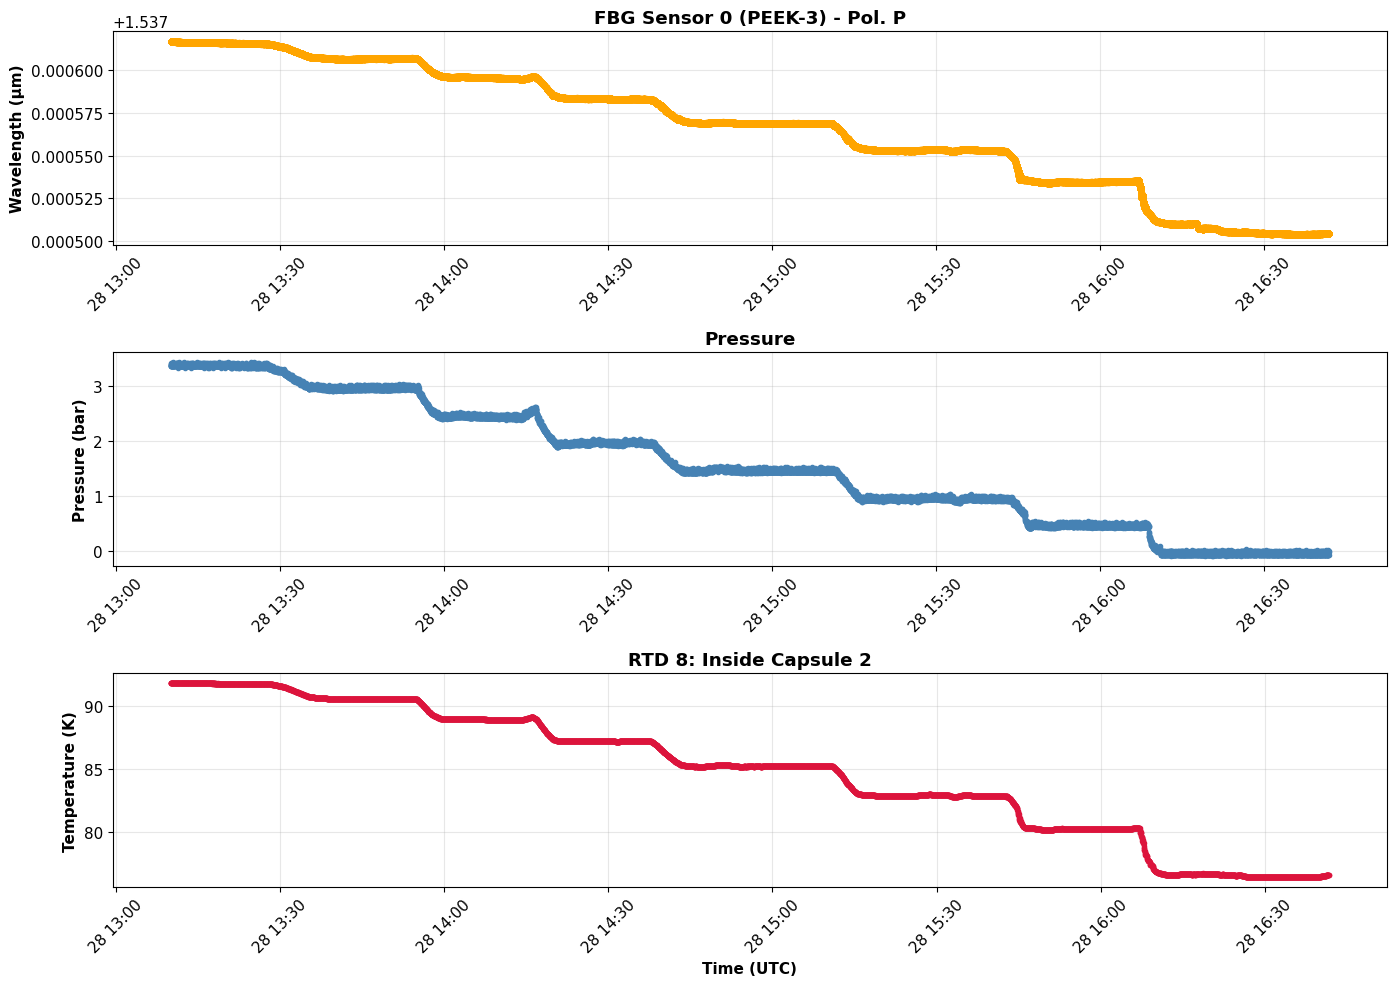


2️  Wavelength detallada - Sensor 0 (FBGS-2), ambas polarizaciones:


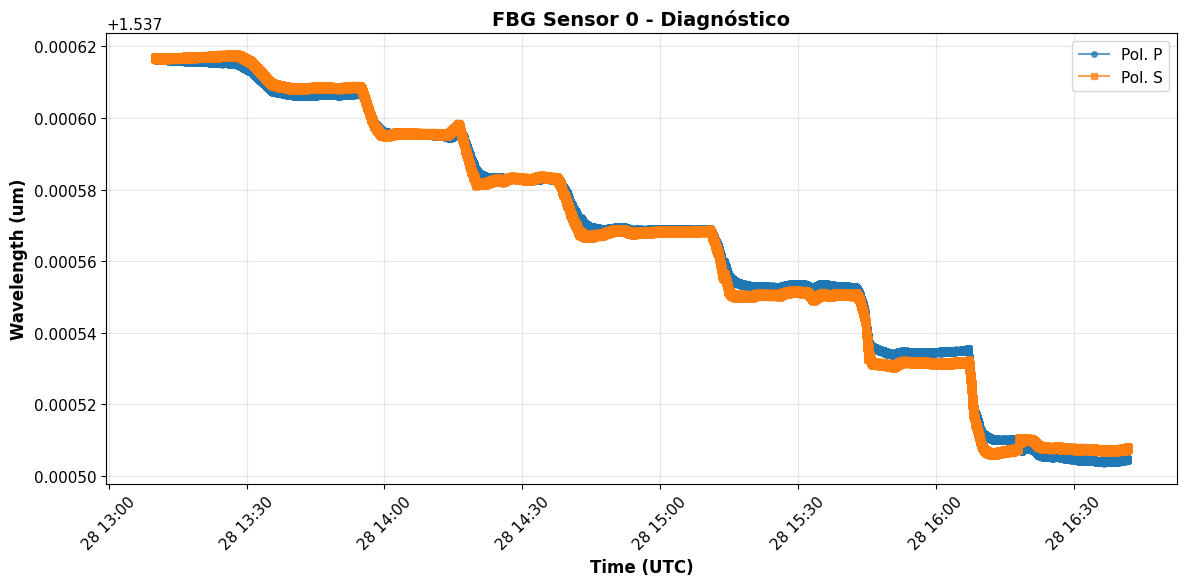


3️  Presión detallada:


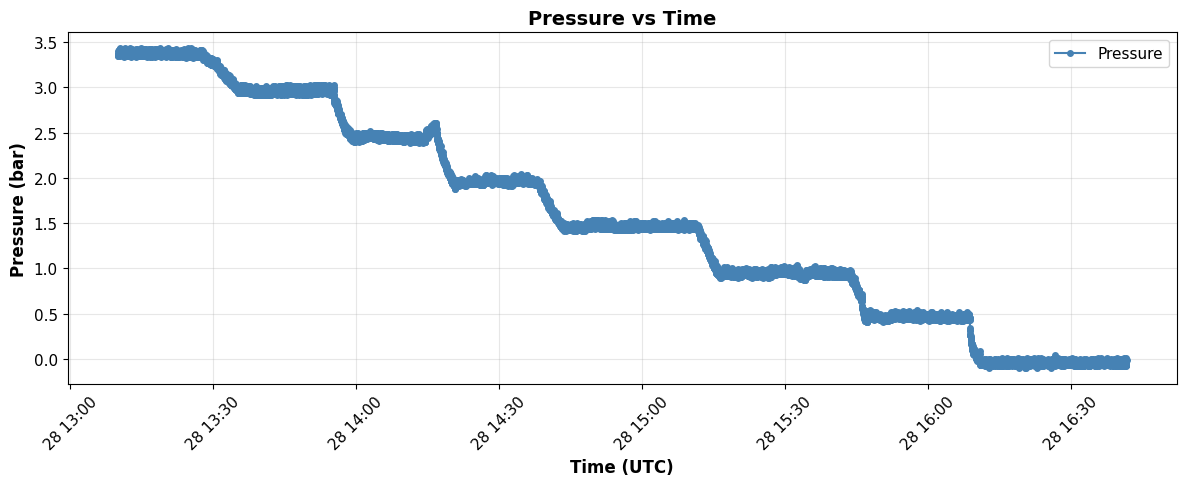


4️  Temperatura RTD 7 (Inside Capsule 2):


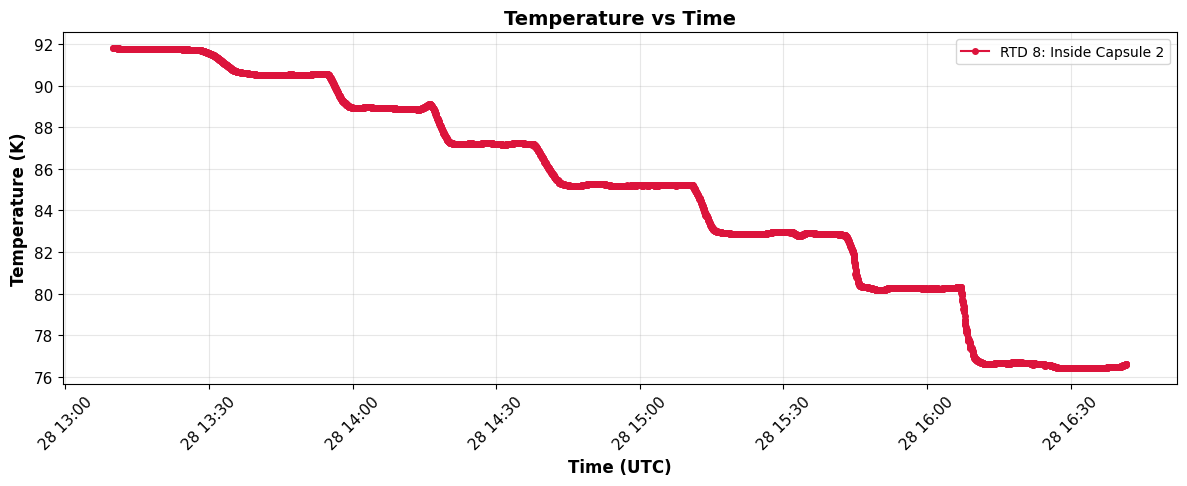


 Gráficos de diagnóstico completados

 INTERPRETA LOS GRÁFICOS:
  • ¿Ves regiones estables (plateaus) en los datos?
  • ¿Las 3 señales (wavelength, presión, temperatura) tienen plateaus simultáneos?
  • Si NO ves plateaus claros:
    - Ajusta ANALYSIS_START_TIME para otra ventana temporal
    - Relaja las tolerancias en PLATEAU_PARAMS
    - Considera añadir plateaus manualmente


In [7]:
# ============================================================================
# VISUALIZACIÓN DE DIAGNÓSTICO - Ver datos completos
# ============================================================================
# Esta celda muestra gráficos de los datos para diagnosticar problemas

print(" Generando gráficos de diagnóstico...")
print("="*70)
print(f"Ventana de análisis configurada:")
print(f"  • Inicio: {ANALYSIS_START_TIME}")
print(f"  • Fin:    {ANALYSIS_END_TIME or 'Hasta el final de los datos'}")
print("="*70)

# Diagnóstico de tiempos reales en los datos
print("\n📊 DIAGNÓSTICO DE TIEMPOS EN DATOS:")
print("="*70)
peak_times_all = loader.get_peak_times()
press_times_all = loader.get_press_times()
temp_times_all = loader.get_temp_times()

print(f"Wavelength (WAV):")
print(f"  • Primer dato: {peak_times_all[0] if len(peak_times_all) > 0 else 'N/A'}")
print(f"  • Último dato: {peak_times_all[-1] if len(peak_times_all) > 0 else 'N/A'}")
print(f"  • Total puntos: {len(peak_times_all)}")

print(f"\nPresión (PRESS):")
print(f"  • Primer dato: {press_times_all[0] if len(press_times_all) > 0 else 'N/A'}")
print(f"  • Último dato: {press_times_all[-1] if len(press_times_all) > 0 else 'N/A'}")
print(f"  • Total puntos: {len(press_times_all)}")

print(f"\nTemperatura (TEMP):")
print(f"  • Primer dato: {temp_times_all[0] if len(temp_times_all) > 0 else 'N/A'}")
print(f"  • Último dato: {temp_times_all[-1] if len(temp_times_all) > 0 else 'N/A'}")
print(f"  • Total puntos: {len(temp_times_all)}")
print("="*70)

# 1. Vista general de todos los datos
print("\n1️  Vista general de los 3 tipos de datos:")
viz.plot_data_overview(start_time=ANALYSIS_START_TIME)

# 2. Wavelength detallada para sensor 0
print("\n2️  Wavelength detallada - Sensor 0 (FBGS-2), ambas polarizaciones:")
viz.plot_wavelength(
    sensor_idx=0,
    show_both_pols=True,
    start_time=ANALYSIS_START_TIME,
    end_time=ANALYSIS_END_TIME,
    title="FBG Sensor 0 - Diagnóstico"
)

# 3. Presión detallada
print("\n3️  Presión detallada:")
viz.plot_pressure(
    start_time=ANALYSIS_START_TIME,
    end_time=ANALYSIS_END_TIME
)

# 4. Temperatura detallada (RTD 7 - dentro cápsula)
print("\n4️  Temperatura RTD 7 (Inside Capsule 2):")
viz.plot_temperature(
    sensor_idx=7,
    start_time=ANALYSIS_START_TIME,
    end_time=ANALYSIS_END_TIME
)

print("\n" + "="*70)
print(" Gráficos de diagnóstico completados")
print("\n INTERPRETA LOS GRÁFICOS:")
print("  • ¿Ves regiones estables (plateaus) en los datos?")
print("  • ¿Las 3 señales (wavelength, presión, temperatura) tienen plateaus simultáneos?")
print("  • Si NO ves plateaus claros:")
print("    - Ajusta ANALYSIS_START_TIME para otra ventana temporal")
print("    - Relaja las tolerancias en PLATEAU_PARAMS")
print("    - Considera añadir plateaus manualmente")
print("="*70)

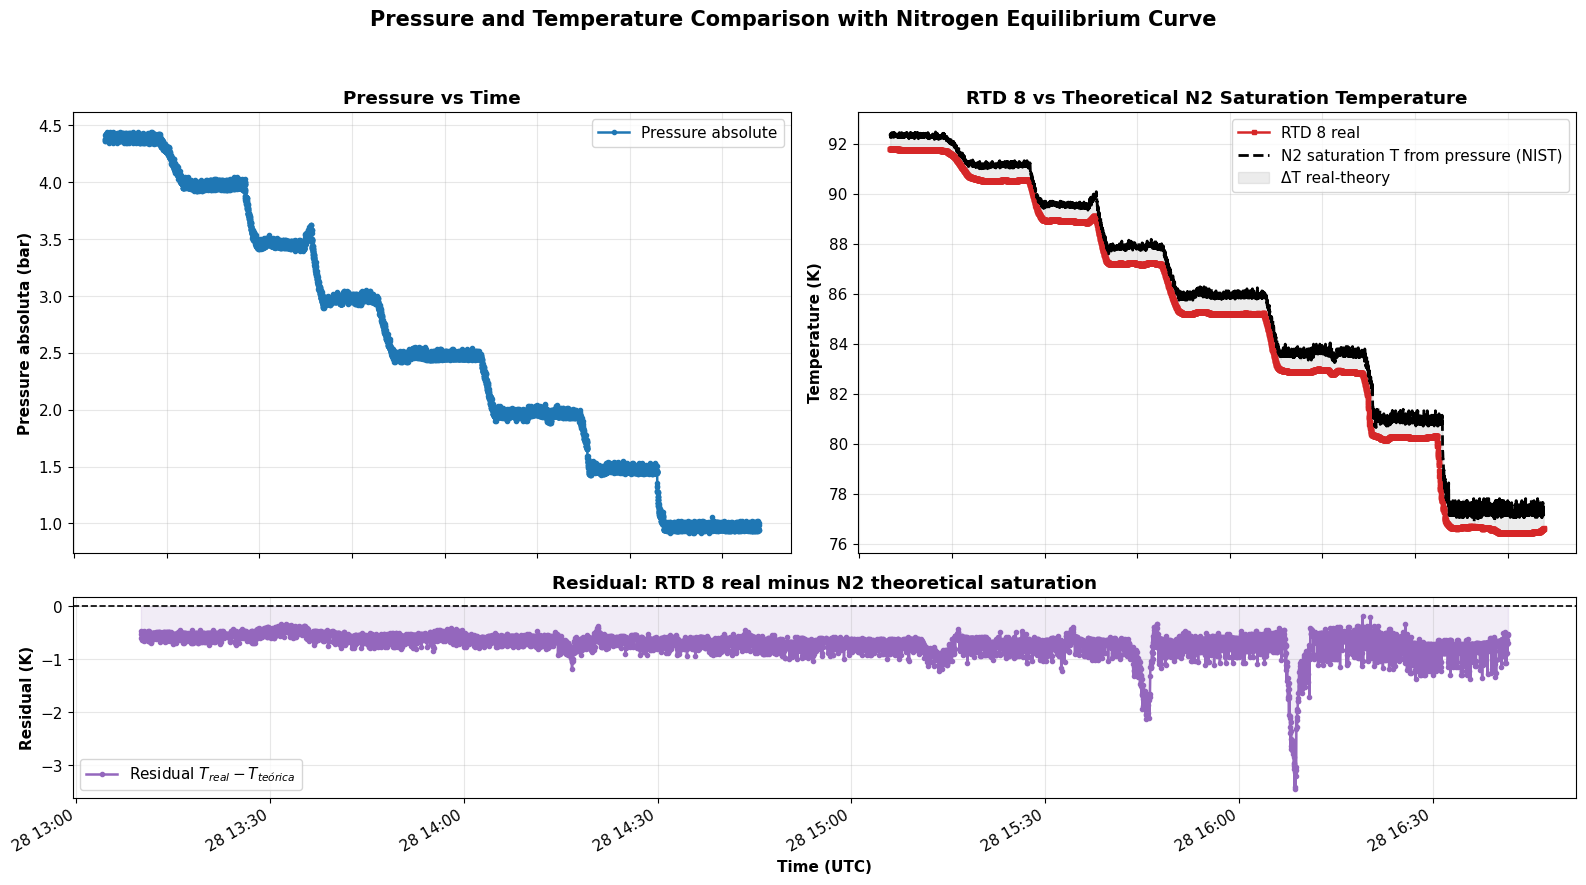

Resumen comparación RTD 8 vs N2 teórico
  • Temperatura real media:       84.845 K
  • Temperatura teórica media:    85.542 K
  • Diferencia media real-teoría:  -0.697 K
  • Desviación std de ΔT:          0.244 K
  • Presión absoluta media usada:  2.573 bar
  • Referencia: NIST WebBook SRD 69, Nitrogen, Antoine equation (Edejer & Thodos, 1967)


In [8]:
# ============================================================================
# NUEVA COMPARACIÓN: Presión y Temperatura de RTD 8 vs curva teórica de N2
# ============================================================================
# Fuente bibliográfica de la curva líquido-gas de N2:
# - NIST Chemistry WebBook (SRD 69), Nitrogen (CAS 7727-37-9)
# - Antoine equation parameters cited by NIST:
#   log10(P/bar) = A - B / (T + C)
#   con A = 3.7362, B = 264.651, C = -6.788
# - Reference listed by NIST: Edejer and Thodos, J. Chem. Eng. Data 1967, 12, 206-209.
#
# Importante:
# - La presión medida en el experimento es manométrica (relativa a la atmósfera).
# - La correlación de Antoine necesita presión absoluta, así que sumamos 1.01325 bar.
# - En esta celda el panel izquierdo muestra la presión absoluta para que la comparación
#   con la temperatura teórica sea más visual e intuitiva.
# - Rango de validez aproximado de la correlación usada aquí: 63.14 K a 126 K.
#
# Con esa relación convertimos la presión medida en la temperatura de saturación
# del nitrógeno líquido en coexistencia líquido-gas.
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import uproot

ATM_PRESSURE_BAR = 1.01325

input_filename = globals().get(
    'INPUT_FILENAME',
    '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260428.root',
)
start_time = globals().get('ANALYSIS_START_TIME', None)
end_time = globals().get('ANALYSIS_END_TIME', None)
loader_obj = globals().get('loader', None)

root_path = Path(input_filename)

if not root_path.exists():
    print(f'ROOT no disponible todavía: {root_path}')
    print('La celda queda preparada y se ejecutará cuando exista el archivo.')
else:
    if loader_obj is not None:
        idx_rtd = loader_obj.temp_data['temp'].shape[1] - 1
        press_times = loader_obj.get_press_times()
        press_values = loader_obj.get_pressure()
        temp_times = loader_obj.get_temp_times()
        temp_values = loader_obj.get_temperature(sensor_idx=idx_rtd)
    else:
        with uproot.open(input_filename) as root_file:
            press_data = root_file['press'].arrays(library='np')
            temp_data = root_file['temp'].arrays(library='np')

        idx_rtd = temp_data['temp'].shape[1] - 1
        press_times = np.array([datetime.datetime.utcfromtimestamp(t) for t in press_data['t']])
        press_values = press_data['press']
        temp_times = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_data['t']])
        temp_values = temp_data['temp'][:, idx_rtd]

    press_times = np.asarray(press_times).reshape(-1)
    press_values = np.asarray(press_values).reshape(-1)
    temp_times = np.asarray(temp_times).reshape(-1)
    temp_values = np.asarray(temp_values).reshape(-1)

    press_len = min(len(press_times), len(press_values))
    temp_len = min(len(temp_times), len(temp_values))
    press_times = press_times[:press_len]
    press_values = press_values[:press_len]
    temp_times = temp_times[:temp_len]
    temp_values = temp_values[:temp_len]

    mask_press = np.ones(len(press_times), dtype=bool)
    mask_temp = np.ones(len(temp_times), dtype=bool)

    if start_time is not None:
        mask_press &= press_times >= start_time
        mask_temp &= temp_times >= start_time
    if end_time is not None:
        mask_press &= press_times <= end_time
        mask_temp &= temp_times <= end_time

    press_times_plot = press_times[mask_press]
    press_values_plot_gauge = press_values[mask_press]
    press_values_plot_abs = press_values_plot_gauge + ATM_PRESSURE_BAR
    temp_times_plot = temp_times[mask_temp]
    temp_values_plot = temp_values[mask_temp]

    if len(press_times_plot) < 2 or len(press_values_plot_gauge) < 2 or len(temp_times_plot) == 0:
        print('No hay suficientes datos alineados para interpolar presión sobre temperatura.')
    else:
        pressure_interp = interp1d(
            np.array([t.timestamp() for t in press_times_plot]),
            press_values_plot_gauge,
            kind='linear',
            bounds_error=False,
            fill_value='extrapolate',
        )
        press_on_temp_gauge = pressure_interp(np.array([t.timestamp() for t in temp_times_plot]))
        press_on_temp_abs = press_on_temp_gauge + ATM_PRESSURE_BAR

        def nitrogen_saturation_temperature_k(pressure_bar_relative):
            pressure_abs = np.asarray(pressure_bar_relative, dtype=float) + ATM_PRESSURE_BAR
            saturation_temp = np.full_like(pressure_abs, np.nan, dtype=float)
            valid = pressure_abs > 0
            saturation_temp[valid] = 264.651 / (3.7362 - np.log10(pressure_abs[valid])) + 6.788
            return saturation_temp

        temp_theory = nitrogen_saturation_temperature_k(press_on_temp_gauge)

        valid_len = min(len(temp_values_plot), len(temp_theory), len(temp_times_plot))
        temp_times_plot = temp_times_plot[:valid_len]
        temp_values_plot = temp_values_plot[:valid_len]
        temp_theory = temp_theory[:valid_len]
        press_on_temp_abs = press_on_temp_abs[:valid_len]
        press_on_temp_gauge = press_on_temp_gauge[:valid_len]

        fig = plt.figure(figsize=(16, 9))
        gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1.0])
        ax_press = fig.add_subplot(gs[0, 0])
        ax_temp = fig.add_subplot(gs[0, 1])
        ax_res = fig.add_subplot(gs[1, :], sharex=ax_temp)

        ax_press.plot(
            press_times_plot,
            press_values_plot_abs,
            color='tab:blue',
            marker='o',
            linewidth=1.8,
            markersize=3,
            label='Pressure absolute',
        )
        ax_press.set_ylabel('Pressure absoluta (bar)', fontweight='bold')
        ax_press.set_xlabel('Time (UTC)', fontweight='bold')
        ax_press.set_title('Pressure vs Time', fontweight='bold')
        ax_press.grid(alpha=0.3)
        ax_press.legend()

        ax_temp.plot(
            temp_times_plot,
            temp_values_plot,
            color='tab:red',
            marker='s',
            linewidth=1.8,
            markersize=3,
            label=f'RTD {idx_rtd + 1} real',
        )
        ax_temp.plot(
            temp_times_plot,
            temp_theory,
            color='black',
            linestyle='--',
            linewidth=2.0,
            label='N2 saturation T from pressure (NIST)',
        )
        ax_temp.fill_between(
            temp_times_plot,
            temp_values_plot,
            temp_theory,
            color='gray',
            alpha=0.15,
            label='ΔT real-theory',
        )
        ax_temp.set_ylabel('Temperature (K)', fontweight='bold')
        ax_temp.set_xlabel('Time (UTC)', fontweight='bold')
        ax_temp.set_title(f'RTD {idx_rtd + 1} vs Theoretical N2 Saturation Temperature', fontweight='bold')
        ax_temp.grid(alpha=0.3)
        ax_temp.legend()

        delta_t = np.asarray(temp_values_plot) - temp_theory
        ax_res.axhline(0.0, color='black', linewidth=1.2, linestyle='--')
        ax_res.plot(
            temp_times_plot,
            delta_t,
            color='tab:purple',
            marker='o',
            linewidth=1.8,
            markersize=3,
            label='Residual $T_{real} - T_{teórica}$',
        )
        ax_res.fill_between(
            temp_times_plot,
            0.0,
            delta_t,
            color='tab:purple',
            alpha=0.12,
        )
        ax_res.set_ylabel('Residual (K)', fontweight='bold')
        ax_res.set_xlabel('Time (UTC)', fontweight='bold')
        ax_res.set_title('Residual: RTD 8 real minus N2 theoretical saturation', fontweight='bold')
        ax_res.grid(alpha=0.3)
        ax_res.legend()

        fig.suptitle(
            'Pressure and Temperature Comparison with Nitrogen Equilibrium Curve',
            fontsize=15,
            fontweight='bold',
        )
        fig.autofmt_xdate()
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        if len(temp_values_plot) > 0 and len(temp_theory) > 0:
            print('Resumen comparación RTD 8 vs N2 teórico')
            print(f'  • Temperatura real media:       {np.nanmean(temp_values_plot):.3f} K')
            print(f'  • Temperatura teórica media:    {np.nanmean(temp_theory):.3f} K')
            print(f'  • Diferencia media real-teoría:  {np.nanmean(delta_t):.3f} K')
            print(f'  • Desviación std de ΔT:          {np.nanstd(delta_t):.3f} K')
            print(f'  • Presión absoluta media usada:  {np.nanmean(press_on_temp_abs):.3f} bar')
            if np.nanmean(delta_t) > 2.0:
                print('  • AVISO: el residual medio supera 2 K; posible fase gas / sobrecalentamiento.')
            print('  • Referencia: NIST WebBook SRD 69, Nitrogen, Antoine equation (Edejer & Thodos, 1967)')

**Nota:** esta celda queda preparada para ejecutarse cuando exista el archivo ROOT de entrada. Mientras tanto, la comparación P-T y el residual se muestran como referencia de la lógica del análisis.

---

##  **DETECCIÓN AUTOMÁTICA DE PLATEAUS**

**¿Qué hace esta celda?**

Detecta automáticamente las regiones estables (plateaus) en:
-  Presión
-  Temperatura  
-  Wavelength

Y encuentra los **plateaus comunes** = intervalos de tiempo donde las 3 señales son simultáneamente estables.

**Configuración importante:**

1. **ANALYSIS_START_TIME**: Solo se detectan plateaus DESPUÉS de este tiempo
   -  Configúralo en la celda de "GLOBAL CONSTANTS" para excluir periodos de calentamiento/estabilización

2. **PLATEAU_PARAMS**: Controla la sensibilidad de detección
   - `tolerance`: Máxima variación permitida dentro de un plateau
   - `min_plateau_length`: Duración mínima en segundos
   -  Si detecta muy pocos plateaus: aumenta tolerance o reduce min_plateau_length
   -  Si detecta demasiados: reduce tolerance o aumenta min_plateau_length

**¿Qué esperar?**

-  Se mostrarán gráficos con los plateaus detectados marcados
-  Se imprimirá un resumen con los horarios de los plateaus comunes
-  Si no detecta plateaus comunes, revisa:
  - ANALYSIS_START_TIME (¿empieza demasiado tarde?)
  - PLATEAU_PARAMS (¿tolerancias demasiado estrictas?)
  - Los gráficos de diagnóstico de la celda anterior

 Iniciando detección de plateaus...
  Configuración: START_TIME = 2026-04-28 13:10:00


Detecting plateaus for:
  • Temperature sensor: RTD 8
  • Wavelength: Pol 0, Sensor 0
  • Time window: 2026-04-28 13:10:00 to 2026-04-28 17:00:00

✓ Plateaus detected:
  • Pressure: 8
  • Temperature: 8
  • Wavelength: 8
  • Common (overlapping): 8


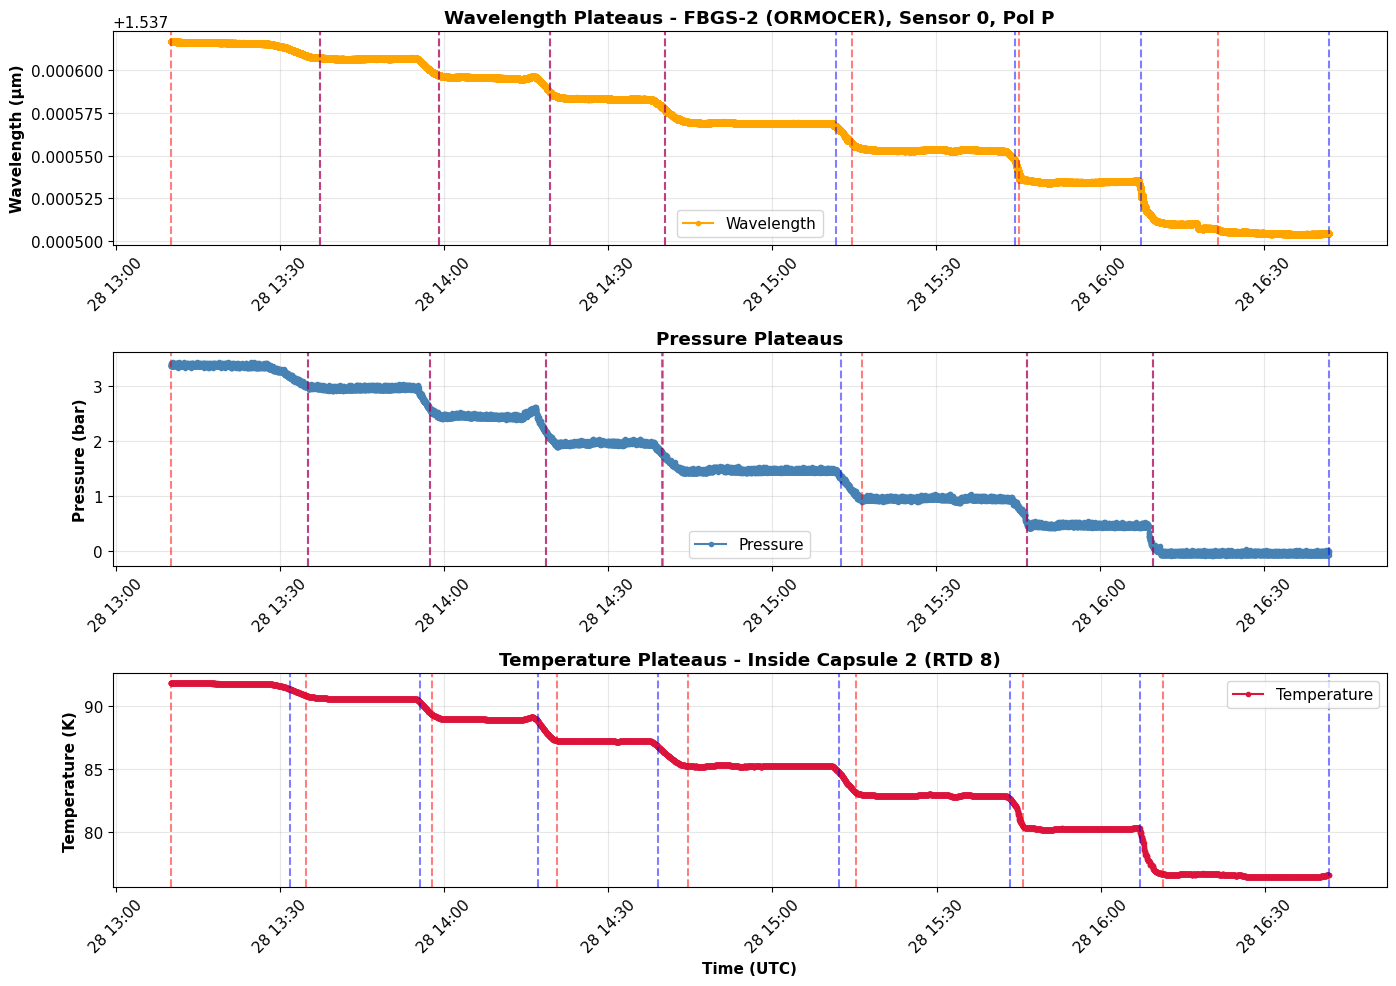


 Detección completada!
 Plateaus comunes detectados: 8

 TODOS LOS PLATEAUS DETECTADOS (en tiempo UTC):
----------------------------------------------------------------------
  #1 ✅: 2026-04-28 15:07:50 → 15:29:45 (21.9 min)
  #2 ✅: 2026-04-28 15:35:07 → 15:53:23 (18.3 min)
  #3 ✅: 2026-04-28 15:56:51 → 16:14:55 (18.1 min)
  #4 ✅: 2026-04-28 16:18:31 → 16:36:57 (18.4 min)
  #5 ✅: 2026-04-28 16:42:25 → 17:09:30 (27.1 min)
  #6 ✅: 2026-04-28 17:14:16 → 17:41:17 (27.0 min)
  #7 ✅: 2026-04-28 17:44:25 → 18:05:01 (20.6 min)
  #8 ✅: 2026-04-28 18:19:23 → 18:39:29 (20.1 min)
----------------------------------------------------------------------
NOTA: ANALYSIS_START_TIME = 2026-04-28 13:10:00
      Tiempos mostrados incluyen TIME_SHIFT (+2h para wavelength)

 Usando TODOS los 8 plateaus detectados para el análisis
   (El filtrado temporal ya se aplicó durante la detección)


In [9]:
# ============================================================================
# CELDA 24:  DETECCIÓN AUTOMÁTICA DE PLATEAUS
# ============================================================================
# Esta celda DETECTA los plateaus automáticamente en los datos
# Usa los tiempos y parámetros globales configurados al inicio

print(" Iniciando detección de plateaus...")
print("="*70)
print(f"  Configuración: START_TIME = {ANALYSIS_START_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Detectar plateaus para RTD 7 (dentro de la cápsula) y sensor 0, polarización P
detector.detect_all_plateaus(
    sensor_temp=7,        # RTD 7: Inside Capsule 2
    sensor_wav=(0, 0),    # Polarización P (0), Sensor 0 (FBGS-2)
    # params y start_time/end_time usan valores globales automáticamente
    plot=True             # Muestra gráficos con plateaus detectados
)

print("\n" + "="*70)
print(" Detección completada!")
print(f" Plateaus comunes detectados: {len(detector.plateaus['common'])}")

# DIAGNÓSTICO: Imprimir TODOS los plateaus con sus tiempos UTC
print("\n TODOS LOS PLATEAUS DETECTADOS (en tiempo UTC):")
print("-"*70)
for i, plat in enumerate(detector.plateaus['common'], 1):
    # IMPORTANTE: Los timestamps RAW están SIN shift, debemos aplicar +2h para mostrar correctamente
    t0_utc = datetime.datetime.utcfromtimestamp(plat['t0']) + TIME_SHIFT
    tfin_utc = datetime.datetime.utcfromtimestamp(plat['tfin']) + TIME_SHIFT
    dur = (tfin_utc - t0_utc).total_seconds() / 60
    
    # Comparar con ANALYSIS_START_TIME
    esta_despues = t0_utc >= ANALYSIS_START_TIME
    marca = "✅" if esta_despues else "❌"
    
    print(f"  #{i} {marca}: {t0_utc.strftime('%Y-%m-%d %H:%M:%S')} → {tfin_utc.strftime('%H:%M:%S')} ({dur:.1f} min)")

print("-"*70)
print(f"NOTA: ANALYSIS_START_TIME = {ANALYSIS_START_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"      Tiempos mostrados incluyen TIME_SHIFT (+2h para wavelength)")
print("="*70)

# NO FILTRAR NADA - usar todos los plateaus detectados
print(f"\n Usando TODOS los {len(detector.plateaus['common'])} plateaus detectados para el análisis")
print("   (El filtrado temporal ya se aplicó durante la detección)")
print("="*70)

---

##  **REVISIÓN Y MODIFICACIÓN DE PLATEAUS**

Las siguientes celdas te permiten:
1.  **Ver** los plateaus detectados automáticamente
2.  **Modificar** los tiempos si quieres ajustarlos
3.  **Eliminar** plateaus que no quieras usar
4.  **Añadir** nuevos plateaus manualmente

---

In [10]:
# ============================================================================
# CELDA 26:  VERIFICAR PLATEAUS DETECTADOS
# ============================================================================
# Esta celda muestra los plateaus detectados automáticamente en la celda 24
# WORKFLOW: Ejecuta primero Celda 15 (config) → Celda 24 (detectar) → Celda 26 (verificar)

import datetime

print("="*80)
print(" PLATEAUS FINALES PARA ANÁLISIS DE SENSIBILIDAD")
print("="*80)

if not detector.plateaus or len(detector.plateaus.get('common', [])) == 0:
    print("\n No hay plateaus detectados. Ejecuta la celda de detección primero.")
else:
    common_plateaus = detector.plateaus['common']
    
    print(f"\n {len(common_plateaus)} plateaus comunes detectados")
    print(f" Configuración aplicada: ANALYSIS_START_TIME = {ANALYSIS_START_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # VALIDACIÓN: Verificar coherencia temporal
    print("\n VALIDACIÓN DE RANGOS TEMPORALES:")
    print("-"*80)
    
    # Obtener rangos temporales de los datos (todos ya alineados)
    peak_times = loader.get_peak_times()  # Ya tiene TIME_SHIFT aplicado
    press_times = loader.get_press_times()
    temp_times = loader.get_temp_times()
    
    print(f"Wavelength:  {peak_times[0].strftime('%H:%M:%S')} → {peak_times[-1].strftime('%H:%M:%S')}")
    print(f"Pressure:    {press_times[0].strftime('%H:%M:%S')} → {press_times[-1].strftime('%H:%M:%S')}")
    print(f"Temperature: {temp_times[0].strftime('%H:%M:%S')} → {temp_times[-1].strftime('%H:%M:%S')}")
    
    # Verificar que los plateaus detectados respetan ANALYSIS_START_TIME
    first_plateau_t0 = common_plateaus[0]['t0'] if isinstance(common_plateaus[0]['t0'], datetime.datetime) else datetime.datetime.fromtimestamp(float(common_plateaus[0]['t0']))
    
    if first_plateau_t0 < ANALYSIS_START_TIME:
        print(f"\n  ADVERTENCIA: Hay plateaus detectados ANTES de ANALYSIS_START_TIME!")
        print(f"   Primer plateau: {first_plateau_t0.strftime('%H:%M:%S')}")
        print(f"   START_TIME configurado: {ANALYSIS_START_TIME.strftime('%H:%M:%S')}")
        print(f"\n    SOLUCIÓN: Re-ejecuta la celda de DETECCIÓN para aplicar la nueva configuración")
    else:
        print(f"\n Todos los plateaus comienzan después de {ANALYSIS_START_TIME.strftime('%H:%M:%S')}")
    
    # Tabla de plateaus (tiempos ya están alineados con TIME_SHIFT aplicado)
    print("\n" + "-"*80)
    print(f"{'#':<4} {'Inicio':<20} {'Fin':<20} {'Duración (min)':<15}")
    print("-"*80)
    
    total_duration = 0
    for i, plat in enumerate(common_plateaus, 1):
        t0 = plat['t0'] if isinstance(plat['t0'], datetime.datetime) else datetime.datetime.fromtimestamp(float(plat['t0']))
        tfin = plat['tfin'] if isinstance(plat['tfin'], datetime.datetime) else datetime.datetime.fromtimestamp(float(plat['tfin']))
        
        duration = (tfin - t0).total_seconds() / 60
        total_duration += duration
        print(f"{i:<4} {t0.strftime('%Y-%m-%d %H:%M:%S'):<20} "
              f"{tfin.strftime('%Y-%m-%d %H:%M:%S'):<20} {duration:>14.1f}")
    
    print("-"*80)
    print(f"{'TOTAL':<44} {total_duration:>14.1f}")
    print("-"*80)
    
    print("\n" + "="*80)
    print(" Estos plateaus se usarán para calcular la sensibilidad de TODOS los sensores")
    print("="*80)
    
    # ========================================================================
    # GENERAR CÓDIGO PYTHON PARA MODIFICACIÓN MANUAL
    # ========================================================================
    print("\n" + "="*80)
    print(" CÓDIGO PYTHON PARA MODIFICACIÓN MANUAL DE PLATEAUS")
    print("="*80)
    print("\n# Copia este código en una nueva celda si quieres modificar los plateaus manualmente:")
    print("\n" + "-"*80)
    print("import datetime")
    print()
    print("# Diccionario de plateaus detectados (tiempos ya alineados)")
    print("# Puedes modificar las horas/minutos o añadir/eliminar entradas")
    print("manual_plateaus = [")
    
    for i, plat in enumerate(common_plateaus, 1):
        t0 = plat['t0'] if isinstance(plat['t0'], datetime.datetime) else datetime.datetime.fromtimestamp(float(plat['t0']))
        tfin = plat['tfin'] if isinstance(plat['tfin'], datetime.datetime) else datetime.datetime.fromtimestamp(float(plat['tfin']))
        
        print(f"    {{  # Plateau {i}")
        print(f"        't0': datetime.datetime.strptime('{t0.strftime('%Y-%m-%d %H:%M:%S')}', '%Y-%m-%d %H:%M:%S'),")
        print(f"        'tfin': datetime.datetime.strptime('{tfin.strftime('%Y-%m-%d %H:%M:%S')}', '%Y-%m-%d %H:%M:%S')")
        print(f"    }},")
    
    print("]")
    print()
    print("# Para aplicar estos plateaus modificados:")
    print("# detector.plateaus['common'] = [")
    print("#     {'t0': p['t0'].timestamp(), 'tfin': p['tfin'].timestamp()}")
    print("#     for p in manual_plateaus")
    print("# ]")
    print("-"*80)
    print("\n NOTA: Los tiempos ya están alineados (TIME_SHIFT aplicado una sola vez al inicio)")
    print("   Al aplicar los cambios, se restará automáticamente el shift para guardar correctamente")
    print("="*80)

 PLATEAUS FINALES PARA ANÁLISIS DE SENSIBILIDAD

 8 plateaus comunes detectados
 Configuración aplicada: ANALYSIS_START_TIME = 2026-04-28 13:10:00

 VALIDACIÓN DE RANGOS TEMPORALES:
--------------------------------------------------------------------------------


Wavelength:  11:49:44 → 16:41:51
Pressure:    11:14:09 → 16:41:45
Temperature: 11:13:50 → 16:41:39

 Todos los plateaus comienzan después de 13:10:00

--------------------------------------------------------------------------------
#    Inicio               Fin                  Duración (min) 
--------------------------------------------------------------------------------
1    2026-04-28 13:10:00  2026-04-28 13:31:55            21.9
2    2026-04-28 13:37:17  2026-04-28 13:55:33            18.3
3    2026-04-28 13:59:01  2026-04-28 14:17:05            18.1
4    2026-04-28 14:20:41  2026-04-28 14:39:07            18.4
5    2026-04-28 14:44:35  2026-04-28 15:11:40            27.1
6    2026-04-28 15:16:26  2026-04-28 15:43:27            27.0
7    2026-04-28 15:46:35  2026-04-28 16:07:11            20.6
8    2026-04-28 16:21:33  2026-04-28 16:41:39            20.1
--------------------------------------------------------------------------------
TOTAL                                          

In [11]:
# ============================================================================
# CELDA 27:  MODIFICAR PLATEAUS MANUALMENTE (OPCIONAL)
# ============================================================================
# Esta celda permite modificar los plateaus detectados automáticamente
# 
# WORKFLOW: Celda 24 (detectar) → Celda 26 (verificar) → Celda 27 (modificar opcional)
#
# INSTRUCCIONES:
# 1. Ejecuta primero la celda 24 (detección automática) y celda 26 (verificación)
# 2. Mira los plateaus detectados automáticamente
# 3. Si quieres añadir/quitar/modificar, edita las listas siguientes
# 4. Ejecuta esta celda
# ============================================================================

import datetime

print("="*80)
print(" MODIFICACIÓN MANUAL DE PLATEAUS")
print("="*80)

# ============================================================================
# PASO 1: MOSTRAR PLATEAUS DETECTADOS AUTOMÁTICAMENTE
# ============================================================================
print(f"\n Plateaus detectados automáticamente: {len(detector.plateaus.get('common', []))}")
print("\n LISTA DE PLATEAUS DETECTADOS:")
print("-"*80)
print(f"{'#':<4} {'Inicio':<12} {'Fin':<12} {'Duración':<12}")
print("-"*80)

auto_plateaus = []
for i, plat in enumerate(detector.plateaus.get('common', []), 1):
    t0 = datetime.datetime.fromtimestamp(plat['t0'])
    tfin = datetime.datetime.fromtimestamp(plat['tfin'])
    duration_min = (tfin - t0).total_seconds() / 60
    auto_plateaus.append((t0.strftime('%H:%M:%S'), tfin.strftime('%H:%M:%S')))
    print(f"{i:<4} {t0.strftime('%H:%M:%S'):<12} {tfin.strftime('%H:%M:%S'):<12} {duration_min:>10.1f} min")

print("-"*80)

# ============================================================================
# PASO 2:  CONFIGURACIÓN DE MODIFICACIONES
# ============================================================================
# Indica qué quieres hacer:
#
# OPCIÓN A: Usar los plateaus automáticos sin cambios
#   → Deja las listas vacías: plateaus_to_remove = [] y plateaus_to_add = []
#
# OPCIÓN B: Eliminar algunos plateaus automáticos
#   → Añade los índices a eliminar (empezando desde 1)
#   → Ejemplo: plateaus_to_remove = [1, 3]  # Elimina el 1º y 3º plateau
#
# OPCIÓN C: Añadir nuevos plateaus
#   → Añade tuplas (inicio, fin, descripción) a la lista
#   → Ejemplo: ("14:00:00", "14:15:00", "Plateau añadido manualmente")
# ============================================================================

# Índices de plateaus automáticos a ELIMINAR (empezando desde 1)
plateaus_to_remove = [1, 2, 3, 4, 5, 6, 7, 8]  # Ejemplo: [1, 3] eliminaría el 1º y 3º. BORRO TODOS PARA AÑADIRLOS MANUAL
# Plateaus ADICIONALES a añadir (formato: hora_inicio, hora_fin, descripción)
# Todos ajustados a exactamente 11 minutos extrayendo el centro de tu ventana original
# Plateaus ADICIONALES a añadir (formato: hora_inicio, hora_fin, descripción)
# Ajustados a 11 minutos exactos (alineados al final de la ventana original)
plateaus_to_add = [
    ("13:17:00", "13:28:00", "Plateau alineado al final (11 min)"), # Original: 13:11 a 13:29
    ("13:42:00", "13:53:00", "Plateau alineado al final (11 min)"), # Original: 13:40 a 13:52
    ("14:03:00", "14:14:00", "Plateau original (11 min)"),          # Límite exacto de 11 min
    ("14:25:00", "14:36:00", "Plateau alineado al final (11 min)"), # Original: 14:23 a 14:35
    ("14:59:00", "15:10:00", "Plateau alineado al final (11 min)"), # Original: 14:46 a 15:10
    ("15:30:00", "15:41:00", "Plateau alineado al final (11 min)"), # Original: 15:20 a 15:39
    ("15:54:00", "16:05:00", "Plateau alineado al final (11 min)"), # Original: 15:50 a 16:05
    ("16:27:00", "16:38:00", "Plateau original (11 min)"),          # Límite exacto de 11 min

    # Añade aquí los plateaus que quieras adicionar:
]

# ============================================================================
# PASO 3: PROCESAMIENTO AUTOMÁTICO - No modificar
# ============================================================================
date_str = "2026-04-28"  # Fecha del experimento

# Partir de los plateaus automáticos
final_plateaus = []

# Añadir plateaus automáticos (excepto los que se quieren eliminar)
for i, plat in enumerate(detector.plateaus.get('common', []), 1):
    if i not in plateaus_to_remove:
        t0 = datetime.datetime.fromtimestamp(plat['t0'])
        tfin = datetime.datetime.fromtimestamp(plat['tfin'])
        final_plateaus.append({
            't0': plat['t0'],
            'tfin': plat['tfin'],
            'desc': f"Plateau {i} - detectado automáticamente"
        })

# Añadir plateaus adicionales
for t0_str, tfin_str, desc in plateaus_to_add:
    t0_dt = datetime.datetime.strptime(f"{date_str} {t0_str}", "%Y-%m-%d %H:%M:%S")
    tfin_dt = datetime.datetime.strptime(f"{date_str} {tfin_str}", "%Y-%m-%d %H:%M:%S")
    final_plateaus.append({
        't0': t0_dt.timestamp(),
        'tfin': tfin_dt.timestamp(),
        'desc': desc
    })

# Ordenar por tiempo de inicio
final_plateaus = sorted(final_plateaus, key=lambda x: x['t0'])

# Aplicar los cambios
detector.plateaus['common'] = [
    {'t0': p['t0'], 'tfin': p['tfin']}
    for p in final_plateaus
]

# ============================================================================
# PASO 4: VERIFICACIÓN Y DISPLAY FINAL
# ============================================================================
print("\n" + "="*80)
print(" RESULTADO FINAL")
print("="*80)

if plateaus_to_remove:
    print(f"\n  Plateaus eliminados: {len(plateaus_to_remove)} (índices: {plateaus_to_remove})")
if plateaus_to_add:
    print(f"\n Plateaus añadidos: {len(plateaus_to_add)}")

print(f"\n Total de plateaus finales: {len(final_plateaus)}")
print("\n LISTA COMPLETA DE PLATEAUS:")
print("-"*80)
print(f"{'#':<4} {'Inicio':<12} {'Fin':<12} {'Duración':<12} {'Descripción'}")
print("-"*80)

total_duration = 0
for i, plat in enumerate(final_plateaus, 1):
    t0 = datetime.datetime.fromtimestamp(plat['t0'])
    tfin = datetime.datetime.fromtimestamp(plat['tfin'])
    duration_min = (tfin - t0).total_seconds() / 60
    total_duration += duration_min
    
    print(f"{i:<4} {t0.strftime('%H:%M:%S'):<12} {tfin.strftime('%H:%M:%S'):<12} "
          f"{duration_min:>10.1f} min   {plat['desc']}")

print("-"*80)
print(f"{'TOTAL':<24} {total_duration:>10.1f} min")
print("-"*80)

# Verificación de coherencia temporal
print("\n🔍 VERIFICACIÓN:")
first_plateau_t0 = datetime.datetime.fromtimestamp(final_plateaus[0]['t0'])
if first_plateau_t0 < ANALYSIS_START_TIME:
    print(f"  ADVERTENCIA: Primer plateau ({first_plateau_t0.strftime('%H:%M:%S')}) "
          f"es ANTES de ANALYSIS_START_TIME ({ANALYSIS_START_TIME.strftime('%H:%M:%S')})")
    print(f"   Esto puede causar problemas en el análisis")
else:
    print(f" Todos los plateaus están después de ANALYSIS_START_TIME ({ANALYSIS_START_TIME.strftime('%H:%M:%S')})")

print("\n" + "="*80)
print(" PLATEAUS CONFIGURADOS - Listos para análisis de sensibilidad")
print("="*80)
print("\n PRÓXIMOS PASOS:")
print("   1. Verifica que los tiempos son correctos")
print("   2. Si necesitas hacer más cambios, modifica 'plateaus_to_remove' o 'plateaus_to_add' arriba")
print("   3. Ejecuta las celdas 29 y 31 para analizar la sensibilidad")
print("="*80)

 MODIFICACIÓN MANUAL DE PLATEAUS

 Plateaus detectados automáticamente: 8

 LISTA DE PLATEAUS DETECTADOS:
--------------------------------------------------------------------------------
#    Inicio       Fin          Duración    
--------------------------------------------------------------------------------
1    13:10:00     13:31:55           21.9 min
2    13:37:17     13:55:33           18.3 min
3    13:59:01     14:17:05           18.1 min
4    14:20:41     14:39:07           18.4 min
5    14:44:35     15:11:40           27.1 min
6    15:16:26     15:43:27           27.0 min
7    15:46:35     16:07:11           20.6 min
8    16:21:33     16:41:39           20.1 min
--------------------------------------------------------------------------------

 RESULTADO FINAL

  Plateaus eliminados: 8 (índices: [1, 2, 3, 4, 5, 6, 7, 8])

 Plateaus añadidos: 8

 Total de plateaus finales: 8

 LISTA COMPLETA DE PLATEAUS:
---------------------------------------------------------------------------

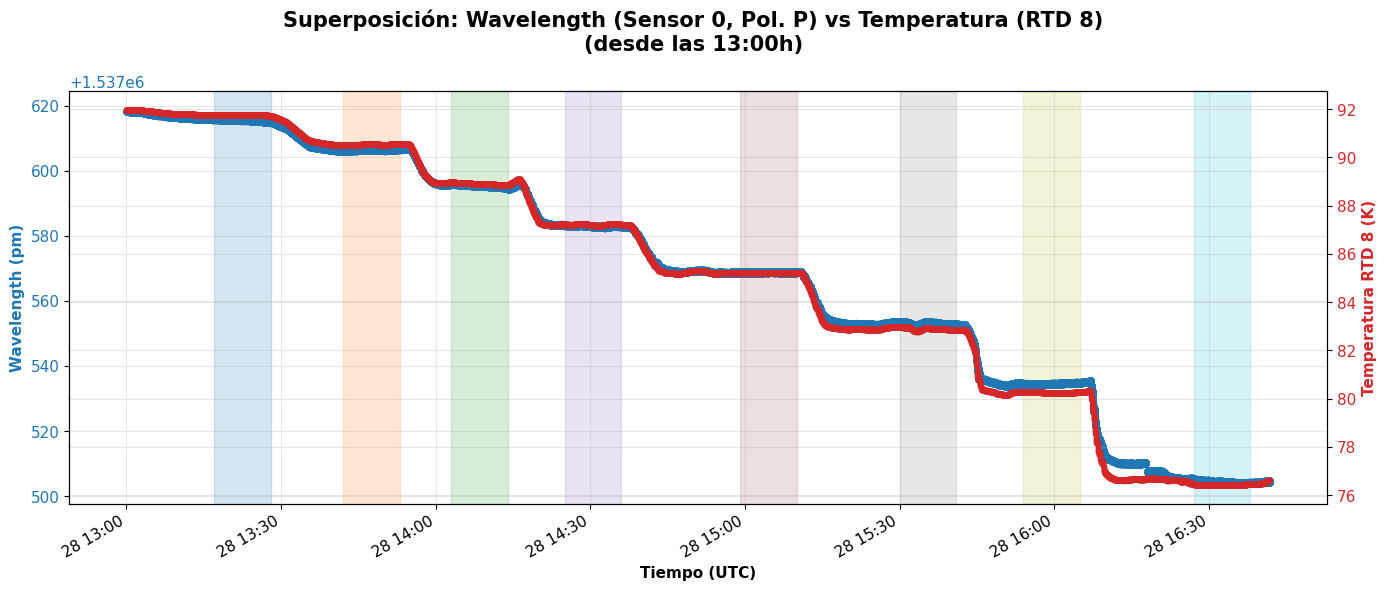

In [12]:
# ============================================================================
# SUPERPOSICIÓN: Temperatura (último RTD) vs Wavelength (sensor 0, pol. P) - Plateaus alineados y sombreados
# ============================================================================
import matplotlib.pyplot as plt
import datetime
import numpy as np

idx_rtd = loader.temp_data['temp'].shape[1] - 1
idx_sensor = 0
idx_pol = 0

hora_corte = datetime.time(13, 0, 0)

times_wav = loader.get_peak_times()
wav = loader.get_wavelength(pol_idx=idx_pol, sensor_idx=idx_sensor, unit='pm')
mask_wav = [t.time() >= hora_corte for t in times_wav]
times_wav_corte = times_wav[mask_wav]
wav_corte = wav[mask_wav]

times_temp = loader.get_temp_times()
temp = loader.get_temperature(sensor_idx=idx_rtd)
mask_temp = [t.time() >= hora_corte for t in times_temp]
times_temp_corte = times_temp[mask_temp]
temp_corte = temp[mask_temp]

plateaus = detector.plateaus['common'] if detector.plateaus and 'common' in detector.plateaus else []

fig, ax1 = plt.subplots(figsize=(14, 6))
color1 = 'tab:blue'
ax1.set_xlabel('Tiempo (UTC)')
ax1.set_ylabel('Wavelength (pm)', color=color1, fontweight='bold')
ax1.plot(times_wav_corte, wav_corte, color=color1, marker='o', markersize=3, label='Wavelength (Sensor 0, Pol. P)')
ax1.tick_params(axis='y', labelcolor=color1)

# Sombrear plateaus como en el ejemplo
colors = plt.cm.tab10(np.linspace(0, 1, len(plateaus)))
for i, (plat, color) in enumerate(zip(plateaus, colors), 1):
    t0 = datetime.datetime.fromtimestamp(plat['t0'])
    tfin = datetime.datetime.fromtimestamp(plat['tfin'])
    if t0.time() >= hora_corte:
        ax1.axvspan(t0, tfin, alpha=0.18, color=color, label=f'Plateau {i}' if i==1 else None)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel(f'Temperatura RTD {idx_rtd+1} (K)', color=color2, fontweight='bold')
ax2.plot(times_temp_corte, temp_corte, color=color2, marker='s', markersize=3, label=f'Temperatura RTD {idx_rtd+1}')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle(f'Superposición: Wavelength (Sensor 0, Pol. P) vs Temperatura (RTD {idx_rtd+1})\n(desde las 13:00h)', fontsize=15, fontweight='bold')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

---

##  **ANÁLISIS DE SENSIBILIDAD TÉRMICA**

### ¿Qué hace esta sección?

Calcula la sensibilidad térmica de cada sensor FBG (cambio en wavelength por unidad de temperatura):

$$\text{Sensibilidad} = \frac{\Delta\lambda}{\Delta T} \quad [\text{pm/K}]$$

### Configuración Previa Requerida

 **Plateaus detectados** (celda 22 ejecutada)
 **TIME_SHIFT aplicado correctamente** (datos alineados temporalmente)
 **ANALYSIS_START_TIME configurado** (para excluir datos no deseados)

### Workflow de Análisis

**Paso 1: Inicializar Analizador** (celda siguiente)
```python
analyzer = SensitivityAnalyzer(loader, detector)
```

**Paso 2: Ejecutar Análisis** (después de inicializar)
```python
# Opción A: Analizar todos los sensores automáticamente
all_results = analyzer.analyze_all_sensors(sensor_temp=7, plot=False)

# Opción B: Analizar un sensor específico
result = analyzer.calculate_sensitivity(
    sensor_temp=7,           # RTD sensor (0-7, recomendado: 6-7 Inside Capsule)
    sensor_wav_tuple=(0, 1), # (polarización, sensor_FBG)
    plot=True                # Mostrar gráfico con fit
)
```

###  Interpretación de Resultados

**Slopes (Pendientes)**:
- Almacenados en **metros/K** (unidades SI)
- Mostrados en **pm/K** (picómetros/K) = m/K × 10⁶
- Típicos: 6-8 pm/K (silica), 3-4 pm/K (polymer)

**R² (Coeficiente de Determinación)**:
- R² > 0.99 = excelente ajuste lineal
- R² < 0.95 = revisar datos (posible ruido o no-linealidad)

**Errores**:
- Calculados con desviación estándar de los datos en cada plateau
- Propagados a través del ajuste lineal

###  Troubleshooting

❌ **"Insufficient data"**: 
   - Pocos plateaus comunes detectados
   - Revisa PLATEAU_PARAMS y ANALYSIS_START_TIME

❌ **"nan" en slopes**:
   - Datos de wavelength constantes (sin variación térmica)
   - Verifica que TIME_SHIFT esté correcto y datos alineados

❌ **R² bajo**:
   - Ruido excesivo o respuesta no-lineal
   - Verifica calidad de datos en gráficos de diagnóstico

###  Referencia Rápida de Sensores

**RTD Temperature Sensors** (`sensor_temp`):
- 0-5: Level meters y canales vacíos
- 6-7: **Inside Capsule** (recomendados para sensibilidad)

**FBG Sensors** (`sensor_wav_tuple = (pol, sensor)`):
- Polarización: 0=P, 1=S
- Sensor: 0, 1, 2, 3 (FBGS-2 ORMOCER)

In [13]:
# ============================================================================
# CELDA 29:  CLASE PARA ANÁLISIS DE SENSIBILIDAD
# ============================================================================

class SensitivityAnalyzer:
    """
    Analyzes thermal sensitivity of FBG sensors using plateau data.
    """
    
    def __init__(self, loader, detector):
        """
        Initialize sensitivity analyzer.
        
        Args:
            loader (FBGDataLoader): Data loader instance
            detector (PlateauDetector): Plateau detector instance
        """
        self.loader = loader
        self.detector = detector
        self.results = {}
    
    def extract_plateau_averages(self, sensor_temp, sensor_wav_tuple):
        """
        Extract mean and std values for each common plateau.
        
        Args:
            sensor_temp (int): RTD sensor index
            sensor_wav_tuple (tuple): (polarization, sensor) for wavelength
        
        Returns:
            dict: Dictionary with temp_means, temp_stds, wav_means, wav_stds arrays
        """
        if self.detector.plateaus is None:
            print("⚠ No plateaus detected. Run detector.detect_all_plateaus() first.")
            return None
        
        temp_means, temp_stds = [], []
        wav_means, wav_stds = [], []
        
        temp_times = self.loader.get_temp_times()
        peak_times = self.loader.get_peak_times()  # Already has TIME_SHIFT applied
        
        for p in self.detector.plateaus["common"]:
            # IMPORTANT: Use fromtimestamp (not utcfromtimestamp) to match the timezone
            # used when creating timestamps with .timestamp()
            t0 = datetime.datetime.fromtimestamp(float(p["t0"]))
            tfin = datetime.datetime.fromtimestamp(float(p["tfin"]))
            
            # Filter indices within plateau
            temp_idx = np.where((temp_times >= t0) & (temp_times <= tfin))[0]
            wav_idx = np.where((peak_times >= t0) & (peak_times <= tfin))[0]
            
            if len(temp_idx) == 0 or len(wav_idx) == 0:
                continue
            
            # Get values
            temp_vals = self.loader.get_temperature(sensor_idx=sensor_temp)[temp_idx]
            wav_vals = self.loader.get_wavelength(
                pol_idx=sensor_wav_tuple[0], 
                sensor_idx=sensor_wav_tuple[1], 
                unit='um')[wav_idx]
            
            # Store statistics
            temp_means.append(np.mean(temp_vals))
            temp_stds.append(np.std(temp_vals))
            wav_means.append(np.mean(wav_vals))
            wav_stds.append(np.std(wav_vals))
        
        return {
            "temp_means": np.array(temp_means),
            "temp_stds": np.array(temp_stds),
            "wav_means": np.array(wav_means),
            "wav_stds": np.array(wav_stds)
        }
    
    def calculate_sensitivity(self, sensor_temp, sensor_wav_tuple, plot=True):
        """
        Calculate thermal sensitivity coefficient (slope of linear fit).
        
        Args:
            sensor_temp (int): RTD sensor index
            sensor_wav_tuple (tuple): (polarization, sensor) for wavelength
            plot (bool): Whether to plot the fit
        
        Returns:
            dict: Results including slope, intercept, r_value, std_err
        """
        # Extract plateau averages
        data = self.extract_plateau_averages(sensor_temp, sensor_wav_tuple)
        
        if data is None or len(data["temp_means"]) < 2:
            print(f"⚠ Insufficient data for sensor {sensor_wav_tuple}")
            return None
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(
            data["temp_means"], data["wav_means"])
        
        # Store results
        key = f"T{sensor_temp}_P{sensor_wav_tuple[0]}_S{sensor_wav_tuple[1]}"
        self.results[key] = {
            "sensor_temp": sensor_temp,
            "sensor_wav": sensor_wav_tuple,
            "slope": slope,
            "slope_err": std_err,
            "intercept": intercept,
            "r_value": r_value,
            "r_squared": r_value**2,
            "p_value": p_value,
            "n_points": len(data["temp_means"]),
            "data": data
        }
        
        # Print results
        pol_label = POLARIZATION_LABELS[sensor_wav_tuple[0]]
        print(f"\n{'='*70}")
        print(f"Sensitivity Analysis: RTD {sensor_temp+1} vs FBG {sensor_wav_tuple[1]} (Pol. {pol_label})")
        print(f"{'='*70}")
        print(f"Sensitivity:  {slope*1e6:.4f} ± {std_err*1e6:.4f} pm/K")
        print(f"R²:           {r_value**2:.6f}")
        print(f"Data points:  {len(data['temp_means'])}")
        print(f"{'='*70}")
        
        # Plot if requested
        if plot:
            self._plot_fit(data, slope, intercept, std_err, sensor_temp, sensor_wav_tuple)
        
        return self.results[key]
    
    def _plot_fit(self, data, slope, intercept, std_err, sensor_temp, sensor_wav_tuple):
        """Plot linear fit with error bars."""
        fit_line = slope * data["temp_means"] + intercept
        
        pol_label = POLARIZATION_LABELS[sensor_wav_tuple[0]]
        fiber_name = self._get_fiber_name(sensor_wav_tuple[1])
        
        plt.figure(figsize=(10, 7))
        plt.errorbar(data["temp_means"], data["wav_means"], 
                    xerr=data["temp_stds"], yerr=data["wav_stds"],
                    fmt='o', color='royalblue', ecolor='gray', 
                    capsize=4, markersize=6, label='Plateau averages')
        plt.plot(data["temp_means"], fit_line, color='firebrick', 
                linestyle='--', linewidth=2,
                label=f'Linear fit: slope = {slope*1e6:.2f} ± {std_err*1e6:.2f} pm/K')
        
        plt.xlabel('Mean Plateau Temperature (K)', fontsize=13)
        plt.ylabel('Mean Plateau Wavelength (µm)', fontsize=13)
        plt.title(f'{fiber_name} - FBG {sensor_wav_tuple[1]} (Pol. {pol_label}) vs RTD {sensor_temp+1}',
                 fontsize=15, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def analyze_all_sensors(self, sensor_temp=7, plot=True):
        """
        Analyze sensitivity for all fiber sensors and polarizations.
        
        Args:
            sensor_temp (int): RTD sensor index to use
            plot (bool): Whether to plot each fit
        
        Returns:
            dict: Results for all sensors
        """
        print(f"\n🔬 ANALYZING ALL SENSORS WITH RTD {sensor_temp+1}")
        print("="*70)
        
        for fiber_name, sensors in FIBER_MAP.items():
            print(f"\n📊 Fiber: {fiber_name}")
            for sensor_idx in sensors:
                for pol_idx in [0, 1]:
                    self.calculate_sensitivity(
                        sensor_temp=sensor_temp,
                        sensor_wav_tuple=(pol_idx, sensor_idx),
                        plot=plot
                    )
        
        return self.results
    
    def compare_fibers(self, sensor_temp=7, pol_idx=0, sensors_to_compare=None):
        """
        Compare sensitivity between different fibers on same plot.
        
        Args:
            sensor_temp (int): RTD sensor index
            pol_idx (int): Polarization to compare
            sensors_to_compare (list): List of sensor indices. If None, uses one from each fiber.
        """
        if sensors_to_compare is None:
            # Default: compare one sensor from each fiber type
            sensors_to_compare = [1, 4]  # ORMOCER sensor 1, PEEK sensor 4
        
        plt.figure(figsize=(11, 7))
        colors = ['royalblue', 'darkorange', 'green', 'crimson', 'purple']
        
        for i, sensor_idx in enumerate(sensors_to_compare):
            # Calculate if not already done
            key = f"T{sensor_temp}_P{pol_idx}_S{sensor_idx}"
            if key not in self.results:
                self.calculate_sensitivity(sensor_temp, (pol_idx, sensor_idx), plot=False)
            
            if key in self.results:
                result = self.results[key]
                data = result["data"]
                fiber_name = self._get_fiber_name(sensor_idx)
                
                # Plot data points with error bars
                plt.errorbar(data["temp_means"], data["wav_means"],
                           xerr=data["temp_stds"], yerr=data["wav_stds"],
                           fmt='o', color=colors[i % len(colors)], ecolor='gray',
                           capsize=4, markersize=6, 
                           label=f'{fiber_name} S{sensor_idx}', alpha=0.7)
                
                # Plot fit line
                fit_line = result["slope"] * data["temp_means"] + result["intercept"]
                plt.plot(data["temp_means"], fit_line, '--', 
                        color=colors[i % len(colors)], linewidth=2,
                        label=f'Fit: {result["slope"]*1e6:.2f} pm/K')
        
        pol_label = POLARIZATION_LABELS[pol_idx]
        plt.xlabel('Mean Plateau Temperature (K)', fontsize=13, fontweight='bold')
        plt.ylabel('Mean Plateau Wavelength (µm)', fontsize=13, fontweight='bold')
        plt.title(f'Fiber Comparison - Polarization {pol_label} vs RTD {sensor_temp+1}',
                 fontsize=15, fontweight='bold')
        plt.legend(fontsize=11, loc='best')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def generate_report(self):
        """Generate summary report of all sensitivity measurements."""
        if not self.results:
            print("⚠ No results to report. Run analyze_all_sensors() first.")
            return
        
        print("\n" + "="*80)
        print("SENSITIVITY ANALYSIS REPORT")
        print("="*80)
        print(f"{'Fiber':<20} {'Sensor':<8} {'Pol.':<6} {'RTD':<5} {'Sensitivity (pm/K)':<25} {'R²':<10} {'N':<5}")
        print("-"*80)
        
        for key, result in sorted(self.results.items()):
            sensor_idx = result["sensor_wav"][1]
            pol_idx = result["sensor_wav"][0]
            sensor_temp = result["sensor_temp"]
            fiber_name = self._get_fiber_name(sensor_idx)
            pol_label = POLARIZATION_LABELS[pol_idx]
            
            sensitivity = f"{result['slope']*1e6:.4f} ± {result['slope_err']*1e6:.4f}"
            
            print(f"{fiber_name:<20} {sensor_idx:<8} {pol_label:<6} {sensor_temp+1:<5} "
                  f"{sensitivity:<25} {result['r_squared']:.6f}   {result['n_points']:<5}")
        
        print("="*80)
    
    def _get_fiber_name(self, sensor_idx):
        """Get fiber name from sensor index."""
        for fiber, sensors in FIBER_MAP.items():
            if sensor_idx in sensors:
                return fiber
        return "Unknown"

# Create sensitivity analyzer
analyzer = SensitivityAnalyzer(loader, detector)
print("✓ Sensitivity analyzer initialized")

✓ Sensitivity analyzer initialized


📊 GENERATING MULTI-SENSOR PROFILE: FBGS-2 (RUN 3)


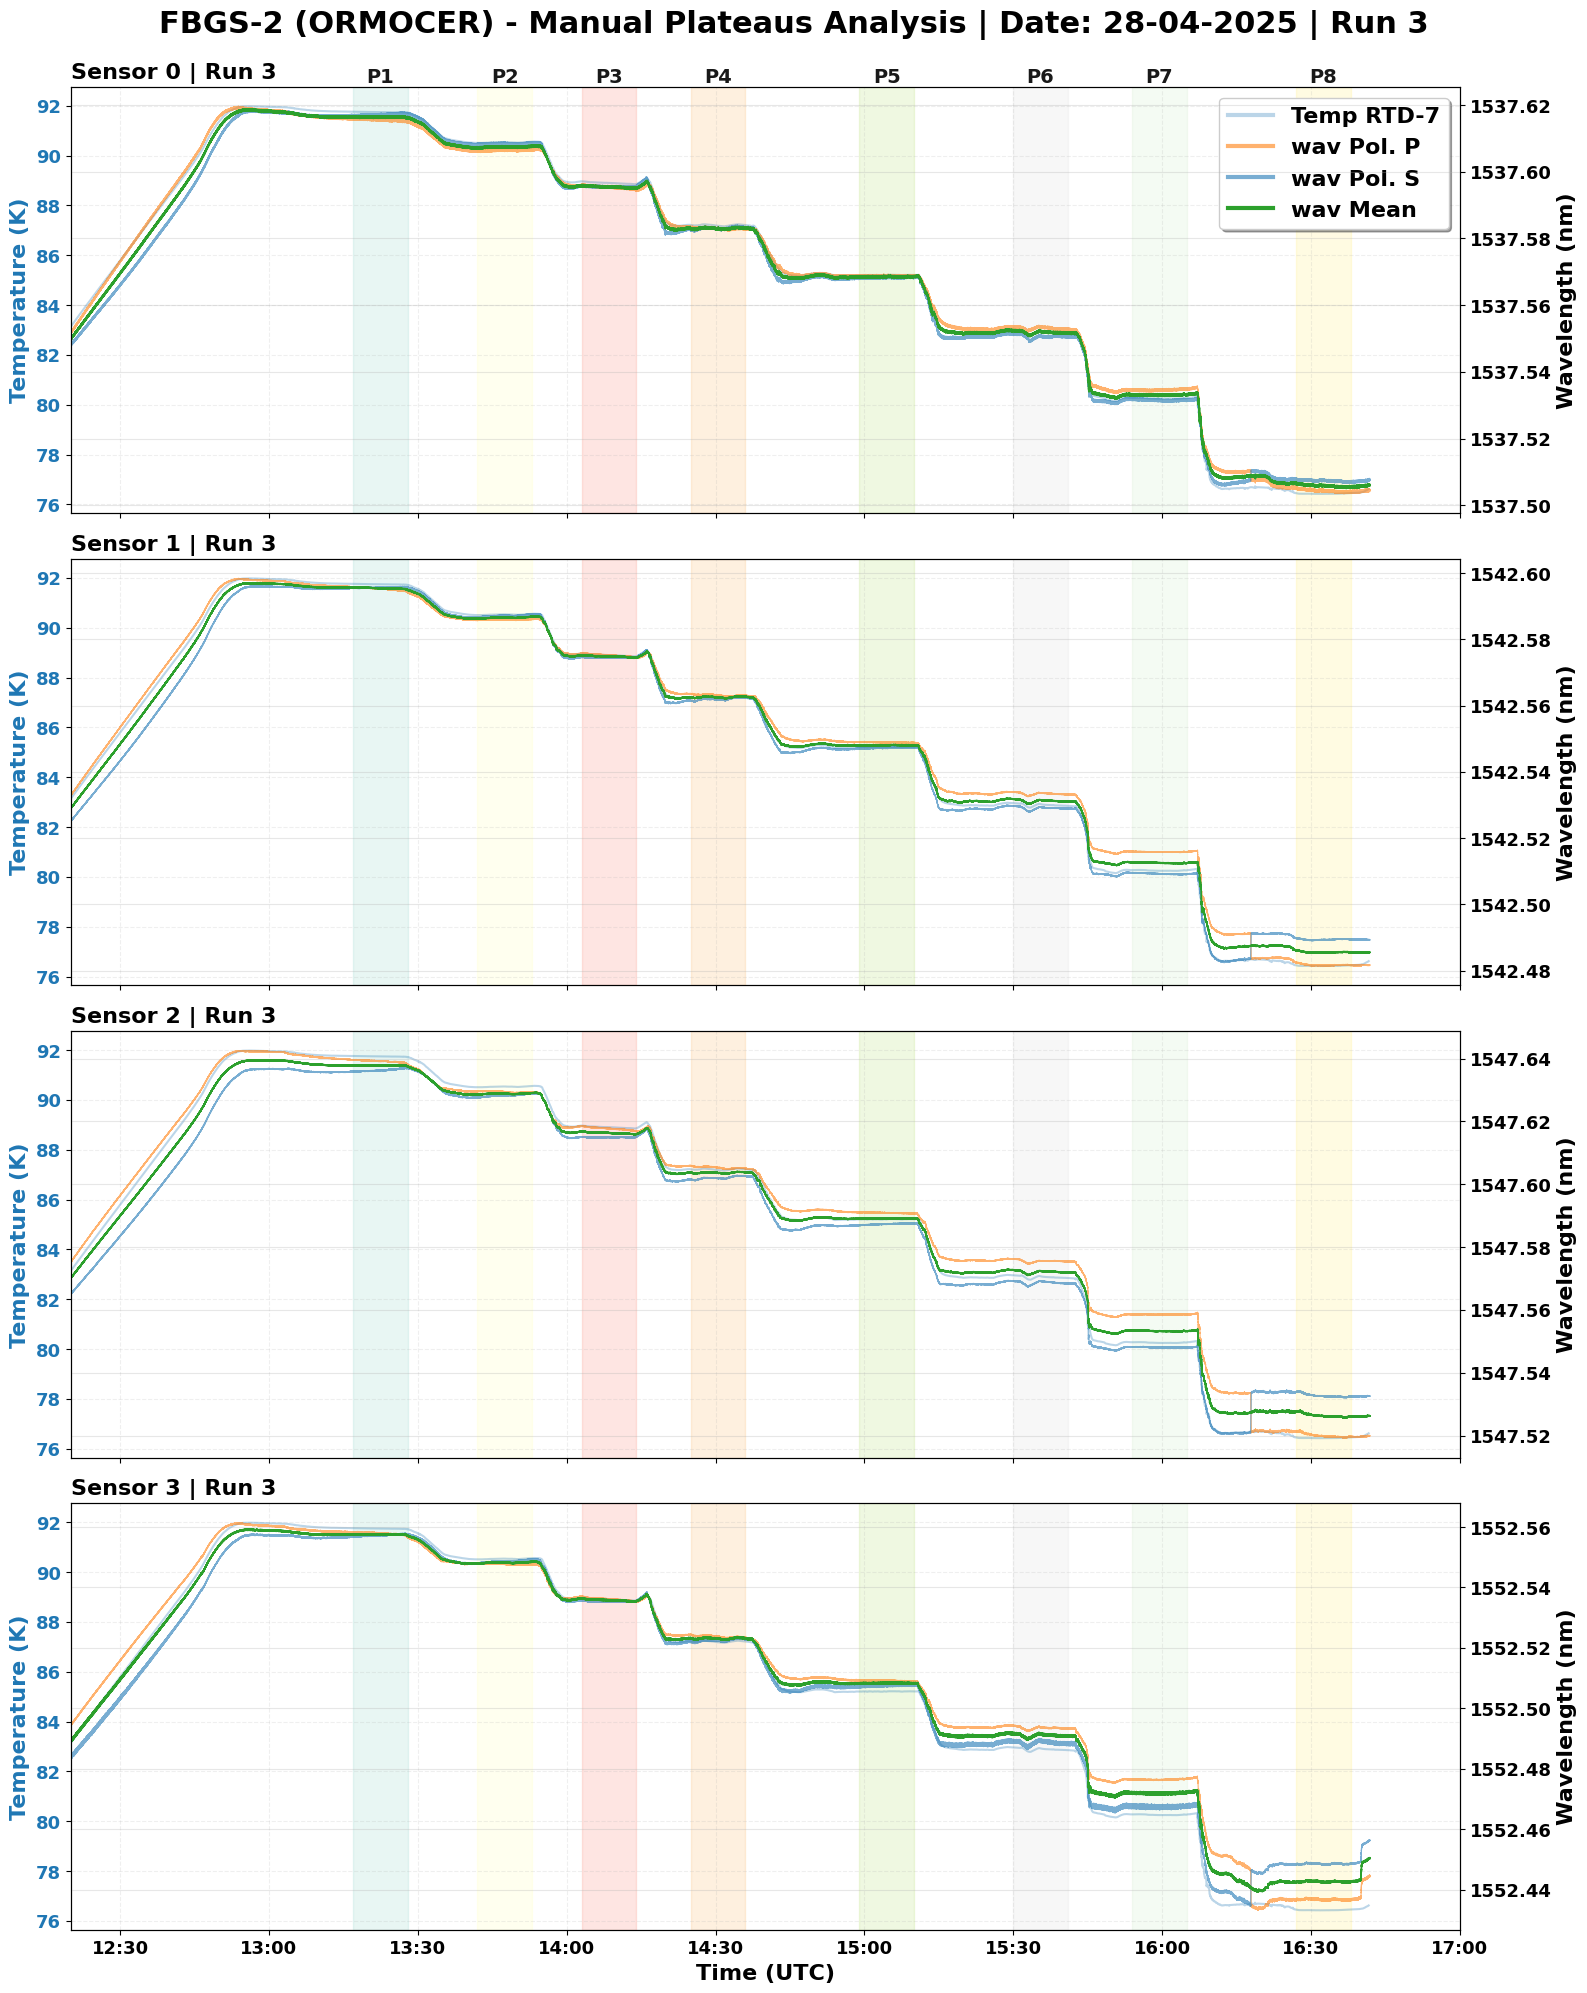

✅ Plot generated successfully from 12:20 to 17:00


In [14]:
# ============================================================================
# 📊 MULTI-SENSOR ANALYSIS: FBGS-2 (ORMOCER) | RUN 3
# Time-Series: Temperature vs Wavelength (P, S, and Mean)
# 4 Subplots (Sensors 0-3) with Shaded Plateau Regions
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import numpy as np

print("="*85)
print("📊 GENERATING MULTI-SENSOR PROFILE: FBGS-2 (RUN 3)")
print("="*85)

# --- Configuration ---
SENSORS = [0, 1, 2, 3]
RTD_REF_IDX = 7  # Capsule RTD
DATE_STR = "28-04-2025"
START_TIME = datetime.time(12, 20, 0) 
# 1. ACTUALIZACIÓN: Añadido tiempo de corte final
END_TIME = datetime.time(17, 0, 0)  # ← Ajusta aquí la hora de fin

# Get global temperature data
times_temp = loader.get_temp_times()
temp_ref = loader.get_temperature(sensor_idx=RTD_REF_IDX)
# Actualización de máscara con inicio y fin
mask_temp = [(t.time() >= START_TIME) and (t.time() <= END_TIME) for t in times_temp]

# Get global peak times
times_wav = loader.get_peak_times()
# Actualización de máscara con inicio y fin
mask_wav = [(t.time() >= START_TIME) and (t.time() <= END_TIME) for t in times_wav]

# Plateaus from detector
plateaus = detector.plateaus.get('common', [])

# --- Plotting ---
fig, axes = plt.subplots(len(SENSORS), 1, figsize=(16, 5 * len(SENSORS)), sharex=True)

# Define Colors
color_p = '#ff7f0e'  # Orange
color_s = '#1f77b4'  # Blue
color_mean = '#2ca02c' # Green
color_temp = 'tab:blue'
plateau_cmap = plt.cm.Set3(np.linspace(0, 1, len(plateaus)))

for i, sensor_idx in enumerate(SENSORS):
    ax1 = axes[i]
    
    # Extraction and filtering using the mask
    w_p = loader.get_wavelength(pol_idx=0, sensor_idx=sensor_idx, unit='um')[mask_wav] * 1000
    w_s = loader.get_wavelength(pol_idx=1, sensor_idx=sensor_idx, unit='um')[mask_wav] * 1000
    w_mean = (w_p + w_s) / 2.0
    
    # --- Left Axis: Temperature ---
    ax1.set_ylabel('Temperature (K)', color=color_temp, fontsize=16, fontweight='bold')
    ax1.plot(times_temp[mask_temp], temp_ref[mask_temp], color=color_temp, 
             linewidth=1.5, alpha=0.3, label=f'Temp RTD-{RTD_REF_IDX}')
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=13)
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')
    
    # --- Right Axis: Wavelengths (P, S, Mean) ---
    ax2 = ax1.twinx()
    ax2.plot(times_wav[mask_wav], w_p, color=color_p, linewidth=0.8, alpha=0.6, label='wav Pol. P')
    ax2.plot(times_wav[mask_wav], w_s, color=color_s, linewidth=0.8, alpha=0.6, label='wav Pol. S')
    ax2.plot(times_wav[mask_wav], w_mean, color=color_mean, linewidth=1.2, alpha=1.0, label='wav Mean')
    
    ax2.set_ylabel('Wavelength (nm)', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=13)
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')
    ax2.ticklabel_format(useOffset=False, axis='y')
    
    # --- Shaded Plateaus ---
    for j, (plat, p_color) in enumerate(zip(plateaus, plateau_cmap), 1):
        t0 = datetime.datetime.fromtimestamp(plat['t0'])
        tfin = datetime.datetime.fromtimestamp(plat['tfin'])
        # Solo dibujamos el plateau si está dentro del rango visible
        if tfin.time() >= START_TIME and t0.time() <= END_TIME:
            ax1.axvspan(t0, tfin, alpha=0.2, color=p_color, zorder=1)
            if i == 0:
                mid_time = t0 + (tfin - t0) / 2
                # Evitar poner texto fuera de los límites
                if START_TIME <= mid_time.time() <= END_TIME:
                    ax1.text(mid_time, ax1.get_ylim()[1], f'P{j}', fontsize=14, ha='center', va='bottom', fontweight='bold', alpha=0.9)

    # Subplot Titles & Grid
    ax1.set_title(f'Sensor {sensor_idx} | Run 3', loc='left', fontsize=16, fontweight='bold')
    ax1.grid(alpha=0.2, linestyle='--')
    
    # 2. AJUSTE DE LÍMITES: Inicio y Fin exactos
    ax1.set_xlim(left=datetime.datetime.combine(times_wav[0].date(), START_TIME),
                 right=datetime.datetime.combine(times_wav[0].date(), END_TIME))

    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=16, fancybox=True, shadow=True)
        for line in leg.get_lines():
            line.set_linewidth(3)
        for text in leg.get_texts():
            text.set_fontweight('bold')

# Common X-axis formatting
axes[-1].set_xlabel('Time (UTC)', fontsize=16, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=13)
for label in axes[-1].get_xticklabels():
    label.set_fontweight('bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.suptitle(f'FBGS-2 (ORMOCER) - Manual Plateaus Analysis | Date: {DATE_STR} | Run 3', 
             fontsize=22, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print(f"✅ Plot generated successfully from {START_TIME.strftime('%H:%M')} to {END_TIME.strftime('%H:%M')}")

 TEST: ANÁLISIS DE UN SENSOR INDIVIDUAL (FBGS-2)

 VERIFICACIÓN DE PLATEAUS:
--------------------------------------------------------------------------------
Total de plateaus configurados: 8
  #1: 13:17:00 → 13:28:00 (11.0 min)
  #2: 13:42:00 → 13:53:00 (11.0 min)
  #3: 14:03:00 → 14:14:00 (11.0 min)
  #4: 14:25:00 → 14:36:00 (11.0 min)
  #5: 14:59:00 → 15:10:00 (11.0 min)
  #6: 15:30:00 → 15:41:00 (11.0 min)
  #7: 15:54:00 → 16:05:00 (11.0 min)
  #8: 16:27:00 → 16:38:00 (11.0 min)
--------------------------------------------------------------------------------

 SENSOR SELECCIONADO:
   Fibra: FBGS-2 (ORMOCER)
   Sensor índice: 1
   Polarización: S



Sensitivity Analysis: RTD 8 vs FBG 1 (Pol. S)
Sensitivity:  7.1360 ± 0.1769 pm/K
R²:           0.996328
Data points:  8


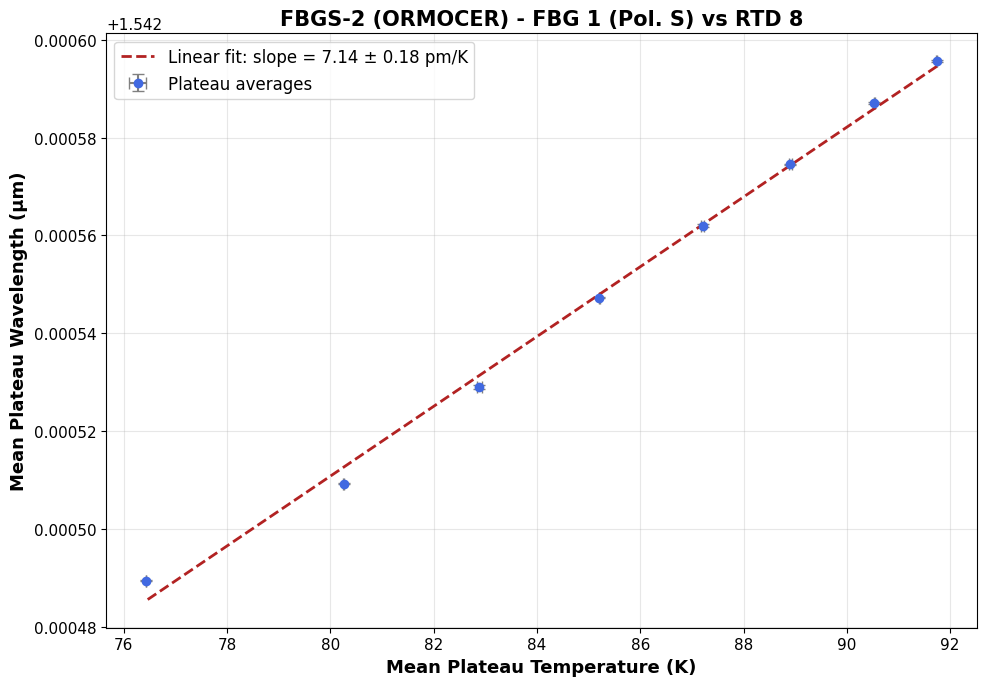


 ANÁLISIS COMPLETADO
Sensibilidad térmica: 7.14 ± 0.18 pm/K
R²: 0.996328
Puntos usados: 8


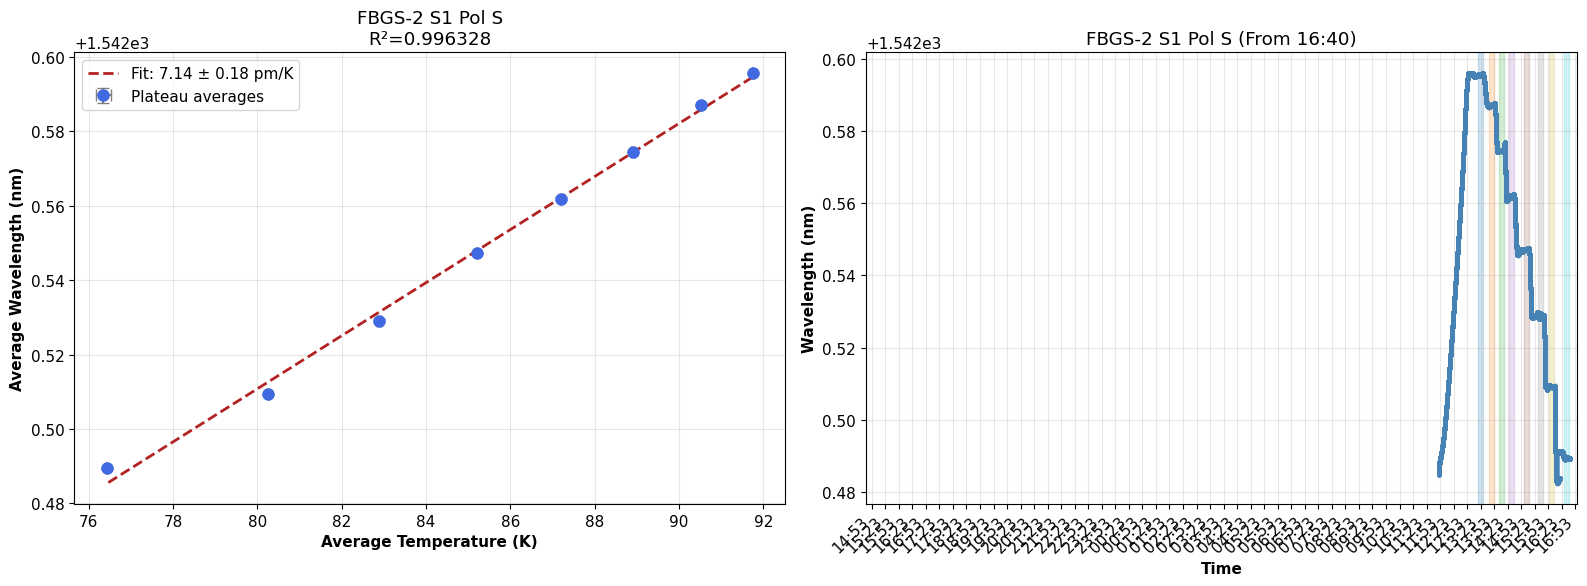


 Si este test va bien, ejecuta la celda de análisis global de todos los sensores.


In [15]:
# ============================================================================
# CELDA 30: TEST - Análisis de un sensor FBGS-2 (sensor 1, pol S)
# ============================================================================

import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

print("="*80)
print(" TEST: ANÁLISIS DE UN SENSOR INDIVIDUAL (FBGS-2)")
print("="*80)

# Verificación de plateaus
print("\n VERIFICACIÓN DE PLATEAUS:")
print("-"*80)
print(f"Total de plateaus configurados: {len(detector.plateaus.get('common', []))}")
for i, plat in enumerate(detector.plateaus.get('common', []), 1):
    t0 = datetime.datetime.fromtimestamp(plat['t0'])
    tfin = datetime.datetime.fromtimestamp(plat['tfin'])
    duration_min = (tfin - t0).total_seconds() / 60
    print(f"  #{i}: {t0.strftime('%H:%M:%S')} → {tfin.strftime('%H:%M:%S')} ({duration_min:.1f} min)")
print("-"*80)

# Sensor de prueba
TEST_SENSOR_IDX = 1  # FBGS-2 sensor 1
TEST_POL_IDX = 1     # Polarización S
TEST_FIBER_NAME = "FBGS-2 (ORMOCER)"

print(f"\n SENSOR SELECCIONADO:")
print(f"   Fibra: {TEST_FIBER_NAME}")
print(f"   Sensor índice: {TEST_SENSOR_IDX}")
print(f"   Polarización: {POLARIZATION_LABELS[TEST_POL_IDX]}")
print("="*80)

# Ejecutar análisis
result = analyzer.calculate_sensitivity(
    sensor_temp=7,
    sensor_wav_tuple=(TEST_POL_IDX, TEST_SENSOR_IDX),
    plot=True
)

if result is None:
    print("\n ERROR EN EL ANÁLISIS: datos insuficientes o error en el procesamiento")
else:
    data = analyzer.extract_plateau_averages(
        sensor_temp=7,
        sensor_wav_tuple=(TEST_POL_IDX, TEST_SENSOR_IDX)
    )

    print("\n" + "="*80)
    print(" ANÁLISIS COMPLETADO")
    print("="*80)
    print(f"Sensibilidad térmica: {result['slope']*1e6:.2f} ± {result['slope_err']*1e6:.2f} pm/K")
    print(f"R²: {result['r_squared']:.6f}")
    print(f"Puntos usados: {len(data['temp_means'])}")

    # Plot combinado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Fit lineal
    fit_line = result['slope'] * data['temp_means'] + result['intercept']
    ax1.errorbar(data['temp_means'], data['wav_means']*1000,
                 xerr=data['temp_stds'], yerr=data['wav_stds']*1000,
                 fmt='o', color='royalblue', ecolor='gray', capsize=4, markersize=8,
                 label='Plateau averages')
    ax1.plot(data['temp_means'], fit_line*1000, '--', color='firebrick', linewidth=2,
             label=f"Fit: {result['slope']*1e6:.2f} ± {result['slope_err']*1e6:.2f} pm/K")
    ax1.set_xlabel('Average Temperature (K)')
    ax1.set_ylabel('Average Wavelength (nm)')
    ax1.set_title(f'FBGS-2 S{TEST_SENSOR_IDX} Pol {POLARIZATION_LABELS[TEST_POL_IDX]}\nR²={result["r_squared"]:.6f}')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Serie temporal
    peak_times = loader.get_peak_times()
    wavelength_full = loader.get_wavelength(pol_idx=TEST_POL_IDX, sensor_idx=TEST_SENSOR_IDX, unit='um')
    time_cutoff = datetime.datetime(2026, 4, 27, 14, 40, 0)

    mask = peak_times >= time_cutoff
    peak_times_filtered = peak_times[mask]
    wavelength_filtered = wavelength_full[mask]

    ax2.plot(peak_times_filtered, wavelength_filtered*1000, 'o-', color='steelblue', markersize=2,
             linewidth=0.5, alpha=0.7, label='Wavelength')

    colors = plt.cm.tab10(np.linspace(0, 1, len(detector.plateaus['common'])))
    for i, (plat, color) in enumerate(zip(detector.plateaus['common'], colors), 1):
        t0 = datetime.datetime.fromtimestamp(plat['t0'])
        tfin = datetime.datetime.fromtimestamp(plat['tfin'])
        ax2.axvspan(t0, tfin, alpha=0.2, color=color, label=f'Plateau {i}')

    ax2.set_xlabel('Time')
    ax2.set_ylabel('Wavelength (nm)')
    ax2.set_title(f'FBGS-2 S{TEST_SENSOR_IDX} Pol {POLARIZATION_LABELS[TEST_POL_IDX]} (From 16:40)')
    ax2.grid(alpha=0.3)
    ax2.set_xlim(left=time_cutoff)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

print("\n Si este test va bien, ejecuta la celda de análisis global de todos los sensores.")
print("="*80)

In [16]:
# ============================================================================
# VERIFICACIÓN: Estructura de datos y selección de sensores
# ============================================================================

print("="*80)
print(" VERIFICACIÓN DE ESTRUCTURA DE DATOS")
print("="*80)

# 1. Verificar forma de los datos
wav_data = loader.peak_data["wav"]
print(f"\n Forma de datos wavelength: {wav_data.shape}")
print(f"   Interpretación: (tiempo={wav_data.shape[0]}, polarización={wav_data.shape[1]}, sensor={wav_data.shape[2]})")

# 2. Verificar FIBER_MAP
print(f"\n  FIBER_MAP configurado:")
for fiber, sensors in FIBER_MAP.items():
    print(f"   {fiber}: sensores {sensors}")

# 3. Verificar polarizaciones
print(f"\n POLARIZATION_LABELS:")
for pol_idx, label in POLARIZATION_LABELS.items():
    print(f"   {pol_idx}: {label}")

# 4. COMPARACIÓN: Mismo sensor, ambas polarizaciones
print("\n" + "="*80)
print(" COMPARACIÓN: Sensor 0 - Polarización P vs S")
print("="*80)

TEST_SENSOR = 0

results_comparison = []
for pol_idx in [0, 1]:  # P y S
    result = analyzer.calculate_sensitivity(
        sensor_temp=7,
        sensor_wav_tuple=(pol_idx, TEST_SENSOR),
        plot=False
    )
    
    if result is not None:
        results_comparison.append({
            'pol_idx': pol_idx,
            'pol_label': POLARIZATION_LABELS[pol_idx],
            'slope': result['slope'] * 1e6,  # pm/K
            'slope_err': result['slope_err'] * 1e6,
            'r_squared': result['r_squared'],
            'n_points': result['n_points']
        })

# Mostrar tabla comparativa
print(f"\n RESULTADOS PARA SENSOR {TEST_SENSOR}:")
print("-"*80)
print(f"{'Polarización':<15} {'Sensibilidad (pm/K)':<25} {'R²':<12} {'Puntos'}")
print("-"*80)

for res in results_comparison:
    print(f"{res['pol_label']:<15} {res['slope']:.2f} ± {res['slope_err']:.2f} pm/K{' ':<10} "
          f"{res['r_squared']:.6f}   {res['n_points']}")

# Calcular diferencia
if len(results_comparison) == 2:
    diff = abs(results_comparison[0]['slope'] - results_comparison[1]['slope'])
    avg = (results_comparison[0]['slope'] + results_comparison[1]['slope']) / 2
    diff_percent = (diff / avg) * 100
    
    print("-"*80)
    print(f"\n ANÁLISIS:")
    print(f"   Diferencia absoluta: {diff:.2f} pm/K")
    print(f"   Diferencia relativa: {diff_percent:.1f}%")
    
    if diff_percent > 10:
        print(f"\n  ADVERTENCIA: Diferencia > 10% entre polarizaciones del mismo sensor")
        print(f"   Esto puede indicar:")
        print(f"   1. Problema con indexación de datos")
        print(f"   2. Comportamiento físico real diferente entre polarizaciones")
        print(f"   3. Calidad de datos diferente entre polarizaciones")
    else:
        print(f"\n Diferencia < 10% - Consistente entre polarizaciones")

print("="*80)

# 5. VERIFICACIÓN ADICIONAL: Mostrar valores wavelength crudos
print("\n🔍 VERIFICACIÓN DE VALORES CRUDOS (primer plateau):")
print("-"*80)

# Obtener primer plateau
first_plateau = detector.plateaus['common'][0]
t0 = datetime.datetime.fromtimestamp(first_plateau['t0'])
tfin = datetime.datetime.fromtimestamp(first_plateau['tfin'])

peak_times = loader.get_peak_times()
mask = (peak_times >= t0) & (peak_times <= tfin)

print(f"Plateau: {t0.strftime('%H:%M:%S')} → {tfin.strftime('%H:%M:%S')}")
print(f"\nSensores FBGS-2 (0-3):")

for sensor_idx in range(4):
    print(f"\nSensor {sensor_idx}:")
    for pol_idx in [0, 1]:
        wav = loader.get_wavelength(pol_idx=pol_idx, sensor_idx=sensor_idx, unit='nm')
        wav_plateau = wav[mask]
        wav_plateau = wav_plateau[~np.isnan(wav_plateau)]  # Quitar NaN
        
        if len(wav_plateau) > 0:
            print(f"  Pol {POLARIZATION_LABELS[pol_idx]}: mean={np.mean(wav_plateau):.6f} nm, "
                  f"std={np.std(wav_plateau):.6f} nm, n={len(wav_plateau)}")
        else:
            print(f"  Pol {POLARIZATION_LABELS[pol_idx]}:  NO HAY DATOS")

print("="*80)

 VERIFICACIÓN DE ESTRUCTURA DE DATOS

 Forma de datos wavelength: (2190000, 2, 4)
   Interpretación: (tiempo=2190000, polarización=2, sensor=4)

  FIBER_MAP configurado:
   FBGS-2 (ORMOCER): sensores [0, 1, 2, 3]

 POLARIZATION_LABELS:
   0: P
   1: S

 COMPARACIÓN: Sensor 0 - Polarización P vs S



Sensitivity Analysis: RTD 8 vs FBG 0 (Pol. P)
Sensitivity:  7.1749 ± 0.0651 pm/K
R²:           0.999507
Data points:  8

Sensitivity Analysis: RTD 8 vs FBG 0 (Pol. S)
Sensitivity:  7.2617 ± 0.0960 pm/K
R²:           0.998952
Data points:  8

 RESULTADOS PARA SENSOR 0:
--------------------------------------------------------------------------------
Polarización    Sensibilidad (pm/K)       R²           Puntos
--------------------------------------------------------------------------------
P               7.17 ± 0.07 pm/K           0.999507   8
S               7.26 ± 0.10 pm/K           0.998952   8
--------------------------------------------------------------------------------

 ANÁLISIS:
   Diferencia absoluta: 0.09 pm/K
   Diferencia relativa: 1.2%

 Diferencia < 10% - Consistente entre polarizaciones

🔍 VERIFICACIÓN DE VALORES CRUDOS (primer plateau):
--------------------------------------------------------------------------------
Plateau: 13:17:00 → 13:28:00

Sensores FBGS-2 (0-3)

In [17]:
# ============================================================================
# DIAGNÓSTICO PROFUNDO: Mapeo de datos y verificación cruzada
# ============================================================================

print("="*80)
print(" DIAGNÓSTICO PROFUNDO: VERIFICACIÓN DE INDEXACIÓN")
print("="*80)

# ============================================================================
# PASO 1: Inspeccionar datos crudos del ROOT file
# ============================================================================
print("\n📂 PASO 1: Estructura del archivo ROOT")
print("-"*80)

import uproot
with uproot.open(INPUT_FILENAME) as file:
    peak_tree = file["peak"]
    print(f"Árbol 'peak' - Ramas disponibles: {peak_tree.keys()}")
    
    # Leer una muestra pequeña
    sample = peak_tree.arrays(library="np", entry_stop=10)
    wav_sample = sample["wav"]
    print(f"\nForma de 'wav': {wav_sample.shape}")
    print(f"  → Dimensiones: (n_entries={wav_sample.shape[0]}, dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]})")

# ============================================================================
# PASO 2: Verificar valores de wavelength para TODOS los sensores
# ============================================================================
print("\n PASO 2: Wavelength promedio en primer plateau (para todos los sensores)")
print("-"*80)

first_plateau = detector.plateaus['common'][0]
t0 = datetime.datetime.fromtimestamp(first_plateau['t0'])
tfin = datetime.datetime.fromtimestamp(first_plateau['tfin'])

peak_times = loader.get_peak_times()
mask = (peak_times >= t0) & (peak_times <= tfin)

print(f"Plateau: {t0.strftime('%H:%M:%S')} → {tfin.strftime('%H:%M:%S')}\n")

# Crear tabla de wavelengths
print(f"{'Sensor':<10} {'Pol P (nm)':<15} {'Pol S (nm)':<15} {'Diff (pm)':<12}")
print("-"*80)

for sensor_idx in range(0):
    wav_p = loader.get_wavelength(pol_idx=0, sensor_idx=sensor_idx, unit='nm')
    wav_s = loader.get_wavelength(pol_idx=1, sensor_idx=sensor_idx, unit='nm')
    
    wav_p_plateau = wav_p[mask]
    wav_s_plateau = wav_s[mask]
    
    # Quitar NaN
    wav_p_plateau = wav_p_plateau[~np.isnan(wav_p_plateau)]
    wav_s_plateau = wav_s_plateau[~np.isnan(wav_s_plateau)]
    
    if len(wav_p_plateau) > 0 and len(wav_s_plateau) > 0:
        mean_p = np.mean(wav_p_plateau)
        mean_s = np.mean(wav_s_plateau)
        diff = abs(mean_p - mean_s) * 1000  # pm
        
        print(f"S{sensor_idx:<9} {mean_p:<15.6f} {mean_s:<15.6f} {diff:<12.2f}")
    else:
        print(f"S{sensor_idx:<9} {'NO DATA':<15} {'NO DATA':<15} {'N/A':<12}")

# ============================================================================
# PASO 3: Verificar que loader.get_wavelength() devuelve datos correctos
# ============================================================================
print("\n🔍 PASO 3: Verificación directa de indexación")
print("-"*80)

print("\nComparando acceso directo vs método get_wavelength():")
print("Sensor 1, Polarización 0 (P):\n")

# Acceso directo
wav_direct = loader.peak_data["wav"][:100, 0, 0]  # Primeras 100 muestras, pol=0, sensor=1
print(f"  Acceso directo wav[:100, 0, 1]:")
print(f"    Mean: {np.nanmean(wav_direct)*1e9:.6f} nm")
print(f"    Std:  {np.nanstd(wav_direct)*1e9:.6f} nm")

# Método get_wavelength
wav_method = loader.get_wavelength(pol_idx=0, sensor_idx=0, unit='nm')[:100]
print(f"\n  Método get_wavelength(pol_idx=0, sensor_idx=0):")
print(f"    Mean: {np.nanmean(wav_method):.6f} nm")
print(f"    Std:  {np.nanstd(wav_method):.6f} nm")

# Verificar igualdad
if np.allclose(wav_direct*1e9, wav_method, equal_nan=True):
    print("\n   COINCIDEN - Indexación correcta")
else:
    print("\n   NO COINCIDEN - ¡PROBLEMA DE INDEXACIÓN!")

# ============================================================================
# PASO 4: Análisis de consistencia de sensibilidades
# ============================================================================
print("\n PASO 4: Análisis de consistencia")
print("-"*80)

# Tabla de resultados obtenidos
results_table = [
    #('S0', 'P', , , ),
    #('S0', 'S', , , ),
]

print("\nPatrones detectados:")
print("-"*80)

for i in range(0, len(results_table), 2):
    sensor_name = results_table[i][0]
    slope_p = results_table[i][2]
    slope_s = results_table[i+1][2]
    
    diff = abs(slope_p - slope_s)
    avg = (slope_p + slope_s) / 2
    diff_pct = (diff / avg) * 100
    
    pattern = "P > S" if slope_p > slope_s else "S > P"
    flag = "⚠️" if diff_pct > 10 else "✓"
    
    print(f"{sensor_name}: {pattern:<10} Diff={diff:.2f} pm/K ({diff_pct:.1f}%)  {flag}")


print("="*80)

 DIAGNÓSTICO PROFUNDO: VERIFICACIÓN DE INDEXACIÓN

📂 PASO 1: Estructura del archivo ROOT
--------------------------------------------------------------------------------
Árbol 'peak' - Ramas disponibles: ['t', 'wav', 'sweep', 'ch', 'pos']

Forma de 'wav': (10, 2, 4)
  → Dimensiones: (n_entries=10, dim1=2, dim2=4)

 PASO 2: Wavelength promedio en primer plateau (para todos los sensores)
--------------------------------------------------------------------------------
Plateau: 13:17:00 → 13:28:00

Sensor     Pol P (nm)      Pol S (nm)      Diff (pm)   
--------------------------------------------------------------------------------

🔍 PASO 3: Verificación directa de indexación
--------------------------------------------------------------------------------

Comparando acceso directo vs método get_wavelength():
Sensor 1, Polarización 0 (P):

  Acceso directo wav[:100, 0, 1]:
    Mean: 1537.503188 nm
    Std:  0.000131 nm

  Método get_wavelength(pol_idx=0, sensor_idx=0):
    Mean: 1537.503

---

##  **Plot: Espectro Individual en Tiempo Específico**

Visualización de un espectro completo para un sensor y polarización en un momento dado.

 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS

 Tree 'spectrum' encontrado
   Ramas disponibles: ['t', 'wav']

 Estructura de datos:
   't': shape=(5, 2), dtype=float64
   'wav': shape=(5, 2, 3, 39200), dtype=float64

   Detalle de 'wav' (espectros completos):
      Shape: (5, 2, 3, 39200)
      → Dimensiones: (n_entries=5, n_channels=2, n_points=3)

    Número de canales: 2
      (Esperamos 10 canales: 5 sensores × 2 polarizaciones)

    Mapeo probable de canales:
      Canal  0: Sensor 0 (Sensor 0), Pol P
      Canal  1: Sensor 0 (Sensor 0), Pol S

    Timestamps ('t'):
      Shape: (5, 2)
      Primeros 3 valores: [[1.77737441e+09 1.77737441e+09]
 [1.77737441e+09 1.77737441e+09]
 [1.77737441e+09 1.77737442e+09]]
      Rango: 2026-04-28 13:06:50.555492 → 2026-04-28 13:06:58.523504

 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
   Timestamps shape: (2202, 2) → usando columna 0
   Tiempo objetivo:     2026-04-27 14:20:00
   Tiempo más cercano:  2026-04-28 13:06:50
   Diferencia:     

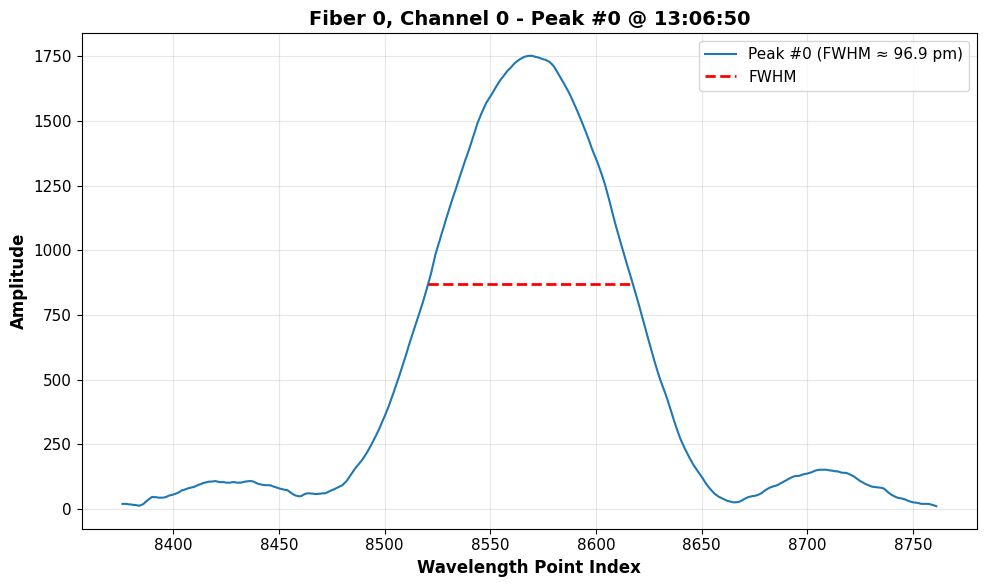


 Plot generado exitosamente


In [18]:
# ============================================================================
# PLOT: Espectro individual en tiempo específico
# ============================================================================

from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

# Tiempo a visualizar (en el primer plateau por defecto)
TARGET_TIME = datetime.datetime(2026, 4, 27, 14, 20, 0)  # 14:20:00

# Fibra y canal a visualizar
PLOT_FIBER_IDX = 0    # 0=Primera fibra (ORMOCER multiplexado), 1=Segunda fibra
PLOT_CHANNEL_IDX = 0  # 0=Canal con 4 picos, 1=Canal con 1 pico, 2=vacío

# Selección de pico específico
PLOT_PEAK_IDX = 0     # Índice del pico a visualizar (0=primero, 1=segundo, etc.)
                      # Solo relevante si el canal tiene múltiples picos

# Mapeo aproximado:
# PLOT_CHANNEL_IDX=0, PLOT_PEAK_IDX=0 → Sensor S0 (λ ≈ 1537 nm)
# PLOT_CHANNEL_IDX=0, PLOT_PEAK_IDX=1 → Sensor S1 (λ ≈ 1542 nm)
# PLOT_CHANNEL_IDX=0, PLOT_PEAK_IDX=2 → Sensor S2 (λ ≈ 1547 nm)
# PLOT_CHANNEL_IDX=0, PLOT_PEAK_IDX=3 → Sensor S3 (λ ≈ 1552 nm)
# PLOT_CHANNEL_IDX=1, PLOT_PEAK_IDX=0 → Sensor S4 PEEK-3 (λ ≈ 1538 nm)

# ============================================================================
# PASO 1: Verificar estructura del tree de espectros
# ============================================================================

print("="*80)
print(" VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS")
print("="*80)

import uproot

with uproot.open(INPUT_FILENAME) as file:
    # Verificar que existe el tree 'spectrum'
    if 'spectrum' in file:
        spectrum_tree = file['spectrum']
        print(f"\n Tree 'spectrum' encontrado")
        print(f"   Ramas disponibles: {spectrum_tree.keys()}")
        
        # Leer una muestra
        sample = spectrum_tree.arrays(library="np", entry_stop=5)
        
        print(f"\n Estructura de datos:")
        for key in sample.keys():
            data = sample[key]
            print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
        
        # Verificar estructura de 'wav' en sweep
        if 'wav' in sample:
            wav_spectrum_sample = sample['wav']
            print(f"\n   Detalle de 'wav' (espectros completos):")
            print(f"      Shape: {wav_spectrum_sample.shape}")
            print(f"      → Dimensiones: (n_entries={wav_spectrum_sample.shape[0]}, "
                  f"n_channels={wav_spectrum_sample.shape[1]}, n_points={wav_spectrum_sample.shape[2]})")
            
            # ¿Cuántos canales hay?
            n_channels = wav_spectrum_sample.shape[1]
            print(f"\n    Número de canales: {n_channels}")
            print(f"      (Esperamos 10 canales: 5 sensores × 2 polarizaciones)")
            
            # Mapeo probable: canal = sensor_idx * 2 + pol_idx
            print(f"\n    Mapeo probable de canales:")
            for sensor in range(5):
                for pol in range(2):
                    ch = sensor * 2 + pol
                    pol_name = 'P' if pol == 0 else 'S'
                    fiber = FIBER_MAP.get(sensor, f'Sensor {sensor}')
                    if ch < n_channels:
                        print(f"      Canal {ch:2d}: Sensor {sensor} ({fiber}), Pol {pol_name}")
        
        # Verificar timestamps
        if 't' in sample:
            t_sample = sample['t']
            print(f"\n    Timestamps ('t'):")
            print(f"      Shape: {t_sample.shape}")
            print(f"      Primeros 3 valores: {t_sample[:3]}")
            if t_sample.ndim == 1:
                print(f"      Rango: {datetime.datetime.fromtimestamp(t_sample[0])} → "
                      f"{datetime.datetime.fromtimestamp(t_sample[-1])}")
            else:
                print(f"      Rango: {datetime.datetime.fromtimestamp(t_sample[0, 0])} → "
                      f"{datetime.datetime.fromtimestamp(t_sample[-1, 0])}")
    else:
        print("\n Tree 'spectrum' NO encontrado en el archivo ROOT")
        print("   Trees disponibles:", file.keys())

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

with uproot.open(INPUT_FILENAME) as file:
    spectrum_tree = file['spectrum']
    
    # Cargar todos los timestamps
    timestamps_raw = spectrum_tree['t'].array(library="np")
    
    # Si timestamps tiene forma 2D, usar primera columna
    if timestamps_raw.ndim == 2:
        timestamps = timestamps_raw[:, 0]
        print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
    else:
        timestamps = timestamps_raw
    
    # Convertir TARGET_TIME a timestamp Unix
    target_timestamp = TARGET_TIME.timestamp()
    
    # Encontrar índice más cercano
    time_diffs = np.abs(timestamps - target_timestamp)
    closest_idx = np.argmin(time_diffs)
    closest_timestamp = timestamps[closest_idx]
    closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
    
    print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
    print(f"   Índice del evento:   {closest_idx}")
    
    # Cargar el evento específico
    wav_data = spectrum_tree['wav'].array(library="np", entry_start=closest_idx, entry_stop=closest_idx+1)[0]
    
    print(f"\n Datos del evento:")
    print(f"   Shape: {wav_data.shape}")
    
    # Analizar estructura real
    if wav_data.ndim == 3:
        print(f"   → (dim0={wav_data.shape[0]}, dim1={wav_data.shape[1]}, n_wavelength_points={wav_data.shape[2]})")
    elif wav_data.ndim == 2:
        print(f"   → (n_channels={wav_data.shape[0]}, n_wavelength_points={wav_data.shape[1]})")
    else:
        print(f"   → Dimensiones: {wav_data.shape}")

# ============================================================================
# PASO 3: Extraer espectro del sensor y polarización seleccionados
# ============================================================================

print(f"\n EXTRAYENDO ESPECTRO")
print("="*80)

print(f"   Fibra:   {PLOT_FIBER_IDX} ({'Primera (PEEK-3)' if PLOT_FIBER_IDX == 0 else 'No hay segunda fibra'})")
print(f"   Canal:   {PLOT_CHANNEL_IDX}")
print(f"   Pico:    #{PLOT_PEAK_IDX}")

# Analizar estructura de wav_data
print(f"\n   Estructura de wav_data: {wav_data.shape}")

# Extraer espectro del canal completo
if PLOT_FIBER_IDX < wav_data.shape[0] and PLOT_CHANNEL_IDX < wav_data.shape[1]:
    spectrum_full = wav_data[PLOT_FIBER_IDX, PLOT_CHANNEL_IDX, :]
    print(f"    Espectro completo extraído: {len(spectrum_full)} puntos")
    print(f"      Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
    print(f"      NaN values: {np.sum(np.isnan(spectrum_full))}")
    
    # Detectar todos los picos en el espectro
    all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
    print(f"\n   🔍 Picos detectados en el canal: {len(all_peaks)}")
    for i, peak_pos in enumerate(all_peaks):
        print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
    
    # Seleccionar el pico específico
    if PLOT_PEAK_IDX < len(all_peaks):
        center_idx = all_peaks[PLOT_PEAK_IDX]
        print(f"\n    Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        spectrum = spectrum_full  # Guardamos el espectro completo para el análisis
    else:
        print(f"\n     ADVERTENCIA: PLOT_PEAK_IDX={PLOT_PEAK_IDX} está fuera de rango")
        print(f"      Solo hay {len(all_peaks)} picos. Usando el primero por defecto.")
        if len(all_peaks) > 0:
            center_idx = all_peaks[0]
            spectrum = spectrum_full
        else:
            print(f"    No se encontraron picos en el canal")
            center_idx = len(spectrum_full) // 2
            spectrum = spectrum_full
else:
    print(f"    ERROR: Índices ({PLOT_FIBER_IDX}, {PLOT_CHANNEL_IDX}) fuera de rango")
    spectrum = None
    center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis del pico y plotting
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"    Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Compute FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # assuming 1 pm per point
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except Exception as e:
        print(f"     Error calculando FWHM: {e}")
        fwhm_points = 50  # valor por defecto
        fwhm_pm = 50
        results_half = None
    
    # Define window around the peak
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"    Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)  # X-axis in pm
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"Fiber {PLOT_FIBER_IDX}, Channel {PLOT_CHANNEL_IDX}"
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Peak #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)")
    
    # Mark FWHM
    if results_half is not None:
        plt.hlines(results_half[1], results_half[2], results_half[3], 
                   color='red', linestyle='--', linewidth=2, label='FWHM')
    
    plt.xlabel("Wavelength Point Index", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitude", fontsize=12, fontweight='bold')
    plt.title(f"{fiber_name} - Peak #{PLOT_PEAK_IDX} @ {closest_time.strftime('%H:%M:%S')}", 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n Plot generado exitosamente")
else:
    print("\n No se pudo generar el plot (espectro vacío o inválido)")

🔬 ANALIZANDO SENSIBILIDAD TÉRMICA DE TODOS LOS SENSORES...

🔬 ANALYZING ALL SENSORS WITH RTD 8

📊 Fiber: FBGS-2 (ORMOCER)



Sensitivity Analysis: RTD 8 vs FBG 0 (Pol. P)
Sensitivity:  7.1749 ± 0.0651 pm/K
R²:           0.999507
Data points:  8


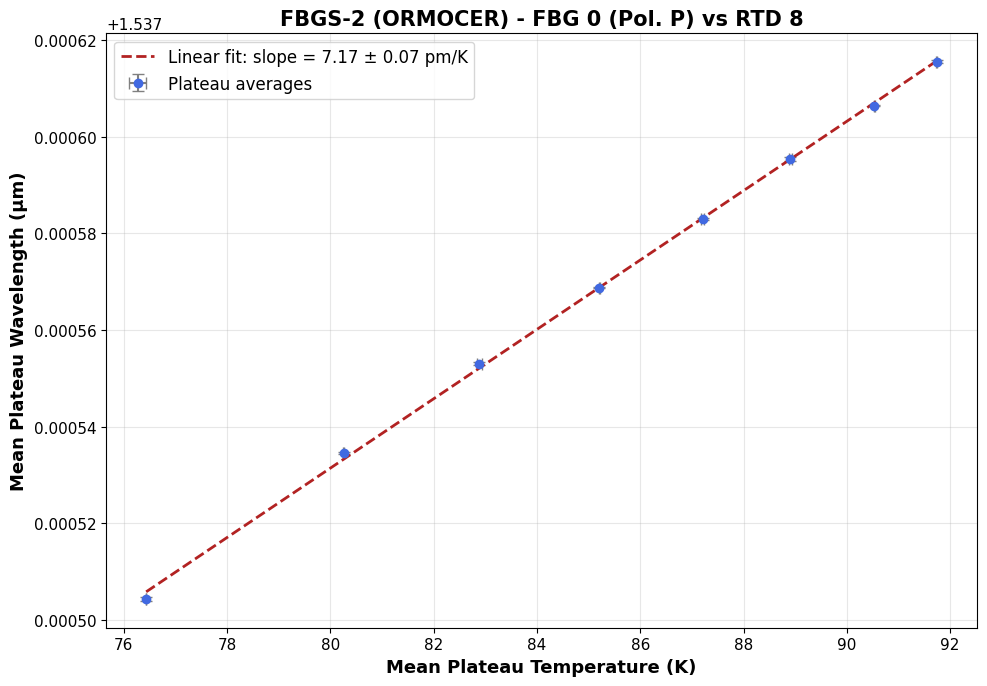


Sensitivity Analysis: RTD 8 vs FBG 0 (Pol. S)
Sensitivity:  7.2617 ± 0.0960 pm/K
R²:           0.998952
Data points:  8


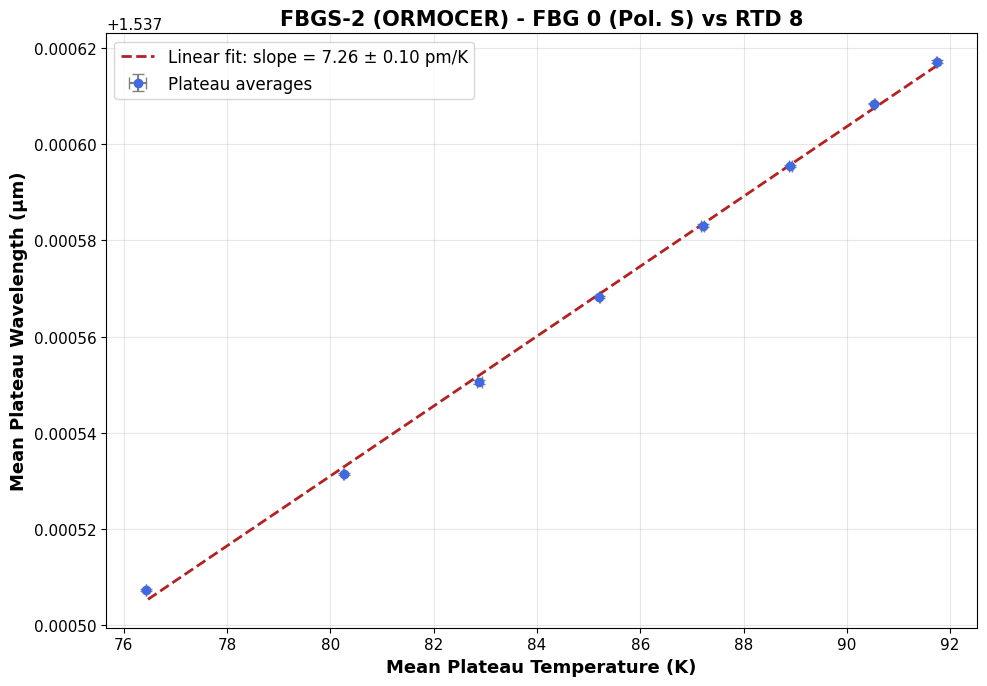


Sensitivity Analysis: RTD 8 vs FBG 1 (Pol. P)
Sensitivity:  7.2355 ± 0.1461 pm/K
R²:           0.997559
Data points:  8


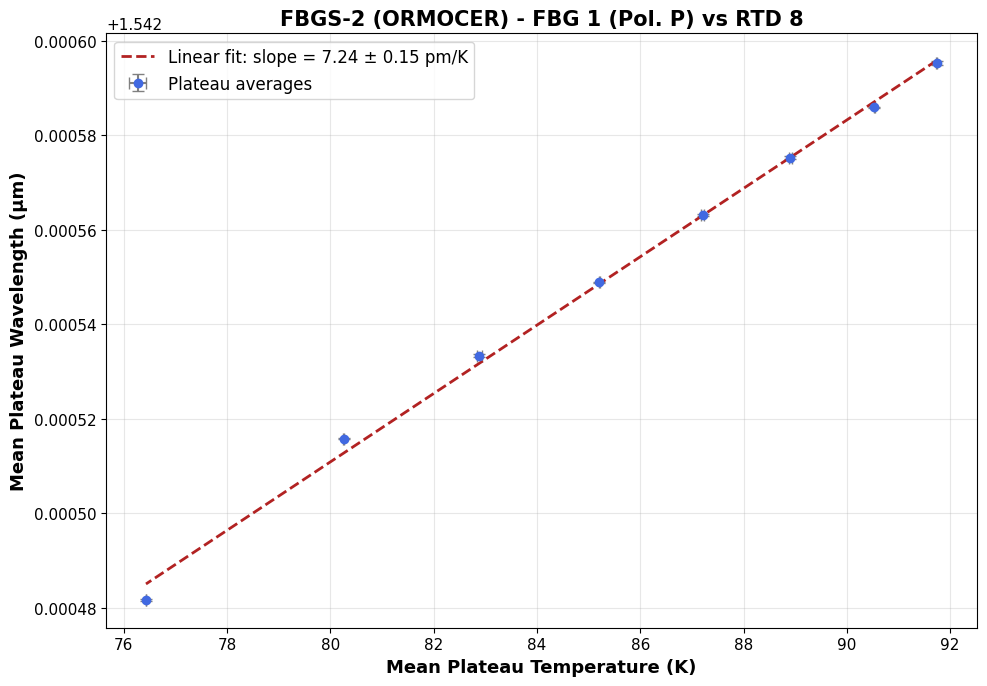


Sensitivity Analysis: RTD 8 vs FBG 1 (Pol. S)
Sensitivity:  7.1360 ± 0.1769 pm/K
R²:           0.996328
Data points:  8


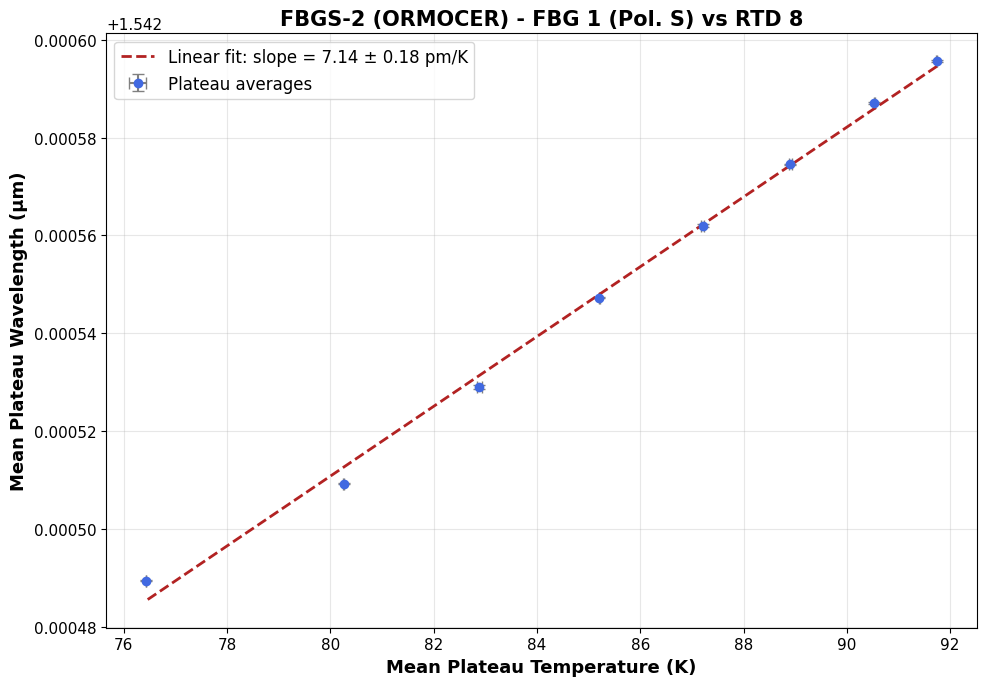


Sensitivity Analysis: RTD 8 vs FBG 2 (Pol. P)
Sensitivity:  7.4956 ± 0.2175 pm/K
R²:           0.994973
Data points:  8


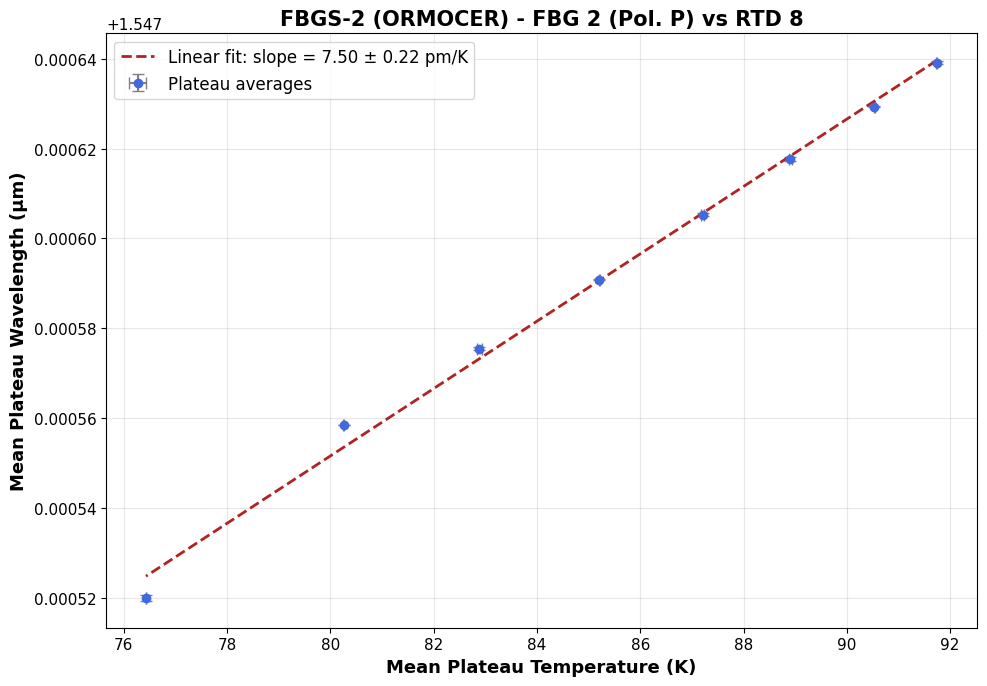


Sensitivity Analysis: RTD 8 vs FBG 2 (Pol. S)
Sensitivity:  7.0769 ± 0.2774 pm/K
R²:           0.990867
Data points:  8


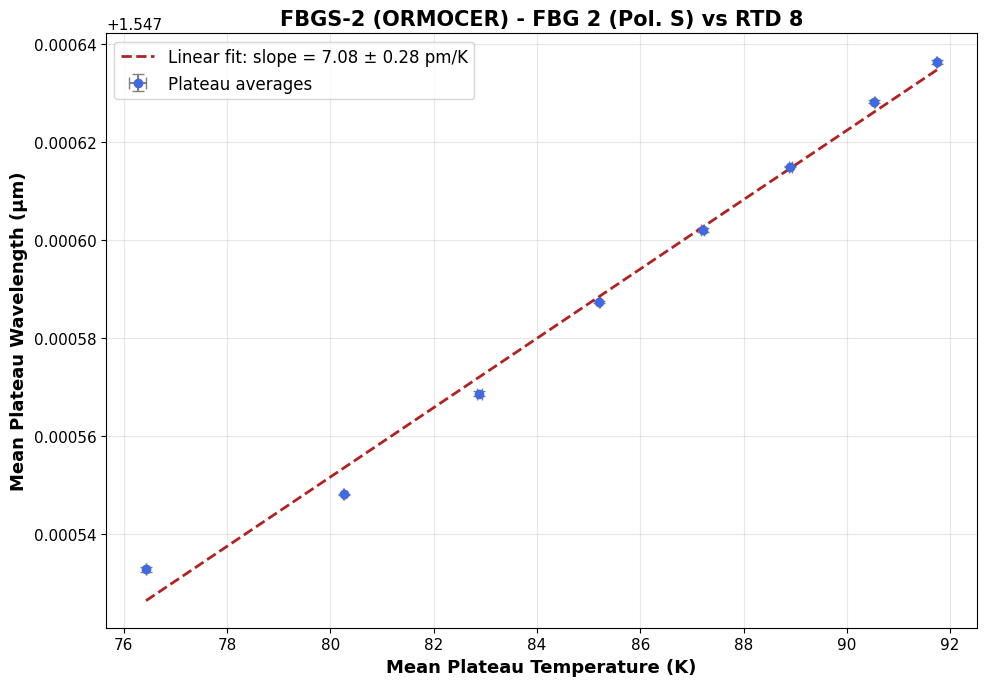


Sensitivity Analysis: RTD 8 vs FBG 3 (Pol. P)
Sensitivity:  7.6045 ± 0.2356 pm/K
R²:           0.994276
Data points:  8


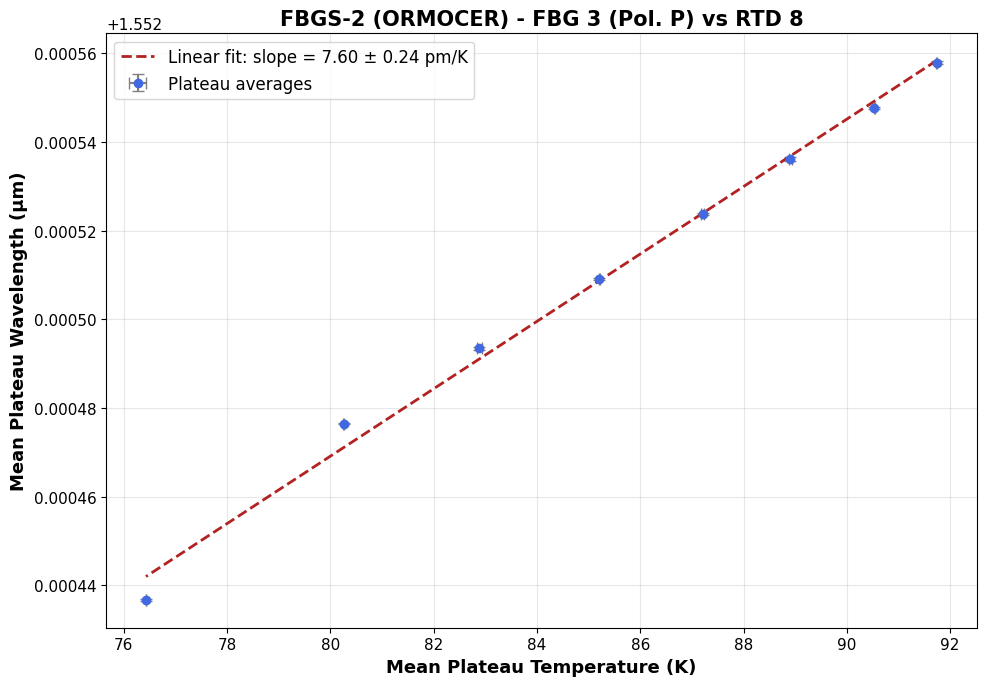


Sensitivity Analysis: RTD 8 vs FBG 3 (Pol. S)
Sensitivity:  7.3446 ± 0.2125 pm/K
R²:           0.995003
Data points:  8


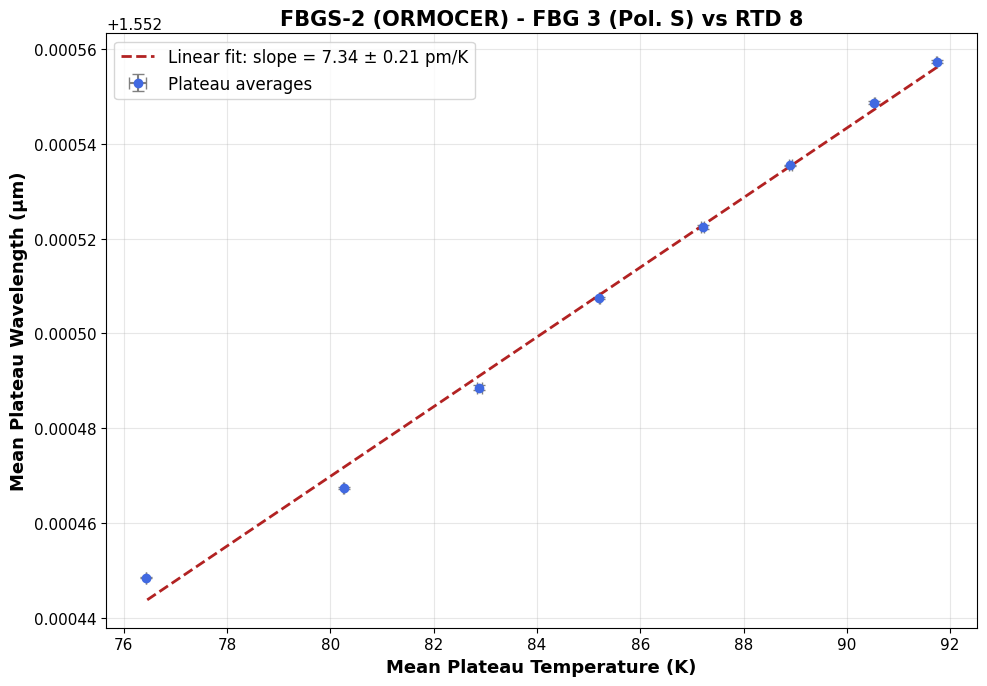


 Análisis completado: 8 combinaciones sensor-polarización

 RESULTADOS DE SENSIBILIDAD TÉRMICA

 Fibra: FBGS-2 (ORMOCER)
--------------------------------------------------------------------------------
Sensor   Pol   Sensibilidad (pm/K)       R²        
--------------------------------------------------------------------------------
S0       P        7.17 ± 0.07   pm/K       0.9995
S0       S        7.26 ± 0.10   pm/K       0.9990
S1       P        7.24 ± 0.15   pm/K       0.9976
S1       S        7.14 ± 0.18   pm/K       0.9963
S2       P        7.50 ± 0.22   pm/K       0.9950
S2       S        7.08 ± 0.28   pm/K       0.9909
S3       P        7.60 ± 0.24   pm/K       0.9943
S3       S        7.34 ± 0.21   pm/K       0.9950
--------------------------------------------------------------------------------

 RESUMEN POR FIBRA
FBGS-2 (ORMOCER)    :    7.29 ±  0.17 pm/K  (promedio de 8 medidas con R²>0.9)


In [19]:
# ============================================================================
# CELDA 31: 🔬 EJECUTAR ANÁLISIS DE SENSIBILIDAD - TODOS LOS SENSORES
# ============================================================================
# Calcula la sensibilidad térmica (pm/K) para todos los sensores y polarizaciones
# usando los plateaus detectados anteriormente

print("🔬 ANALIZANDO SENSIBILIDAD TÉRMICA DE TODOS LOS SENSORES...")
print("="*80)

# Analizar todos los sensores automáticamente
all_results = analyzer.analyze_all_sensors(
    sensor_temp=7,  # RTD 7: Inside Capsule 2
    plot=True       # Mostrar gráficos de los fits para cada sensor
)

print(f"\n Análisis completado: {len(all_results)} combinaciones sensor-polarización")

# ============================================================================
# TABLA DE RESULTADOS
# ============================================================================

print("\n" + "="*80)
print(" RESULTADOS DE SENSIBILIDAD TÉRMICA")
print("="*80)

# Separar por fibra
for fiber_name, sensor_indices in FIBER_MAP.items():
    print(f"\n Fibra: {fiber_name}")
    print("-"*80)
    print(f"{'Sensor':<8} {'Pol':<5} {'Sensibilidad (pm/K)':<25} {'R²':<10}")
    print("-"*80)
    
    for sensor_idx in sensor_indices:
        for pol_idx in [0, 1]:
            pol_label = POLARIZATION_LABELS[pol_idx]
            
            # Buscar resultado
            key = f"T7_P{pol_idx}_S{sensor_idx}"
            if key in all_results:
                result = all_results[key]
                slope = result['slope'] * 1e6  # Convert m/K to pm/K (micro-meters to pico-meters)
                slope_err = result['slope_err'] * 1e6
                r_squared = result['r_squared']
                
                print(f"S{sensor_idx:<7} {pol_label:<5} {slope:>7.2f} ± {slope_err:<6.2f} pm/K     {r_squared:>8.4f}")
            else:
                print(f"S{sensor_idx:<7} {pol_label:<5} {'N/A':<25} {'N/A':<10}")
    
    print("-"*80)

# Calcular promedios por fibra
print("\n" + "="*80)
print(" RESUMEN POR FIBRA")
print("="*80)

for fiber_name, sensor_indices in FIBER_MAP.items():
    slopes = []
    for sensor_idx in sensor_indices:
        for pol_idx in [0, 1]:
            key = f"T7_P{pol_idx}_S{sensor_idx}"
            if key in all_results and all_results[key]['r_squared'] > 0.9:
                slopes.append(all_results[key]['slope'] * 1e6)  # Convert m/K to pm/K
    
    if slopes:
        avg_slope = np.mean(slopes)
        std_slope = np.std(slopes)
        print(f"{fiber_name:20s}: {avg_slope:>7.2f} ± {std_slope:>5.2f} pm/K  (promedio de {len(slopes)} medidas con R²>0.9)")
    else:
        print(f"{fiber_name:20s}: Sin datos con R²>0.9")

print("="*80)

---

## 🔍 **Visualización de Wavelength en Rango Específico**

Esta celda permite visualizar la wavelength de un sensor específico en un rango temporal personalizado (14:00 - 14:30).

## 📈 5. Sensitivity Analysis Module

Perform linear fits to determine thermal sensitivity coefficients.

## 🎯 4. Plateau Detection Module

Detect stable plateaus in pressure, temperature, and wavelength data.

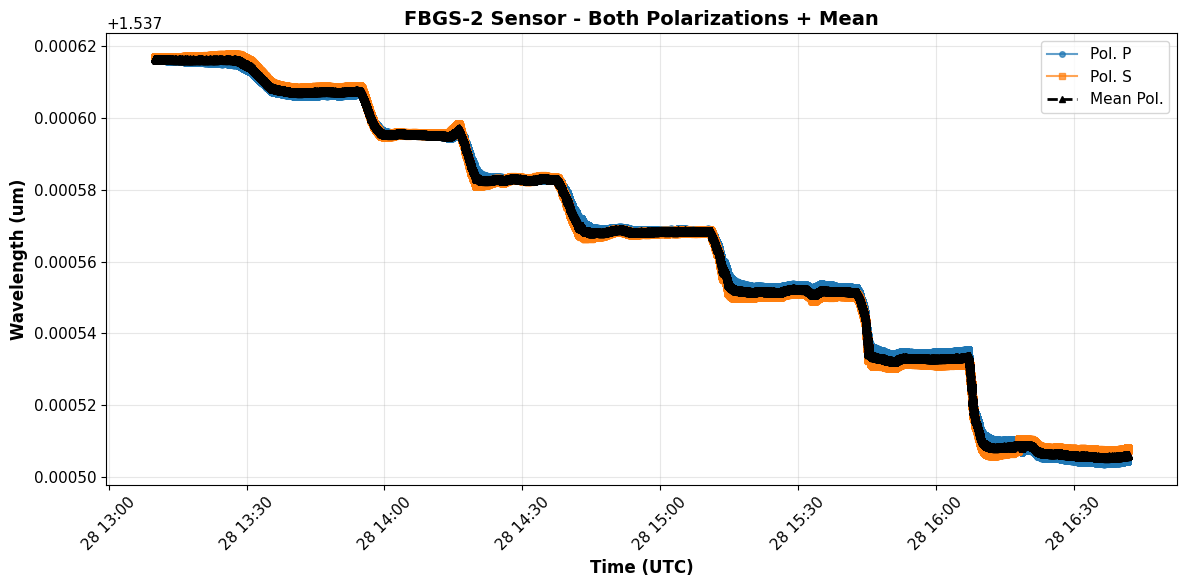

In [20]:
# Example: Plot wavelength for FBGS-2 sensor with both polarizations
viz.plot_wavelength(
    sensor_idx=0,  # FBGS-2 sensor index
    show_both_pols=True,
    show_mean=True,
    start_time=ANALYSIS_START_TIME,  # Usa la configuración global
    end_time=ANALYSIS_END_TIME,      # Usa la configuración global
    title="FBGS-2 Sensor - Both Polarizations + Mean"
)

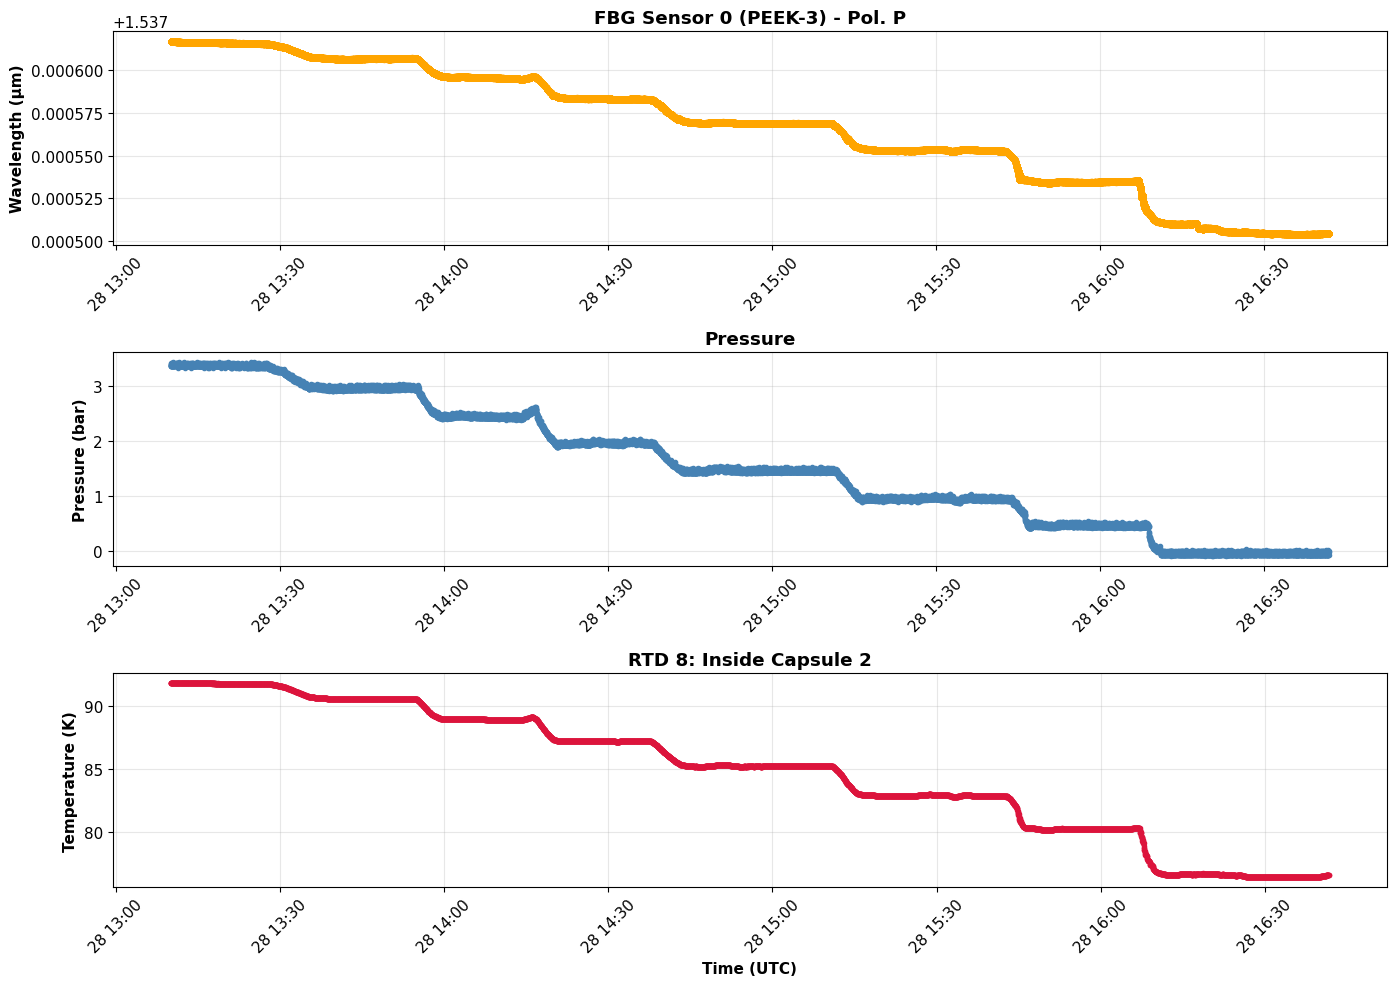

In [21]:
# ============================================================================
# EXPLORACIÓN VISUAL INICIAL
# ============================================================================
# Vista general de todos los datos (usa automáticamente ANALYSIS_START_TIME)

viz.plot_data_overview(start_time=ANALYSIS_START_TIME)

📊 FBGS-2 FIBER (ORMOCER) - THERMAL SENSITIVITY ANALYSIS (RUN 3)
   4 Sensors × 3 Polarizations (S, P, Mean) - Matrix Analysis
   Date: 2026-04-28


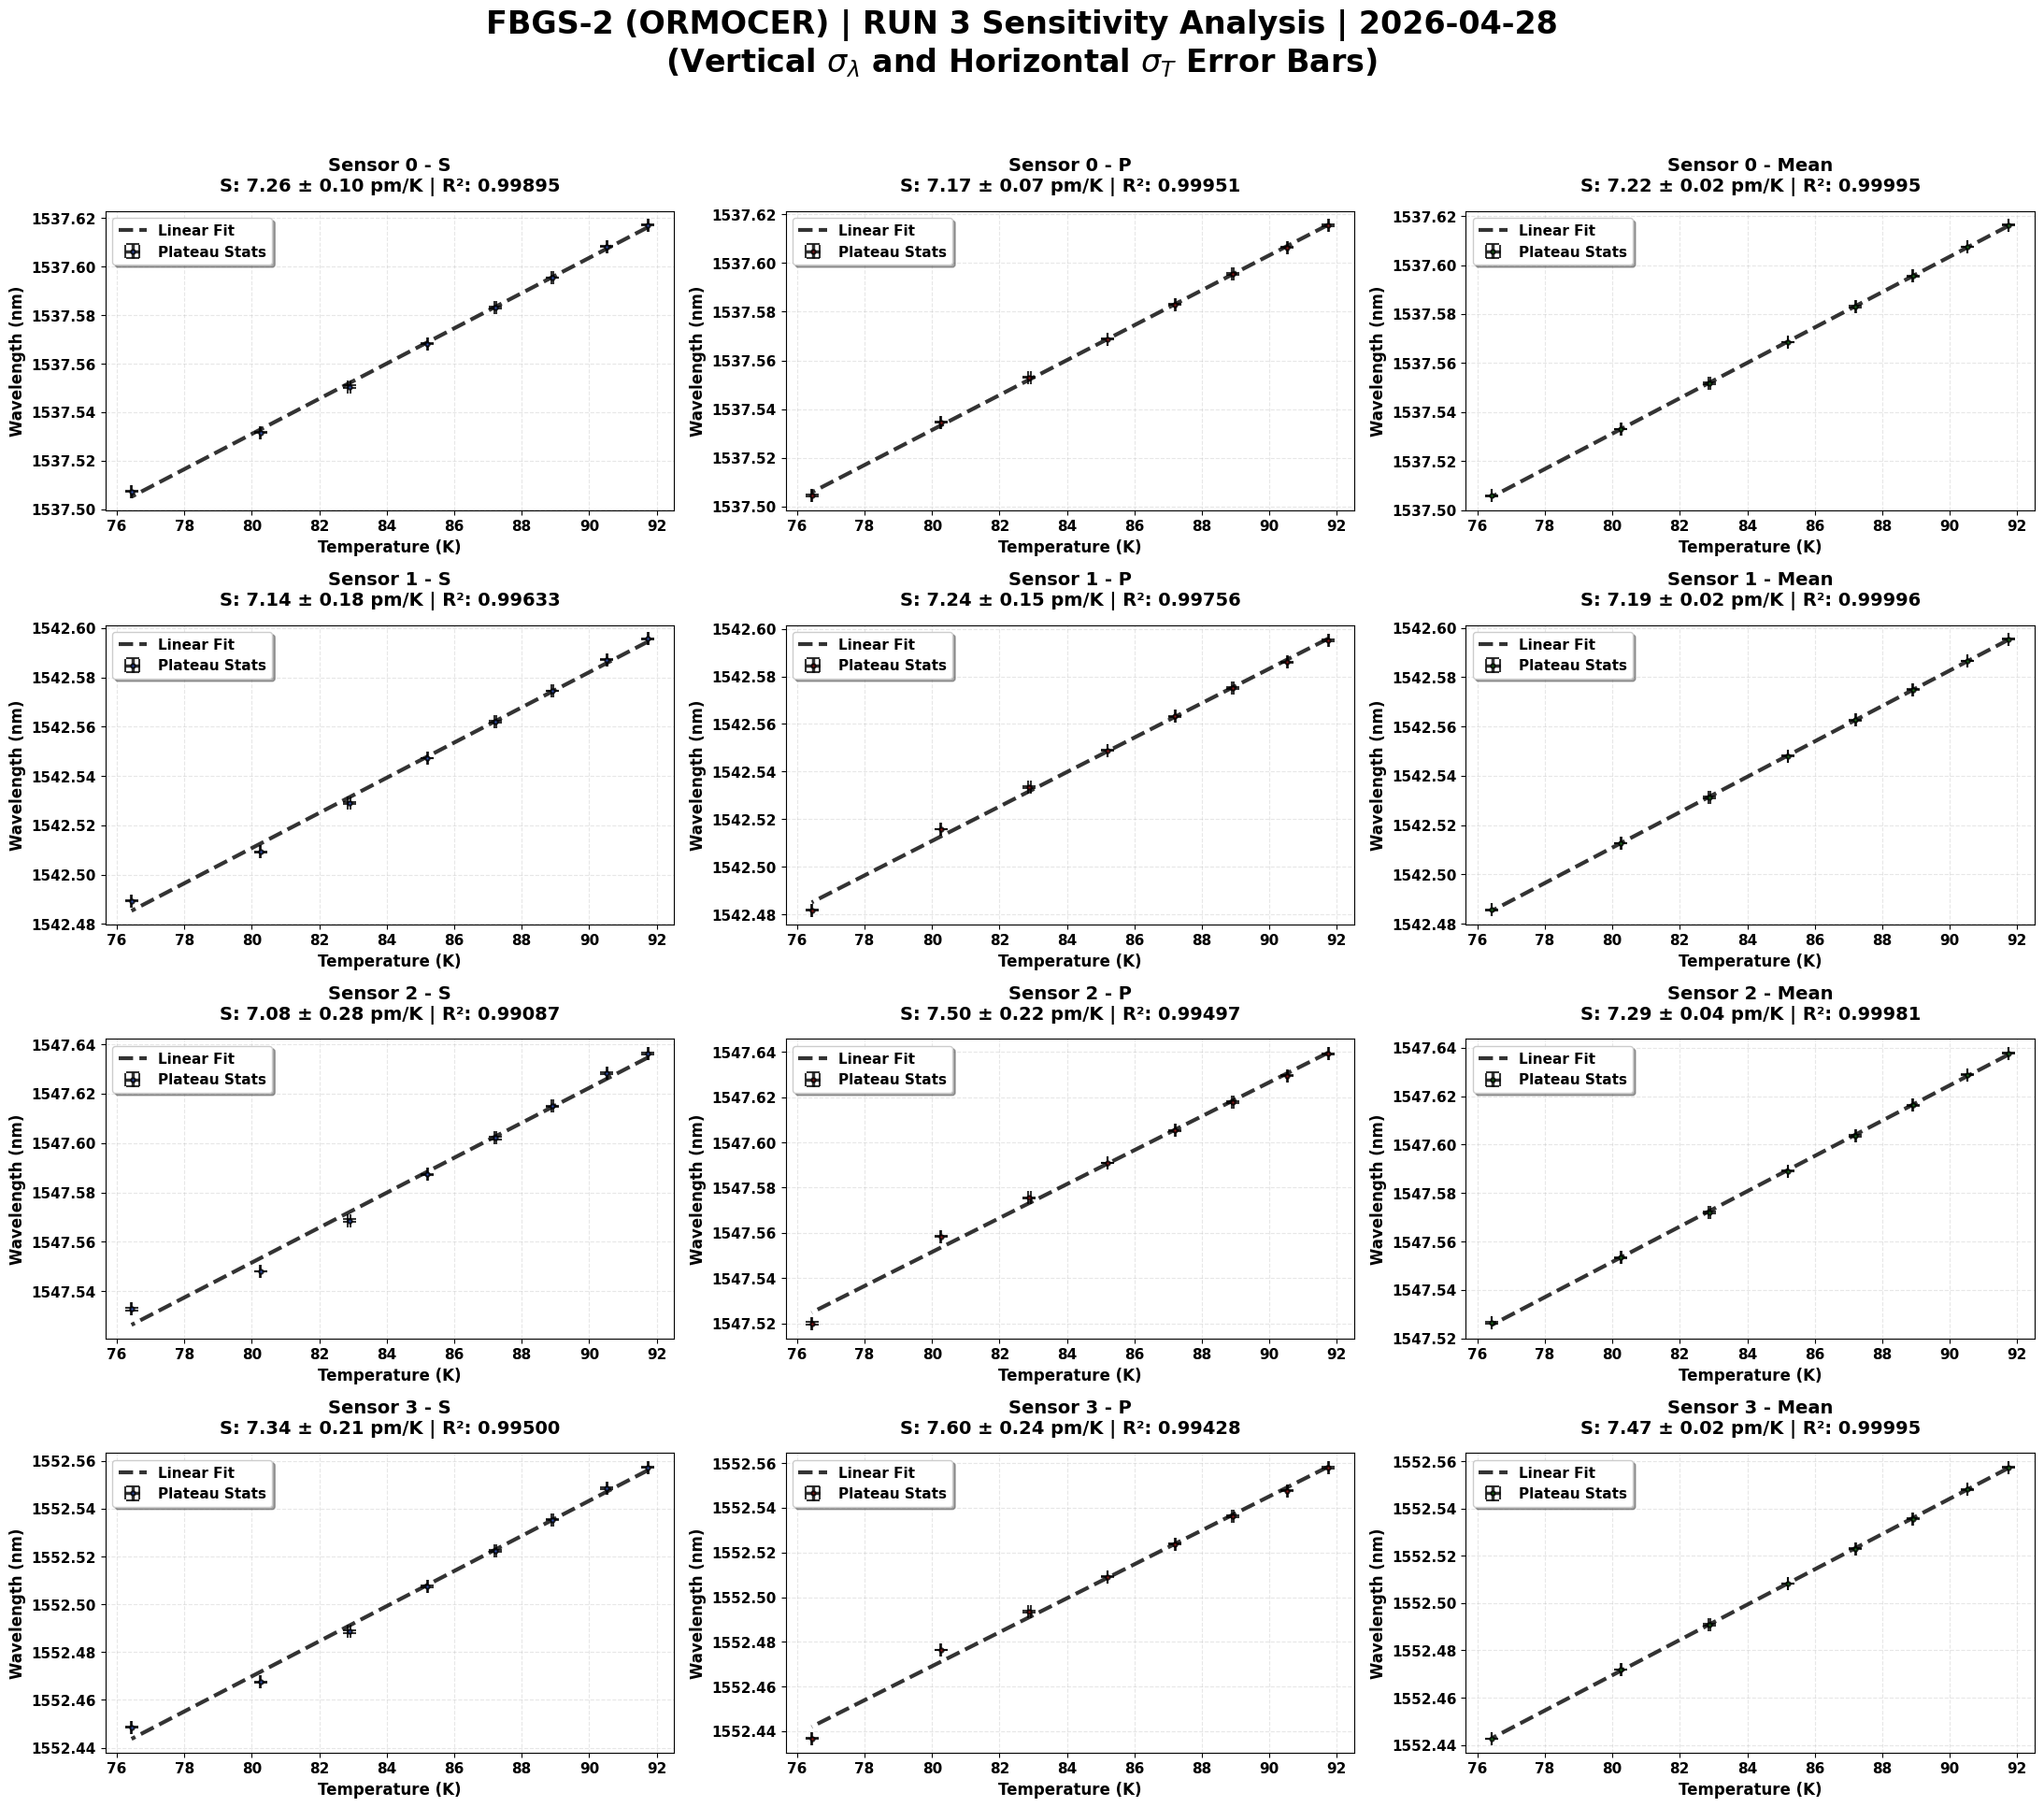


                     SENSITIVITY SUMMARY TABLE: FBGS-2 RUN 3 (2026-04-28)                      
Sensor     | Type            | Sensitivity (pm/K)        | R²        
-----------------------------------------------------------------------------------------------
Sensor 0   | S               |      7.262 ± 0.096      | 0.998952
Sensor 0   | P               |      7.175 ± 0.065      | 0.999507
Sensor 0   | Mean            |      7.218 ± 0.021      | 0.999950
-----------------------------------------------------------------------------------------------
Sensor 1   | S               |      7.136 ± 0.177      | 0.996328
Sensor 1   | P               |      7.236 ± 0.146      | 0.997559
Sensor 1   | Mean            |      7.186 ± 0.018      | 0.999963
-----------------------------------------------------------------------------------------------
Sensor 2   | S               |      7.077 ± 0.277      | 0.990867
Sensor 2   | P               |      7.496 ± 0.218      | 0.994973
Sensor 2   | Mean

In [22]:
# ============================================================================
# THERMAL SENSITIVITY FITS - 4×3 SUBPLOT GRID (RUN 3)
# FBGS-2 Fiber (ORMOCER) | 4 Sensors | Date: 28-04-2026
# ============================================================================
# Rows: Each sensor (0-3) | Columns: S, P, Mean (S+P)/2
# Error bars represent the standard deviation within each plateau.
# ============================================================================

import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Configuración de impresión inicial
print("=" * 95)
print("📊 FBGS-2 FIBER (ORMOCER) - THERMAL SENSITIVITY ANALYSIS (RUN 3)")
print("   4 Sensors × 3 Polarizations (S, P, Mean) - Matrix Analysis")
print("   Date: 2026-04-28")
print("=" * 95)

# Configuración de Sensores
SENSORS = [0, 1, 2, 3]  
SENSOR_TEMP_IDX = 7     # Reference RTD (Capsule)

# ----------------------------------------------------------------------------
# STEP 1: Funciones para extracción estadística
# ----------------------------------------------------------------------------

def extract_plateau_stats(loader, detector, pol_idx, sensor_idx, temp_sensor_idx):
    """Extrae la media y desviación estándar de cada plateau (error instrumental)"""
    temp_means, temp_stds = [], []
    wav_means, wav_stds = [], []
    
    temp_times = loader.get_temp_times()
    peak_times = loader.get_peak_times()
    
    # Usamos los plateaus detectados para esta sesión
    for p in detector.plateaus.get("common", []):
        t0 = datetime.datetime.fromtimestamp(float(p["t0"]))
        tfin = datetime.datetime.fromtimestamp(float(p["tfin"]))
        
        # Filtro de índices para la ventana temporal del plateau
        temp_idx = np.where((temp_times >= t0) & (temp_times <= tfin))[0]
        wav_idx = np.where((peak_times >= t0) & (peak_times <= tfin))[0]
        
        if len(temp_idx) > 0 and len(wav_idx) > 0:
            # Wavelength en um (se procesa internamente)
            w_vals = loader.get_wavelength(pol_idx=pol_idx, sensor_idx=sensor_idx, unit='um')[wav_idx]
            t_vals = loader.get_temperature(sensor_idx=temp_sensor_idx)[temp_idx]
            
            temp_means.append(np.mean(t_vals))
            temp_stds.append(np.std(t_vals)) # ERROR HORIZONTAL (Temp)
            wav_means.append(np.mean(w_vals))
            wav_stds.append(np.std(w_vals))  # ERROR VERTICAL (Wav)
            
    return {
        "temp_means": np.array(temp_means), "temp_stds": np.array(temp_stds),
        "wav_means": np.array(wav_means), "wav_stds": np.array(wav_stds)
    }

# ----------------------------------------------------------------------------
# STEP 2: Procesamiento de Datos (Ajustes Lineales)
# ----------------------------------------------------------------------------

all_data = {}
all_fits = {}

for s_idx in SENSORS:
    # 1. Extraer S y P de forma independiente
    data_s = extract_plateau_stats(loader, detector, 1, s_idx, SENSOR_TEMP_IDX)
    data_p = extract_plateau_stats(loader, detector, 0, s_idx, SENSOR_TEMP_IDX)
    
    # 2. Calcular estadísticas de la MEDIA (Propagación de errores)
    data_mean = {
        "temp_means": (data_s["temp_means"] + data_p["temp_means"]) / 2,
        "temp_stds": np.sqrt(data_s["temp_stds"]**2 + data_p["temp_stds"]**2) / 2,
        "wav_means": (data_s["wav_means"] + data_p["wav_means"]) / 2,
        "wav_stds": np.sqrt(data_s["wav_stds"]**2 + data_p["wav_stds"]**2) / 2
    }
    
    all_data[s_idx] = {"S": data_s, "P": data_p, "Mean": data_mean}
    
    # 3. Ajustes lineales (Fits)
    for key in ["S", "P", "Mean"]:
        d = all_data[s_idx][key]
        if len(d["temp_means"]) > 1:
            slope, intercept, r_val, p_val, std_err = linregress(d["temp_means"], d["wav_means"])
            all_fits.setdefault(s_idx, {})[key] = {
                "slope": slope, "slope_err": std_err, "r2": r_val**2, "intercept": intercept
            }

# ----------------------------------------------------------------------------
# STEP 3: Matrix Plot (Grid 4x3) de alta visibilidad para Slides
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(4, 3, figsize=(22, 20))
pols = ["S", "P", "Mean"]
colors = {"S": "royalblue", "P": "firebrick", "Mean": "forestgreen"}

for row, s_idx in enumerate(SENSORS):
    for col, p_name in enumerate(pols):
        ax = axes[row, col]
        d = all_data[s_idx][p_name]
        f = all_fits[s_idx].get(p_name)
        
        if f:
            # Barras de error instrumental
            ax.errorbar(d["temp_means"], d["wav_means"]*1000, 
                        xerr=d["temp_stds"], yerr=d["wav_stds"]*1000, 
                        fmt='o', markersize=3, markeredgecolor='black', markeredgewidth=1.5,
                        color=colors[p_name], ecolor='black', elinewidth=2.5, capsize=5, alpha=0.8, label='Plateau Stats')
            
            # Línea de Ajuste (Regresión)
            ax.plot(d["temp_means"], (f["slope"]*d["temp_means"] + f["intercept"])*1000, 
                    'k--', linewidth=3, alpha=0.8, label='Linear Fit')
            
            # Títulos con PM/K
            ax.set_title(f"Sensor {s_idx} - {p_name}\nS: {f['slope']*1e6:.2f} ± {f['slope_err']*1e6:.2f} pm/K | R²: {f['r2']:.5f}", 
                         fontweight='bold', fontsize=14, pad=15)
            
            ax.set_xlabel("Temperature (K)", fontsize=12, fontweight='bold')
            ax.set_ylabel("Wavelength (nm)", fontsize=12, fontweight='bold')
            
            # Formato de ejes
            ax.tick_params(axis='both', labelsize=11)
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                lbl.set_fontweight('bold')
                
            ax.grid(True, alpha=0.3, linestyle='--')
            leg = ax.legend(fontsize=11, fancybox=True, shadow=True)
            for text in leg.get_texts():
                text.set_fontweight('bold')
            ax.ticklabel_format(useOffset=False, axis='y')

plt.suptitle(r'FBGS-2 (ORMOCER) | RUN 3 Sensitivity Analysis | 2026-04-28' + '\n' +
             r'(Vertical $\sigma_{\lambda}$ and Horizontal $\sigma_{T}$ Error Bars)', 
             fontsize=24, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# ----------------------------------------------------------------------------
# STEP 4: Tabla Resumen Final
# ----------------------------------------------------------------------------
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FBGS-2 RUN 3 (2026-04-28)':^95}")
print("="*95)
print(f"{'Sensor':<10} | {'Type':<15} | {'Sensitivity (pm/K)':<25} | {'R²':<10}")
print("-" * 95)

for s in SENSORS:
    for p in pols:
        f = all_fits[s].get(p)
        if f:
            print(f"Sensor {s:<3} | {p:<15} | {f['slope']*1e6:>10.3f} ± {f['slope_err']*1e6:<10.3f} | {f['r2']:.6f}")
    print("-" * 95)
print("=" * 95)

📊 FBGS-2 FIBER (ORMOCER) - THERMAL SENSITIVITY ANALYSIS (RUN 3)
   4 Sensors × 3 Polarizations (S, P, Mean) - Matrix Analysis
   Date: 2026-04-28


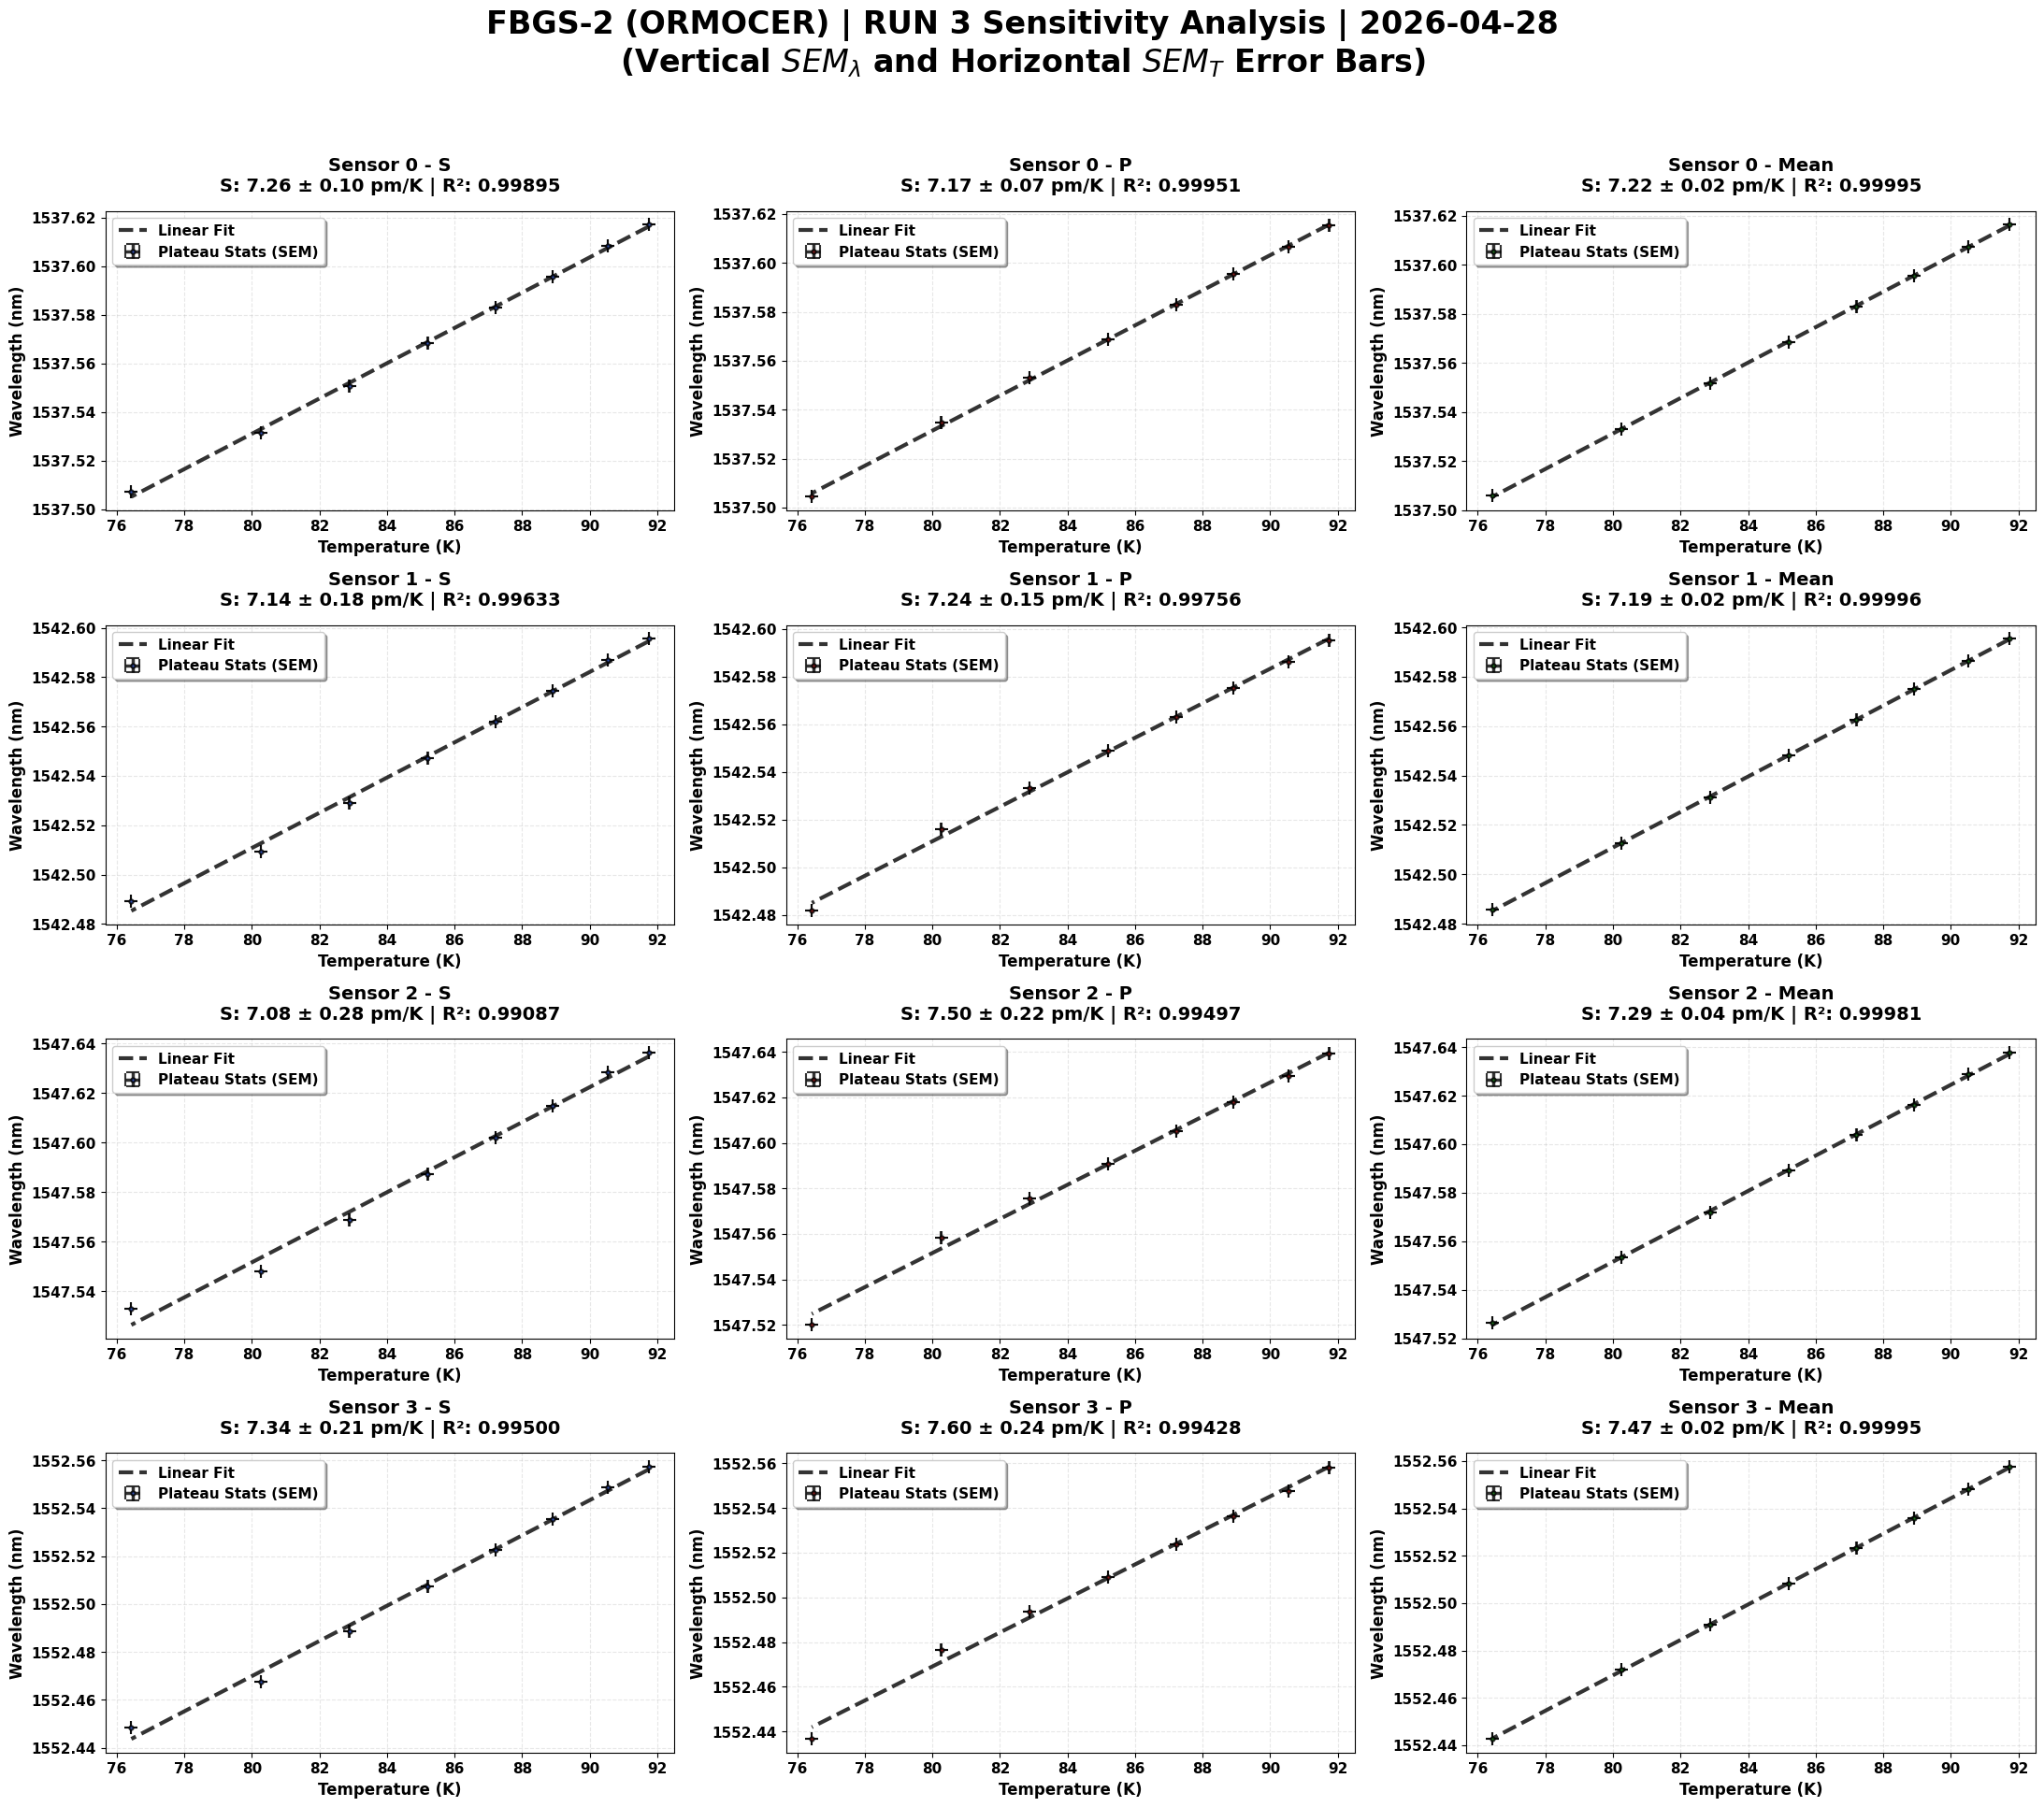


                     SENSITIVITY SUMMARY TABLE: FBGS-2 RUN 3 (2026-04-28)                      
Sensor     | Type            | Sensitivity (pm/K)        | R²        
-----------------------------------------------------------------------------------------------
Sensor 0   | S               |      7.262 ± 0.096      | 0.998952
Sensor 0   | P               |      7.175 ± 0.065      | 0.999507
Sensor 0   | Mean            |      7.218 ± 0.021      | 0.999950
-----------------------------------------------------------------------------------------------
Sensor 1   | S               |      7.136 ± 0.177      | 0.996328
Sensor 1   | P               |      7.236 ± 0.146      | 0.997559
Sensor 1   | Mean            |      7.186 ± 0.018      | 0.999963
-----------------------------------------------------------------------------------------------
Sensor 2   | S               |      7.077 ± 0.277      | 0.990867
Sensor 2   | P               |      7.496 ± 0.218      | 0.994973
Sensor 2   | Mean

In [28]:
# ============================================================================
# THERMAL SENSITIVITY FITS - 4×3 SUBPLOT GRID (RUN 3)
# FBGS-2 Fiber (ORMOCER) | 4 Sensors | Date: 28-04-2026
# ============================================================================
# Rows: Each sensor (0-3) | Columns: S, P, Mean (S+P)/2
# Error bars represent the Standard Error of the Mean (SEM) within each plateau.
# ============================================================================

import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Configuración de impresión inicial
print("=" * 95)
print("📊 FBGS-2 FIBER (ORMOCER) - THERMAL SENSITIVITY ANALYSIS (RUN 3)")
print("   4 Sensors × 3 Polarizations (S, P, Mean) - Matrix Analysis")
print("   Date: 2026-04-28")
print("=" * 95)

# Configuración de Sensores
SENSORS = [0, 1, 2, 3]  
SENSOR_TEMP_IDX = 7     # Reference RTD (Capsule)

# ----------------------------------------------------------------------------
# STEP 1: Funciones para extracción estadística
# ----------------------------------------------------------------------------

def extract_plateau_stats(loader, detector, pol_idx, sensor_idx, temp_sensor_idx):
    """Extrae la media y SEM (Standard Error of the Mean) de cada plateau (error instrumental)"""
    temp_means, temp_stds = [], []
    wav_means, wav_stds = [], []
    
    temp_times = loader.get_temp_times()
    peak_times = loader.get_peak_times()
    
    # Usamos los plateaus detectados para esta sesión
    for p in detector.plateaus.get("common", []):
        t0 = datetime.datetime.fromtimestamp(float(p["t0"]))
        tfin = datetime.datetime.fromtimestamp(float(p["tfin"]))
        
        # Filtro de índices para la ventana temporal del plateau
        temp_idx = np.where((temp_times >= t0) & (temp_times <= tfin))[0]
        wav_idx = np.where((peak_times >= t0) & (peak_times <= tfin))[0]
        
        if len(temp_idx) > 0 and len(wav_idx) > 0:
            # Wavelength en um (se procesa internamente)
            w_vals = loader.get_wavelength(pol_idx=pol_idx, sensor_idx=sensor_idx, unit='um')[wav_idx]
            t_vals = loader.get_temperature(sensor_idx=temp_sensor_idx)[temp_idx]
            
            temp_means.append(np.mean(t_vals))
            temp_stds.append(np.std(t_vals) / np.sqrt(len(t_vals))) # ERROR HORIZONTAL (Temp) - SEM
            wav_means.append(np.mean(w_vals))
            wav_stds.append(np.std(w_vals) / np.sqrt(len(w_vals)))  # ERROR VERTICAL (Wav) - SEM
            
    return {
        "temp_means": np.array(temp_means), "temp_stds": np.array(temp_stds),
        "wav_means": np.array(wav_means), "wav_stds": np.array(wav_stds)
    }

# ----------------------------------------------------------------------------
# STEP 2: Procesamiento de Datos (Ajustes Lineales)
# ----------------------------------------------------------------------------

all_data = {}
all_fits = {}

for s_idx in SENSORS:
    # 1. Extraer S y P de forma independiente
    data_s = extract_plateau_stats(loader, detector, 1, s_idx, SENSOR_TEMP_IDX)
    data_p = extract_plateau_stats(loader, detector, 0, s_idx, SENSOR_TEMP_IDX)
    
    # 2. Calcular estadísticas de la MEDIA (Propagación de errores)
    data_mean = {
        "temp_means": (data_s["temp_means"] + data_p["temp_means"]) / 2,
        "temp_stds": np.sqrt(data_s["temp_stds"]**2 + data_p["temp_stds"]**2) / 2,
        "wav_means": (data_s["wav_means"] + data_p["wav_means"]) / 2,
        "wav_stds": np.sqrt(data_s["wav_stds"]**2 + data_p["wav_stds"]**2) / 2
    }
    
    all_data[s_idx] = {"S": data_s, "P": data_p, "Mean": data_mean}
    
    # 3. Ajustes lineales (Fits)
    for key in ["S", "P", "Mean"]:
        d = all_data[s_idx][key]
        if len(d["temp_means"]) > 1:
            slope, intercept, r_val, p_val, std_err = linregress(d["temp_means"], d["wav_means"])
            all_fits.setdefault(s_idx, {})[key] = {
                "slope": slope, "slope_err": std_err, "r2": r_val**2, "intercept": intercept
            }

# ----------------------------------------------------------------------------
# STEP 3: Matrix Plot (Grid 4x3) de alta visibilidad para Slides
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(4, 3, figsize=(22, 20))
pols = ["S", "P", "Mean"]
colors = {"S": "royalblue", "P": "firebrick", "Mean": "forestgreen"}

for row, s_idx in enumerate(SENSORS):
    for col, p_name in enumerate(pols):
        ax = axes[row, col]
        d = all_data[s_idx][p_name]
        f = all_fits[s_idx].get(p_name)
        
        if f:
            # Barras de error instrumental
            ax.errorbar(d["temp_means"], d["wav_means"]*1000, 
                        xerr=d["temp_stds"], yerr=d["wav_stds"]*1000, 
                        fmt='o', markersize=3, markeredgecolor='black', markeredgewidth=1.5,
                        color=colors[p_name], ecolor='black', elinewidth=2.5, capsize=5, alpha=0.8, label='Plateau Stats (SEM)')
            
            # Línea de Ajuste (Regresión)
            ax.plot(d["temp_means"], (f["slope"]*d["temp_means"] + f["intercept"])*1000, 
                    'k--', linewidth=3, alpha=0.8, label='Linear Fit')
            
            # Títulos con PM/K
            ax.set_title(f"Sensor {s_idx} - {p_name}\nS: {f['slope']*1e6:.2f} ± {f['slope_err']*1e6:.2f} pm/K | R²: {f['r2']:.5f}", 
                         fontweight='bold', fontsize=14, pad=15)
            
            ax.set_xlabel("Temperature (K)", fontsize=12, fontweight='bold')
            ax.set_ylabel("Wavelength (nm)", fontsize=12, fontweight='bold')
            
            # Formato de ejes
            ax.tick_params(axis='both', labelsize=11)
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                lbl.set_fontweight('bold')
                
            ax.grid(True, alpha=0.3, linestyle='--')
            leg = ax.legend(fontsize=11, fancybox=True, shadow=True)
            for text in leg.get_texts():
                text.set_fontweight('bold')
            ax.ticklabel_format(useOffset=False, axis='y')

plt.suptitle(r'FBGS-2 (ORMOCER) | RUN 3 Sensitivity Analysis | 2026-04-28' + '\n' +
             r'(Vertical $SEM_{\lambda}$ and Horizontal $SEM_{T}$ Error Bars)', 
             fontsize=24, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# ----------------------------------------------------------------------------
# STEP 4: Tabla Resumen Final
# ----------------------------------------------------------------------------
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: FBGS-2 RUN 3 (2026-04-28)':^95}")
print("="*95)
print(f"{'Sensor':<10} | {'Type':<15} | {'Sensitivity (pm/K)':<25} | {'R²':<10}")
print("-" * 95)

for s in SENSORS:
    for p in pols:
        f = all_fits[s].get(p)
        if f:
            print(f"Sensor {s:<3} | {p:<15} | {f['slope']*1e6:>10.3f} ± {f['slope_err']*1e6:<10.3f} | {f['r2']:.6f}")
    print("-" * 95)
print("=" * 95)

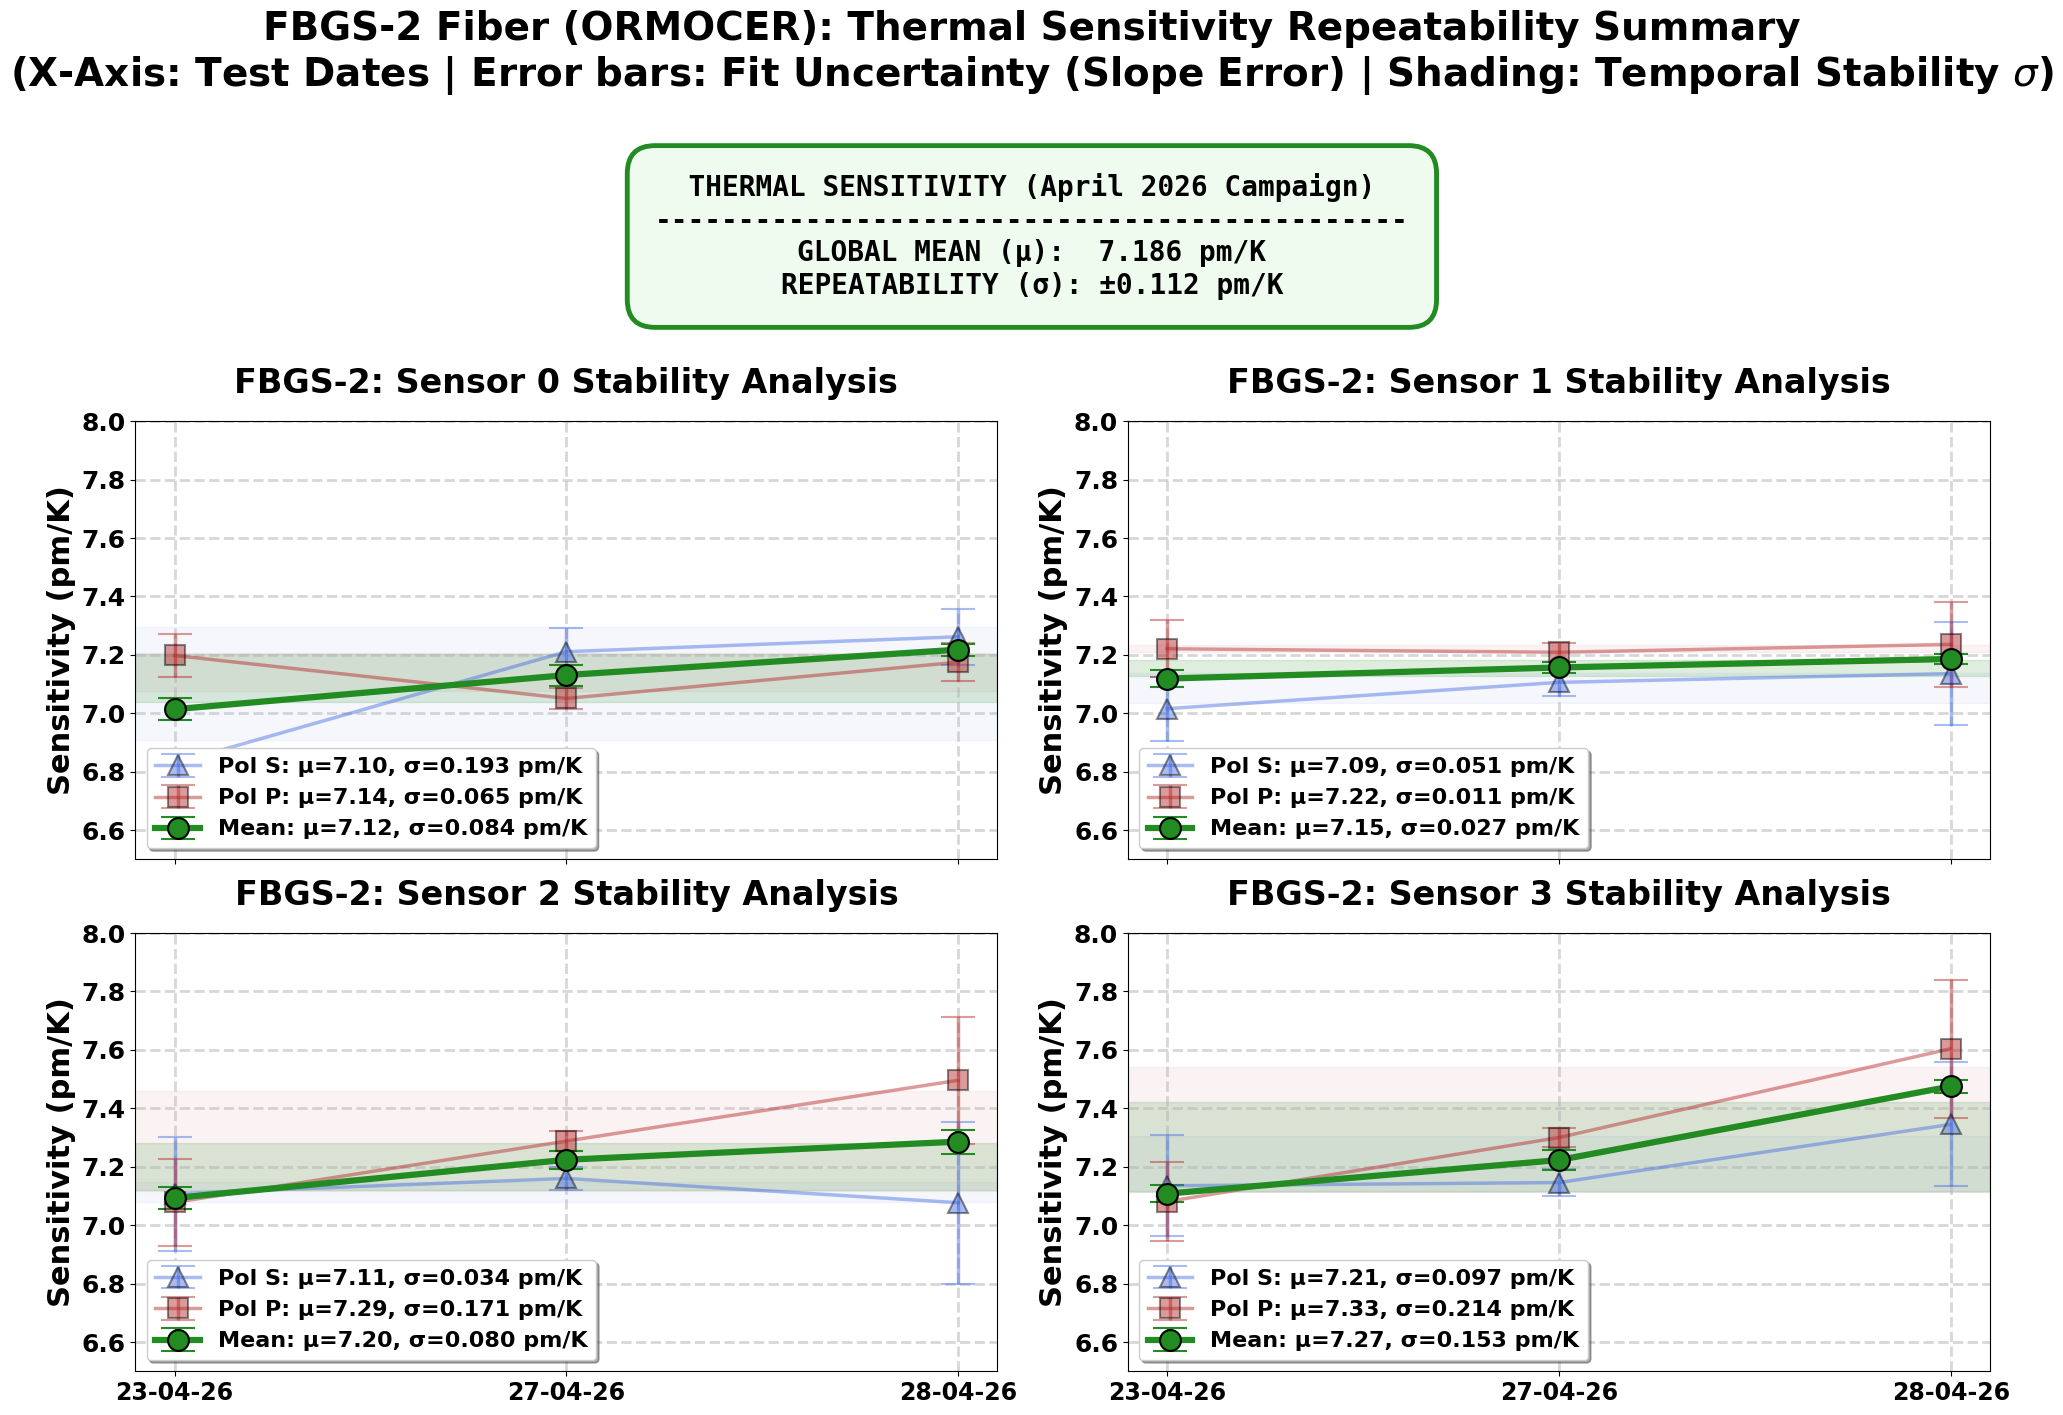

In [2]:
# ============================================================================
# FBGS-2 REPEATABILITY ANALYSIS: HIGH VISIBILITY WITH GLOBAL KPI FOR SLIDES
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA SETUP - Strictly 3 runs from April 2026
dates = ["23-04-26", "27-04-26", "28-04-26"]
x = np.arange(len(dates))

# Datos actualizados con RUN 1, RUN 2 y RUN 3 completos (Índices: [Run 1, Run 2, Run 3])
fbgs2_data = {
    "Sensor 0": {
        "Pol S": {"v": [6.829, 7.211, 7.262], "e": [0.039, 0.082, 0.096]},
        "Pol P": {"v": [7.198, 7.051, 7.175], "e": [0.074, 0.037, 0.065]},
        "Mean":  {"v": [7.014, 7.131, 7.218], "e": [0.037, 0.036, 0.021]}
    },
    "Sensor 1": {
        "Pol S": {"v": [7.016, 7.106, 7.136], "e": [0.110, 0.046, 0.177]},
        "Pol P": {"v": [7.221, 7.209, 7.236], "e": [0.097, 0.033, 0.146]},
        "Mean":  {"v": [7.119, 7.157, 7.186], "e": [0.029, 0.019, 0.018]}
    },
    "Sensor 2": {
        "Pol S": {"v": [7.108, 7.160, 7.077], "e": [0.195, 0.038, 0.277]},
        "Pol P": {"v": [7.078, 7.288, 7.496], "e": [0.150, 0.035, 0.218]},
        "Mean":  {"v": [7.093, 7.224, 7.286], "e": [0.037, 0.030, 0.041]}
    },
    "Sensor 3": {
        "Pol S": {"v": [7.135, 7.146, 7.345], "e": [0.173, 0.045, 0.212]},
        "Pol P": {"v": [7.081, 7.300, 7.604], "e": [0.135, 0.033, 0.236]},
        "Mean":  {"v": [7.108, 7.223, 7.475], "e": [0.028, 0.034, 0.021]}
    }
}

# ----------------------------------------------------------------------------
# CÁLCULO AUTOMÁTICO DE MEDIA GLOBAL
# ----------------------------------------------------------------------------
all_means = []
for s_name, pols in fbgs2_data.items():
    all_means.extend(pols["Mean"]["v"])

global_mu = np.mean(all_means)
global_sigma = np.std(all_means)

# 2. PLOT CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=True)
axes = axes.flatten()

styles = {
    "Pol S": {"color": "royalblue", "marker": "^", "alpha": 0.45},
    "Pol P": {"color": "firebrick", "marker": "s", "alpha": 0.45},
    "Mean":  {"color": "forestgreen", "marker": "o", "alpha": 1.0}
}

# 3. LOOP THROUGH SENSORS
for i, (s_name, pols) in enumerate(fbgs2_data.items()):
    ax = axes[i]
    
    for p_name, data in pols.items():
        v = np.array(data["v"])
        e = np.array(data["e"])
        
        mu = np.mean(v)
        sigma = np.std(v)
        
        style = styles[p_name]
        label = f'{p_name}: μ={mu:.2f}, σ={sigma:.3f} pm/K'
        
        ax.errorbar(x, v, yerr=e, fmt=style["marker"] + '-', color=style["color"],
                    capsize=12, markersize=15, linewidth=4.5 if p_name=="Mean" else 2.5,
                    alpha=style["alpha"], label=label, markeredgecolor='black', markeredgewidth=1.5)
        
        ax.axhspan(mu - sigma, mu + sigma, color=style["color"], 
                   alpha=0.15 if p_name == "Mean" else 0.05)

    ax.set_title(f'FBGS-2: {s_name} Stability Analysis', fontsize=24, fontweight='bold', pad=20)
    ax.set_ylabel('Sensitivity (pm/K)', fontsize=22, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(dates, fontsize=17, fontweight='bold')
    
    for tick in ax.get_yticklabels():
        tick.set_fontsize(18)
        tick.set_fontweight('bold')

    ax.grid(True, linestyle='--', alpha=0.5, linewidth=2)
    
    leg = ax.legend(fontsize=16, loc='lower left', frameon=True, shadow=True, framealpha=1.0)
    plt.setp(leg.get_texts(), fontweight='bold') 
    
    ax.set_ylim(6.5, 8.0)

# ----------------------------------------------------------------------------
# CUADRO DE TEXTO GLOBAL (KPI BOX)
# ----------------------------------------------------------------------------
kpi_text = (
    f"  THERMAL SENSITIVITY (April 2026 Campaign)  \n"
    f"---------------------------------------------\n"
    f"GLOBAL MEAN (μ):  {global_mu:.3f} pm/K\n"
    f"REPEATABILITY (σ): ±{global_sigma:.3f} pm/K"
)

t = fig.text(0.5, 0.819, kpi_text, fontsize=20, fontweight='bold', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=1.0', facecolor='#F0FBF0', edgecolor='forestgreen', 
                      linewidth=3.5),
             ha='center', va='center', zorder=10)

# TÍTULO GLOBAL AJUSTADO
plt.suptitle('FBGS-2 Fiber (ORMOCER): Thermal Sensitivity Repeatability Summary\n' +
             r'(X-Axis: Test Dates | Error bars: Fit Uncertainty (Slope Error) | Shading: Temporal Stability $\sigma$)', 
             fontsize=28, fontweight='bold', y=0.97)

plt.tight_layout(rect=[0, 0.03, 1, 0.81])
plt.show()

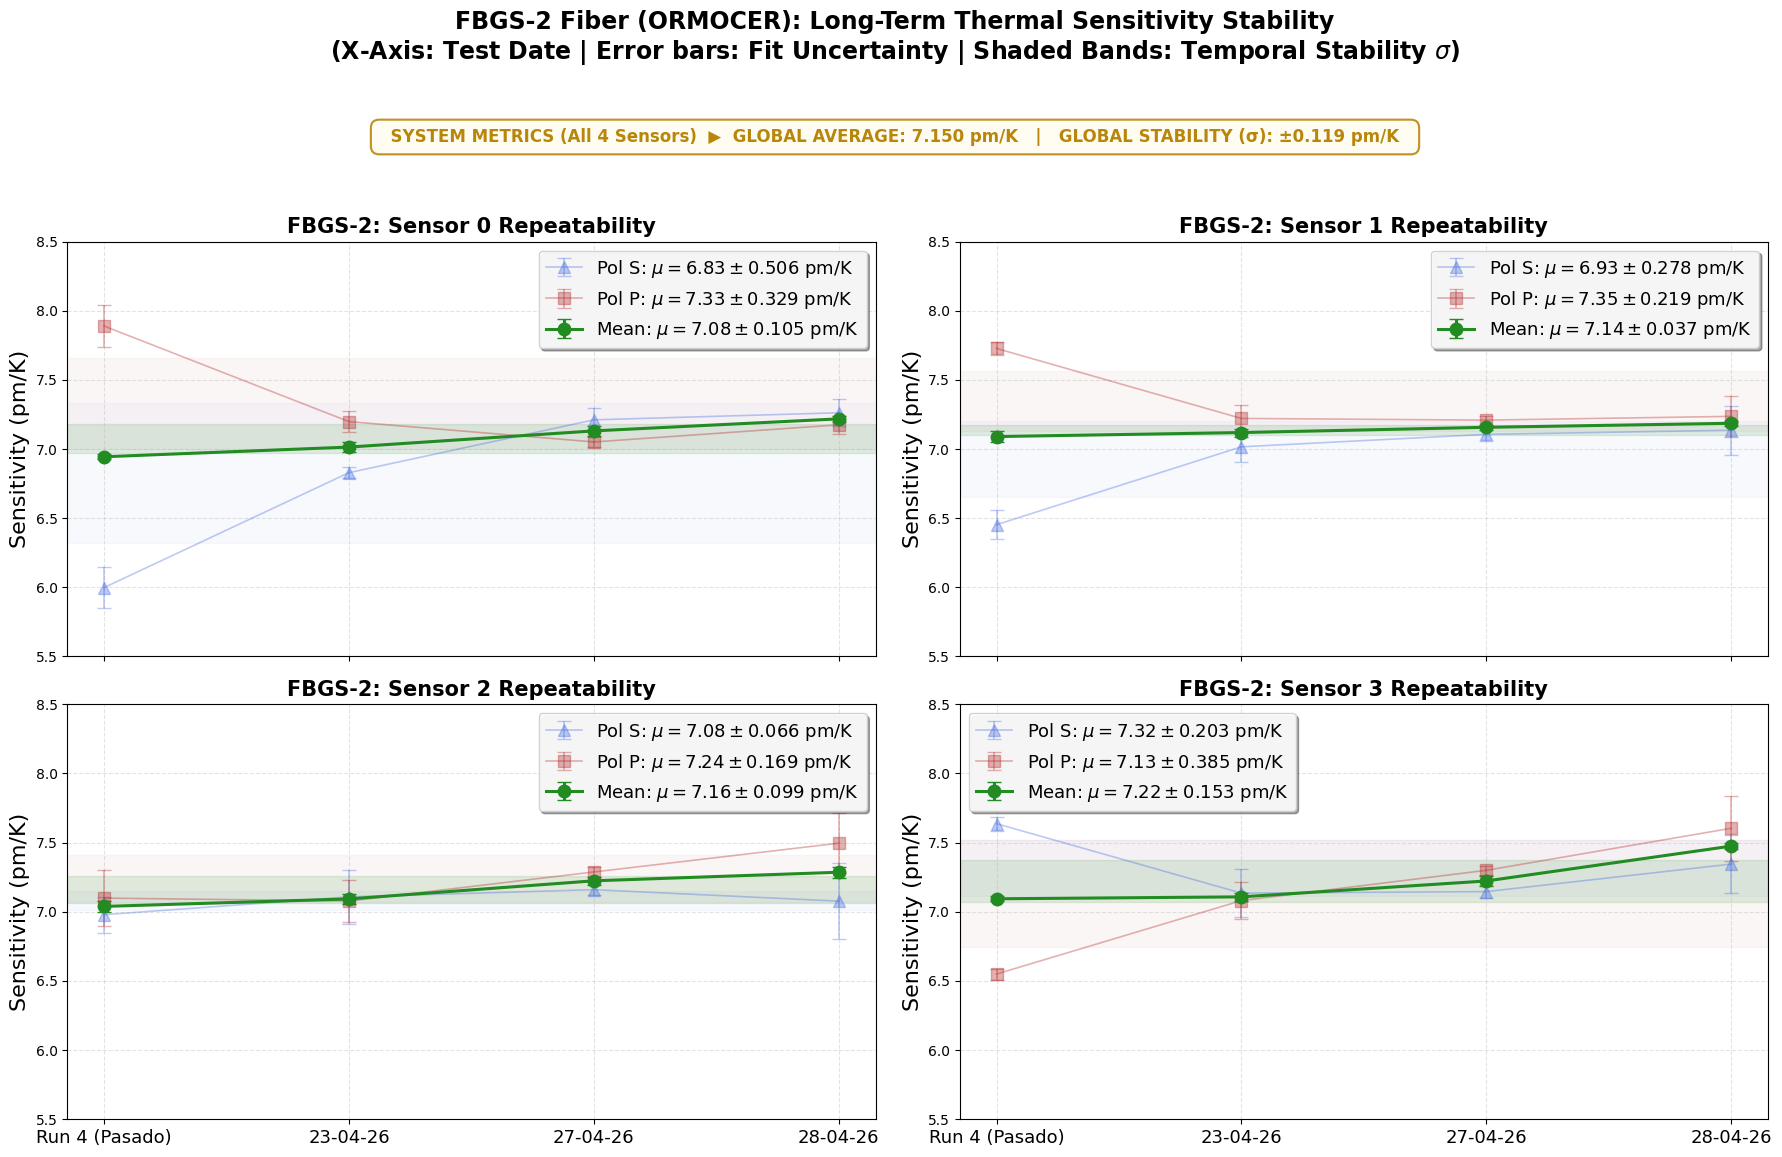

In [9]:
# ============================================================================
# FBGS-2 REPEATABILITY ANALYSIS: 4 SENSORS | CHRONOLOGICAL X-AXIS (UPDATED)
# Features: Legend Stats (μ ± σ), Shaded Stability Bands, and Fit Errors
# Includes: Global System Metrics Box (Average & STD)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de Fechas (Eje X) - Ordenado Cronológicamente
run_dates = ["Run 4 (Pasado)", "23-04-26", "27-04-26", "28-04-26"]
x = np.arange(len(run_dates))

# Diccionario de datos FBGS-2 (ORMOCER) - Índices: [Run 4, Run 1, Run 2, Run 3]
fbgs2_data = {
    "Sensor 0": {
        "Pol S": {"v": [5.998, 6.829, 7.211, 7.262], "e": [0.150, 0.039, 0.082, 0.096]},
        "Pol P": {"v": [7.889, 7.198, 7.051, 7.175], "e": [0.151, 0.074, 0.037, 0.065]},
        "Mean":  {"v": [6.944, 7.014, 7.131, 7.218], "e": [0.019, 0.037, 0.036, 0.021]}
    },
    "Sensor 1": {
        "Pol S": {"v": [6.453, 7.016, 7.106, 7.136], "e": [0.103, 0.110, 0.046, 0.177]},
        "Pol P": {"v": [7.727, 7.221, 7.209, 7.236], "e": [0.048, 0.097, 0.033, 0.146]},
        "Mean":  {"v": [7.090, 7.119, 7.157, 7.186], "e": [0.041, 0.029, 0.019, 0.018]}
    },
    "Sensor 2": {
        "Pol S": {"v": [6.979, 7.108, 7.160, 7.077], "e": [0.130, 0.195, 0.038, 0.277]},
        "Pol P": {"v": [7.099, 7.078, 7.288, 7.496], "e": [0.204, 0.150, 0.035, 0.218]},
        "Mean":  {"v": [7.039, 7.093, 7.224, 7.286], "e": [0.042, 0.037, 0.030, 0.041]}
    },
    "Sensor 3": {
        "Pol S": {"v": [7.637, 7.135, 7.146, 7.345], "e": [0.050, 0.173, 0.045, 0.212]},
        "Pol P": {"v": [6.550, 7.081, 7.300, 7.604], "e": [0.040, 0.135, 0.033, 0.236]},
        "Mean":  {"v": [7.094, 7.108, 7.223, 7.475], "e": [0.017, 0.028, 0.034, 0.021]}
    }
}

# --- CÁLCULO AUTOMÁTICO DE MÉTRICAS GLOBALES ---
# Recopilamos todas las mediciones 'Mean' de los 4 sensores (4 medidas x 4 sensores = 16 valores)
all_means = []
for s_name, pols in fbgs2_data.items():
    all_means.extend(pols["Mean"]["v"])

global_avg = np.mean(all_means)
global_std = np.std(all_means)

# 2. Configuración del Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
axes = axes.flatten()

styles = {
    "Pol S": {"color": "royalblue", "marker": "^", "alpha": 0.35},
    "Pol P": {"color": "firebrick", "marker": "s", "alpha": 0.35},
    "Mean":  {"color": "forestgreen", "marker": "o", "alpha": 1.0}
}

for i, (s_name, pols) in enumerate(fbgs2_data.items()):
    ax = axes[i]
    for p_name, data in pols.items():
        v, e = np.array(data["v"]), np.array(data["e"])
        mu, sigma = np.mean(v), np.std(v)
        
        style = styles[p_name]
        label = f'{p_name}: $\mu={mu:.2f} \pm {sigma:.3f}$ pm/K'
        
        # Plot de las series con barras de error de ajuste
        ax.errorbar(x, v, yerr=e, fmt=style["marker"] + '-', color=style["color"],
                    capsize=5, markersize=9, linewidth=2.2 if p_name=="Mean" else 1.2,
                    alpha=style["alpha"], label=label)
        
        # Sombreado de estabilidad temporal (Sigma)
        ax.axhspan(mu - sigma, mu + sigma, color=style["color"], 
                   alpha=0.12 if p_name == "Mean" else 0.04)

    # Estética de subplots
    ax.set_title(f'FBGS-2: {s_name} Repeatability', fontsize=15, fontweight='bold')
    ax.set_ylabel('Sensitivity (pm/K)', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(run_dates, fontsize=13, rotation=0)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(fontsize=13, loc='best', framealpha=0.9, shadow=True)
    ax.set_ylim(5.5, 8.5)

# ============================================================================
# TÍTULO GLOBAL Y CUADRO DE MÉTRICAS INDEPENDIENTE (CON MARGEN GARANTIZADO)
# ============================================================================

# 1. Título Principal (Limpio, arriba de todo)
plt.suptitle('FBGS-2 Fiber (ORMOCER): Long-Term Thermal Sensitivity Stability\n' +
             r'(X-Axis: Test Date | Error bars: Fit Uncertainty | Shaded Bands: Temporal Stability $\sigma$)', 
             fontsize=17, fontweight='bold', y=0.96)

# 2. Cuadro de Métricas Globales (Formato independiente, centrado debajo del título)
metrics_text = (
    f"  SYSTEM METRICS (All 4 Sensors)  ▶  "
    f"GLOBAL AVERAGE: {global_avg:.3f} pm/K   |   GLOBAL STABILITY (σ): ±{global_std:.3f} pm/K  "
)

# Colocamos la caja justo debajo del título (y=0.89) y centrada horizontalmente (x=0.5, ha='center')
fig.text(0.5, 0.85, metrics_text, fontsize=12, fontweight='bold',
         fontfamily='sans-serif', color='darkgoldenrod', ha='center',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFFDF0", alpha=0.9, edgecolor="darkgoldenrod", linewidth=1.5))

# 3. Ajuste de diseño con hueco en blanco garantizado
# 'rect=[0, 0, 1, 0.86]' le dice a los gráficos que solo usen hasta el 86% de la altura, 
# dejando libre la zona superior para el título y tu caja sin que se toquen.
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()